# Settings

In [1]:
library(dplyr)
library(stringr)
library(tidyr)
library(Seurat)
library(Signac)
library(DESeq2)
library(ggplot2)
library(ggrepel)
library(fgsea)
library(tibble)
library(data.table)
library(ggh4x)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package 

# PCA

In [33]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/RNA.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,HL150001,85,47,746,8760,308,4,726,167,8,⋯,0,0,0,0,1,M,47,27.1,-0.6385847,-0.01553551
2,HL150009,19,34,459,2317,329,0,227,23,6,⋯,0,0,0,0,1,M,37,29.4,-0.3346869,-0.75778750


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "BMI.scaled"           "Age.scaled"

In [34]:
colSums(meta[2:11])

B Cholangiocyte   Endothelial   Hepatocytes           HSC 
         5297         10654         61975        233608         31224 
         Mast       Myeloid            NK       Schwann             T 
          297         44814          8095           456         11758

In [35]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/'
# dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_perdonor.RNA.counts.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_perdonor.RNA.counts.tsv','', files) 

[1] "Analyzing: B"
[1] 36601    77


Donors detectected with celltype: 77

subsetting metadata accordingly - Check that value is equal to above: 77

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance

Warning message:
“ggrepel: 11 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Bulk"
[1] 36601     0


Donors detectected with celltype: 0



[1] "Analyzing: Cholangiocyte"
[1] 36601    81


Donors detectected with celltype: 81

subsetting metadata accordingly - Check that value is equal to above: 81

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



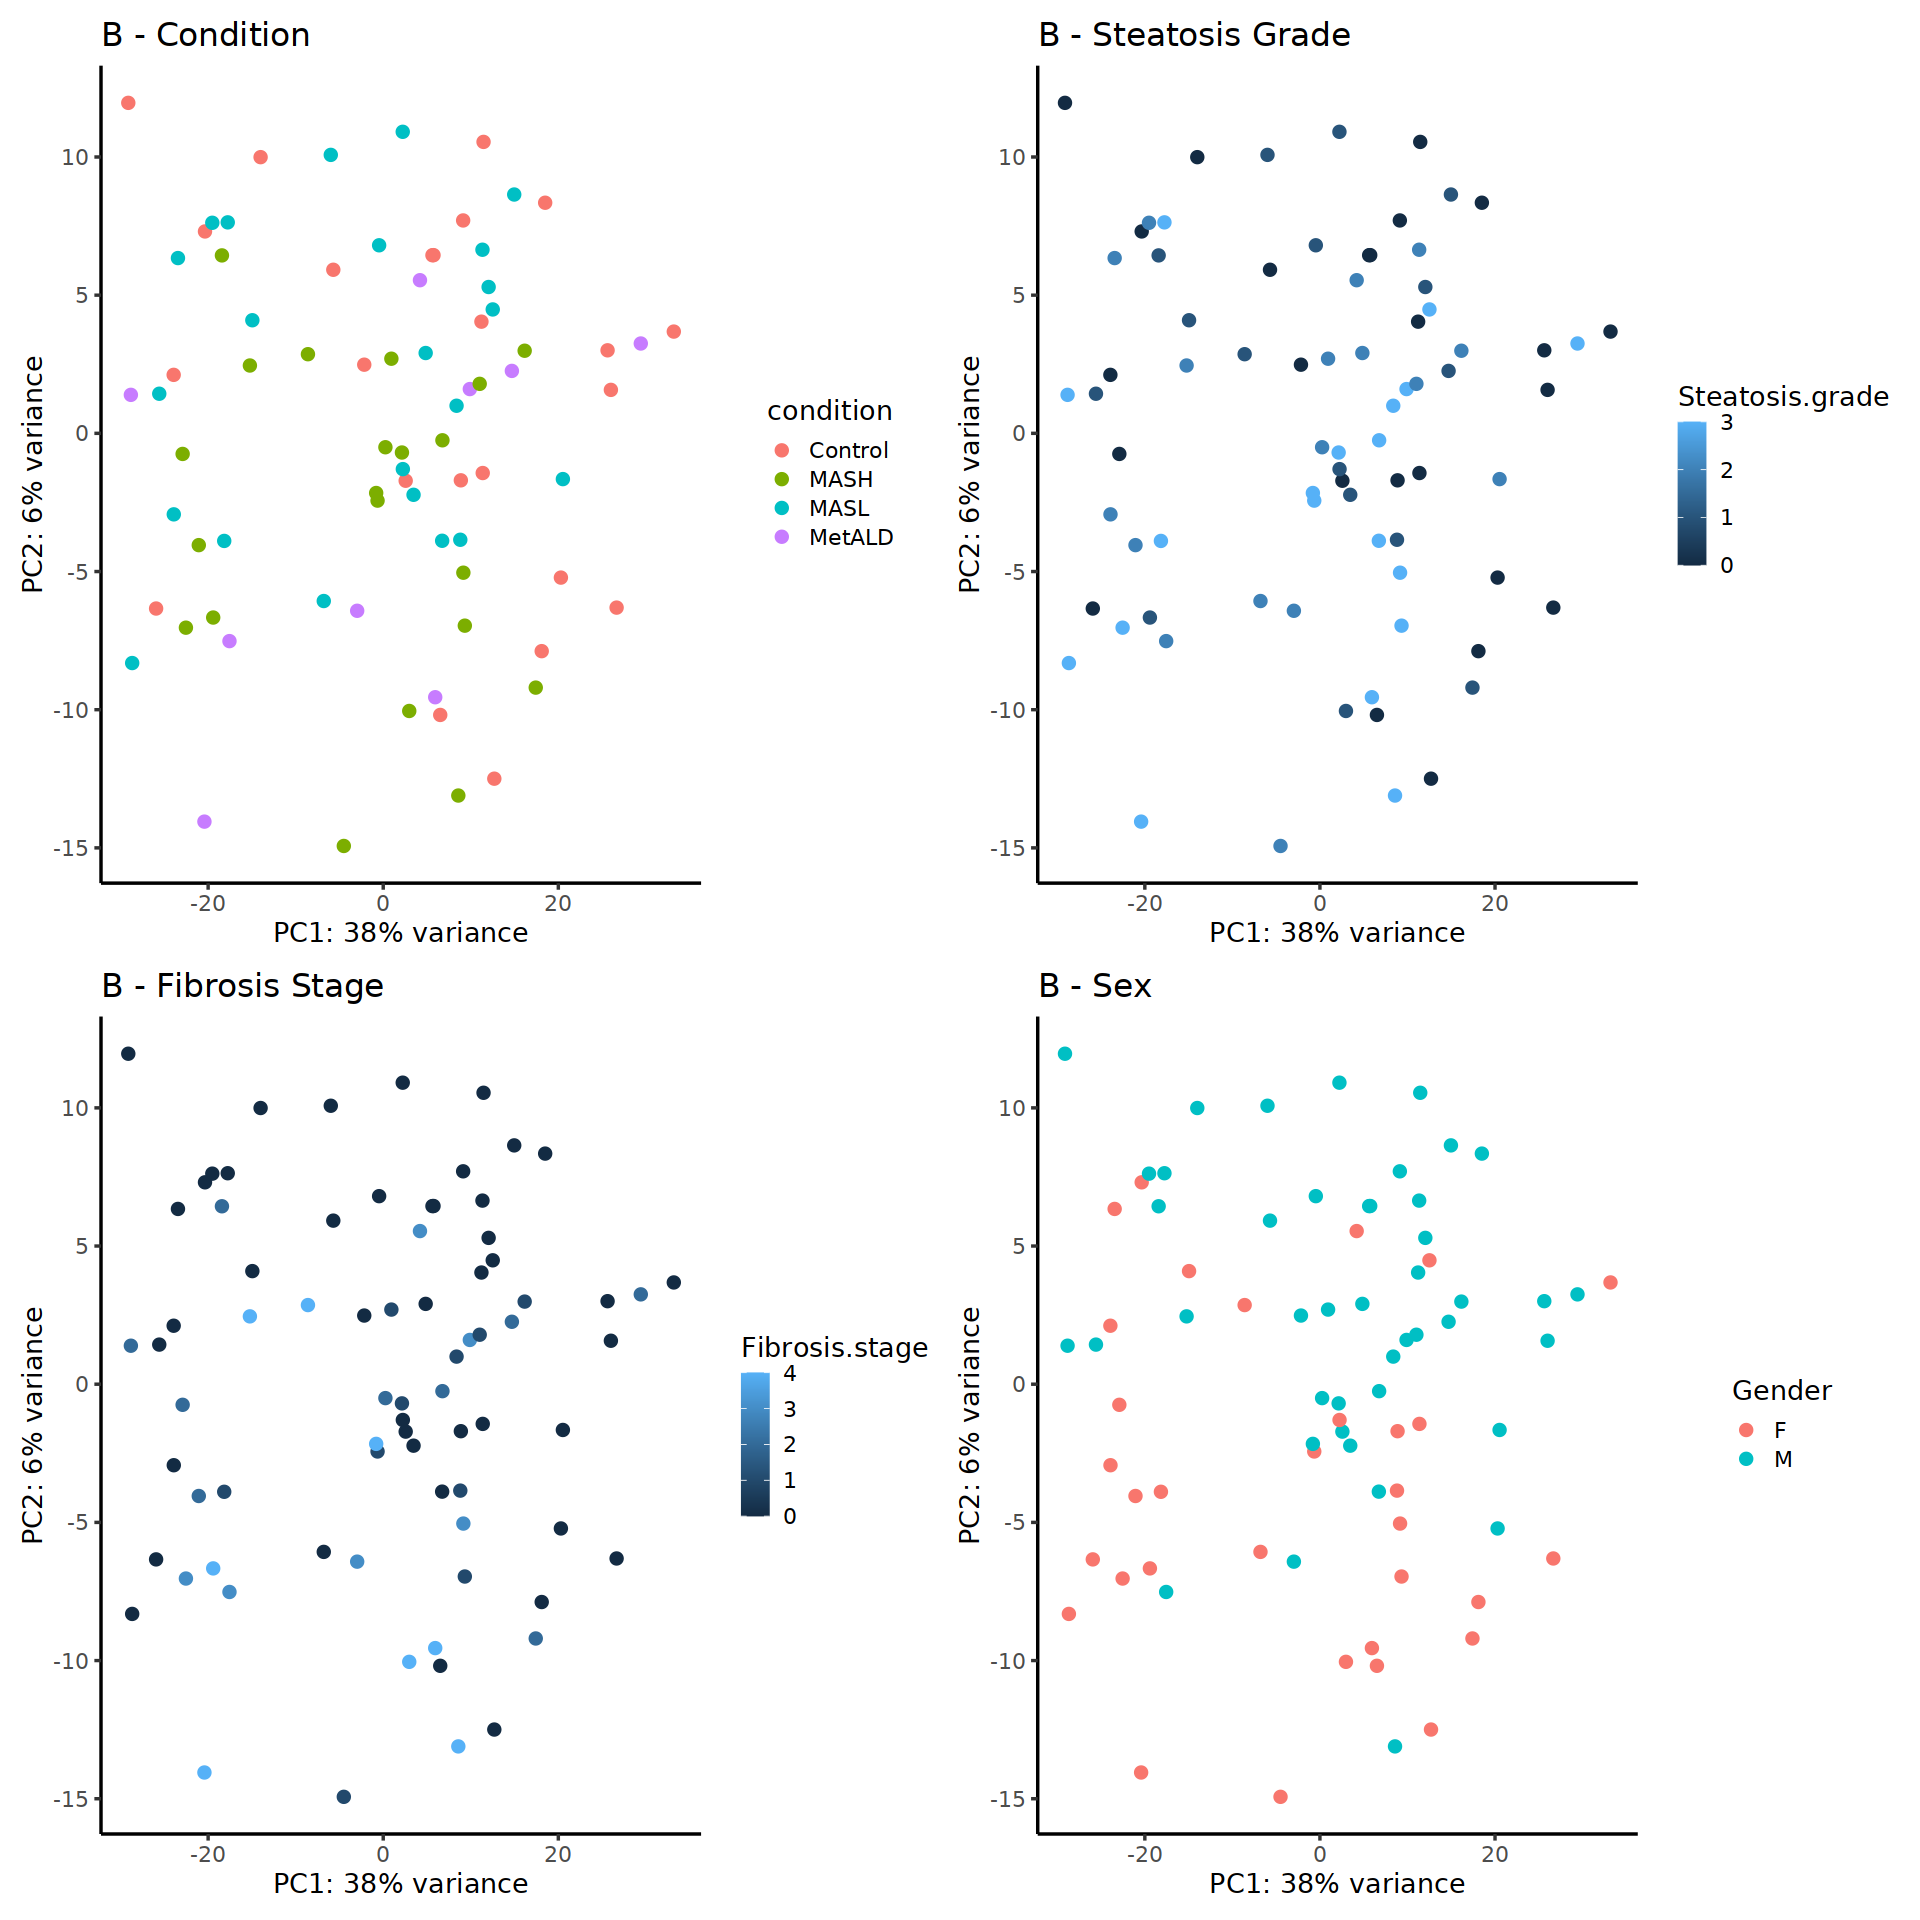

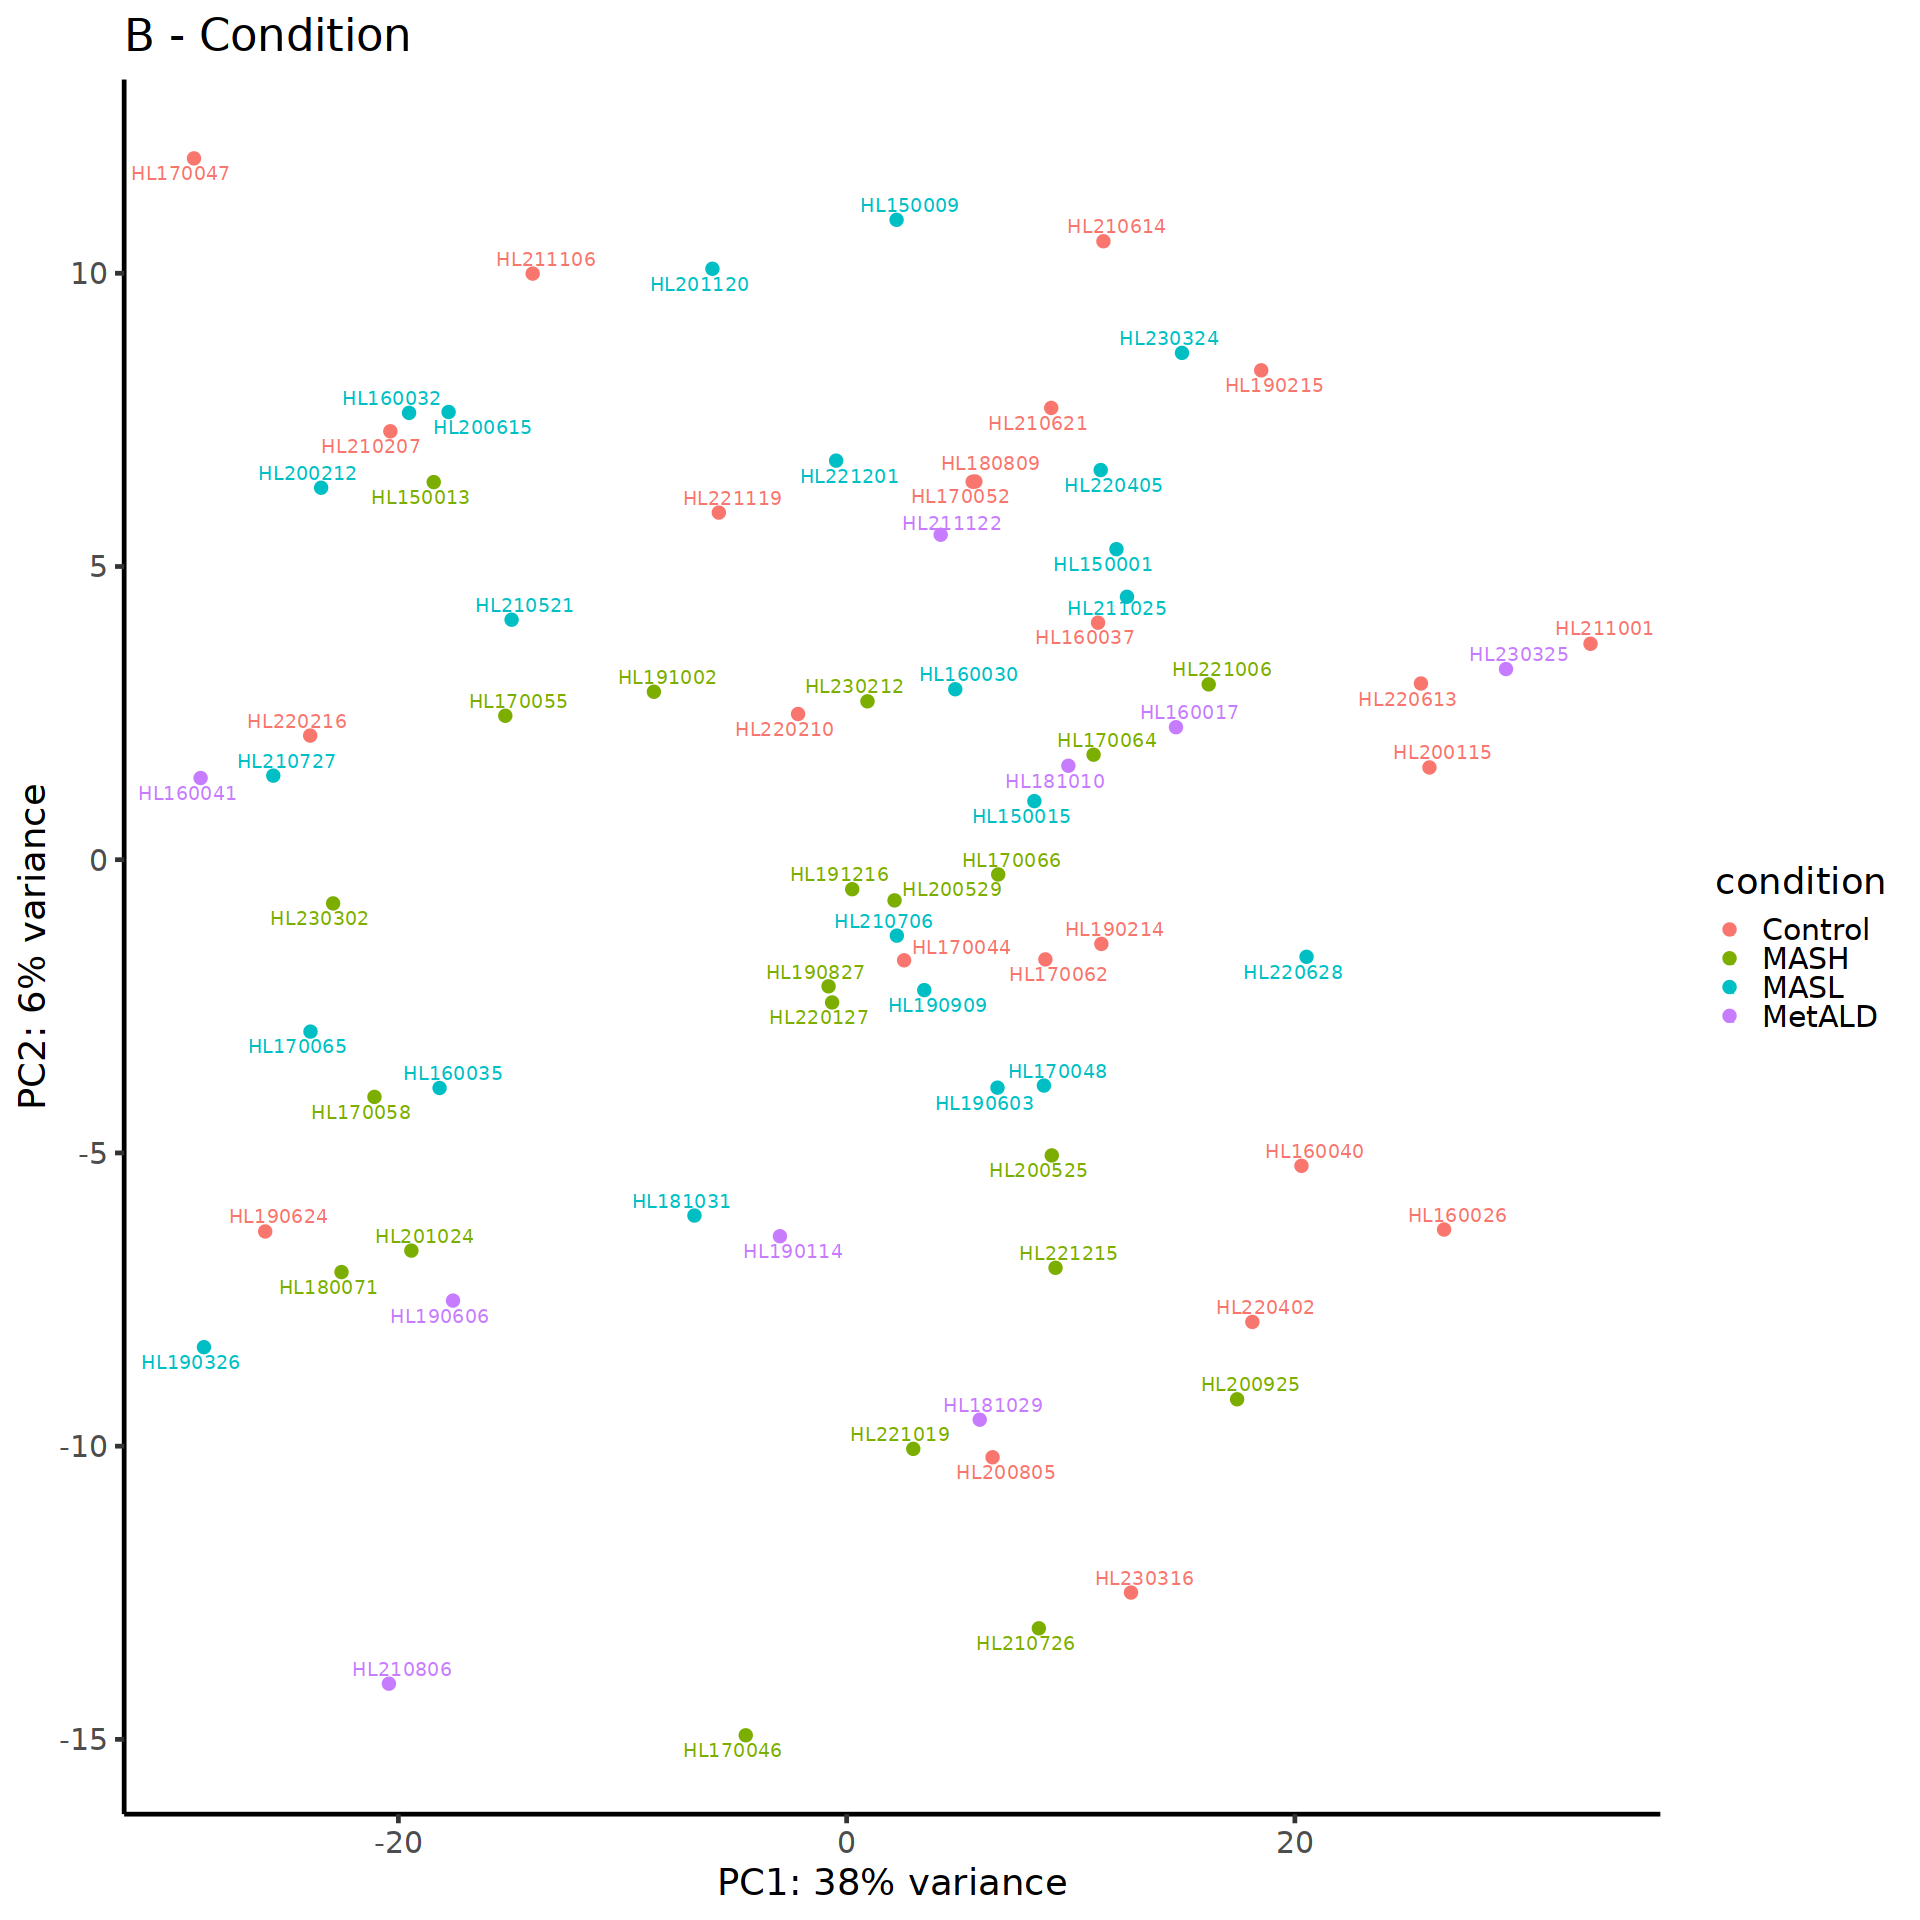

Warning message:
“ggrepel: 31 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Endothelial"
[1] 36601    86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



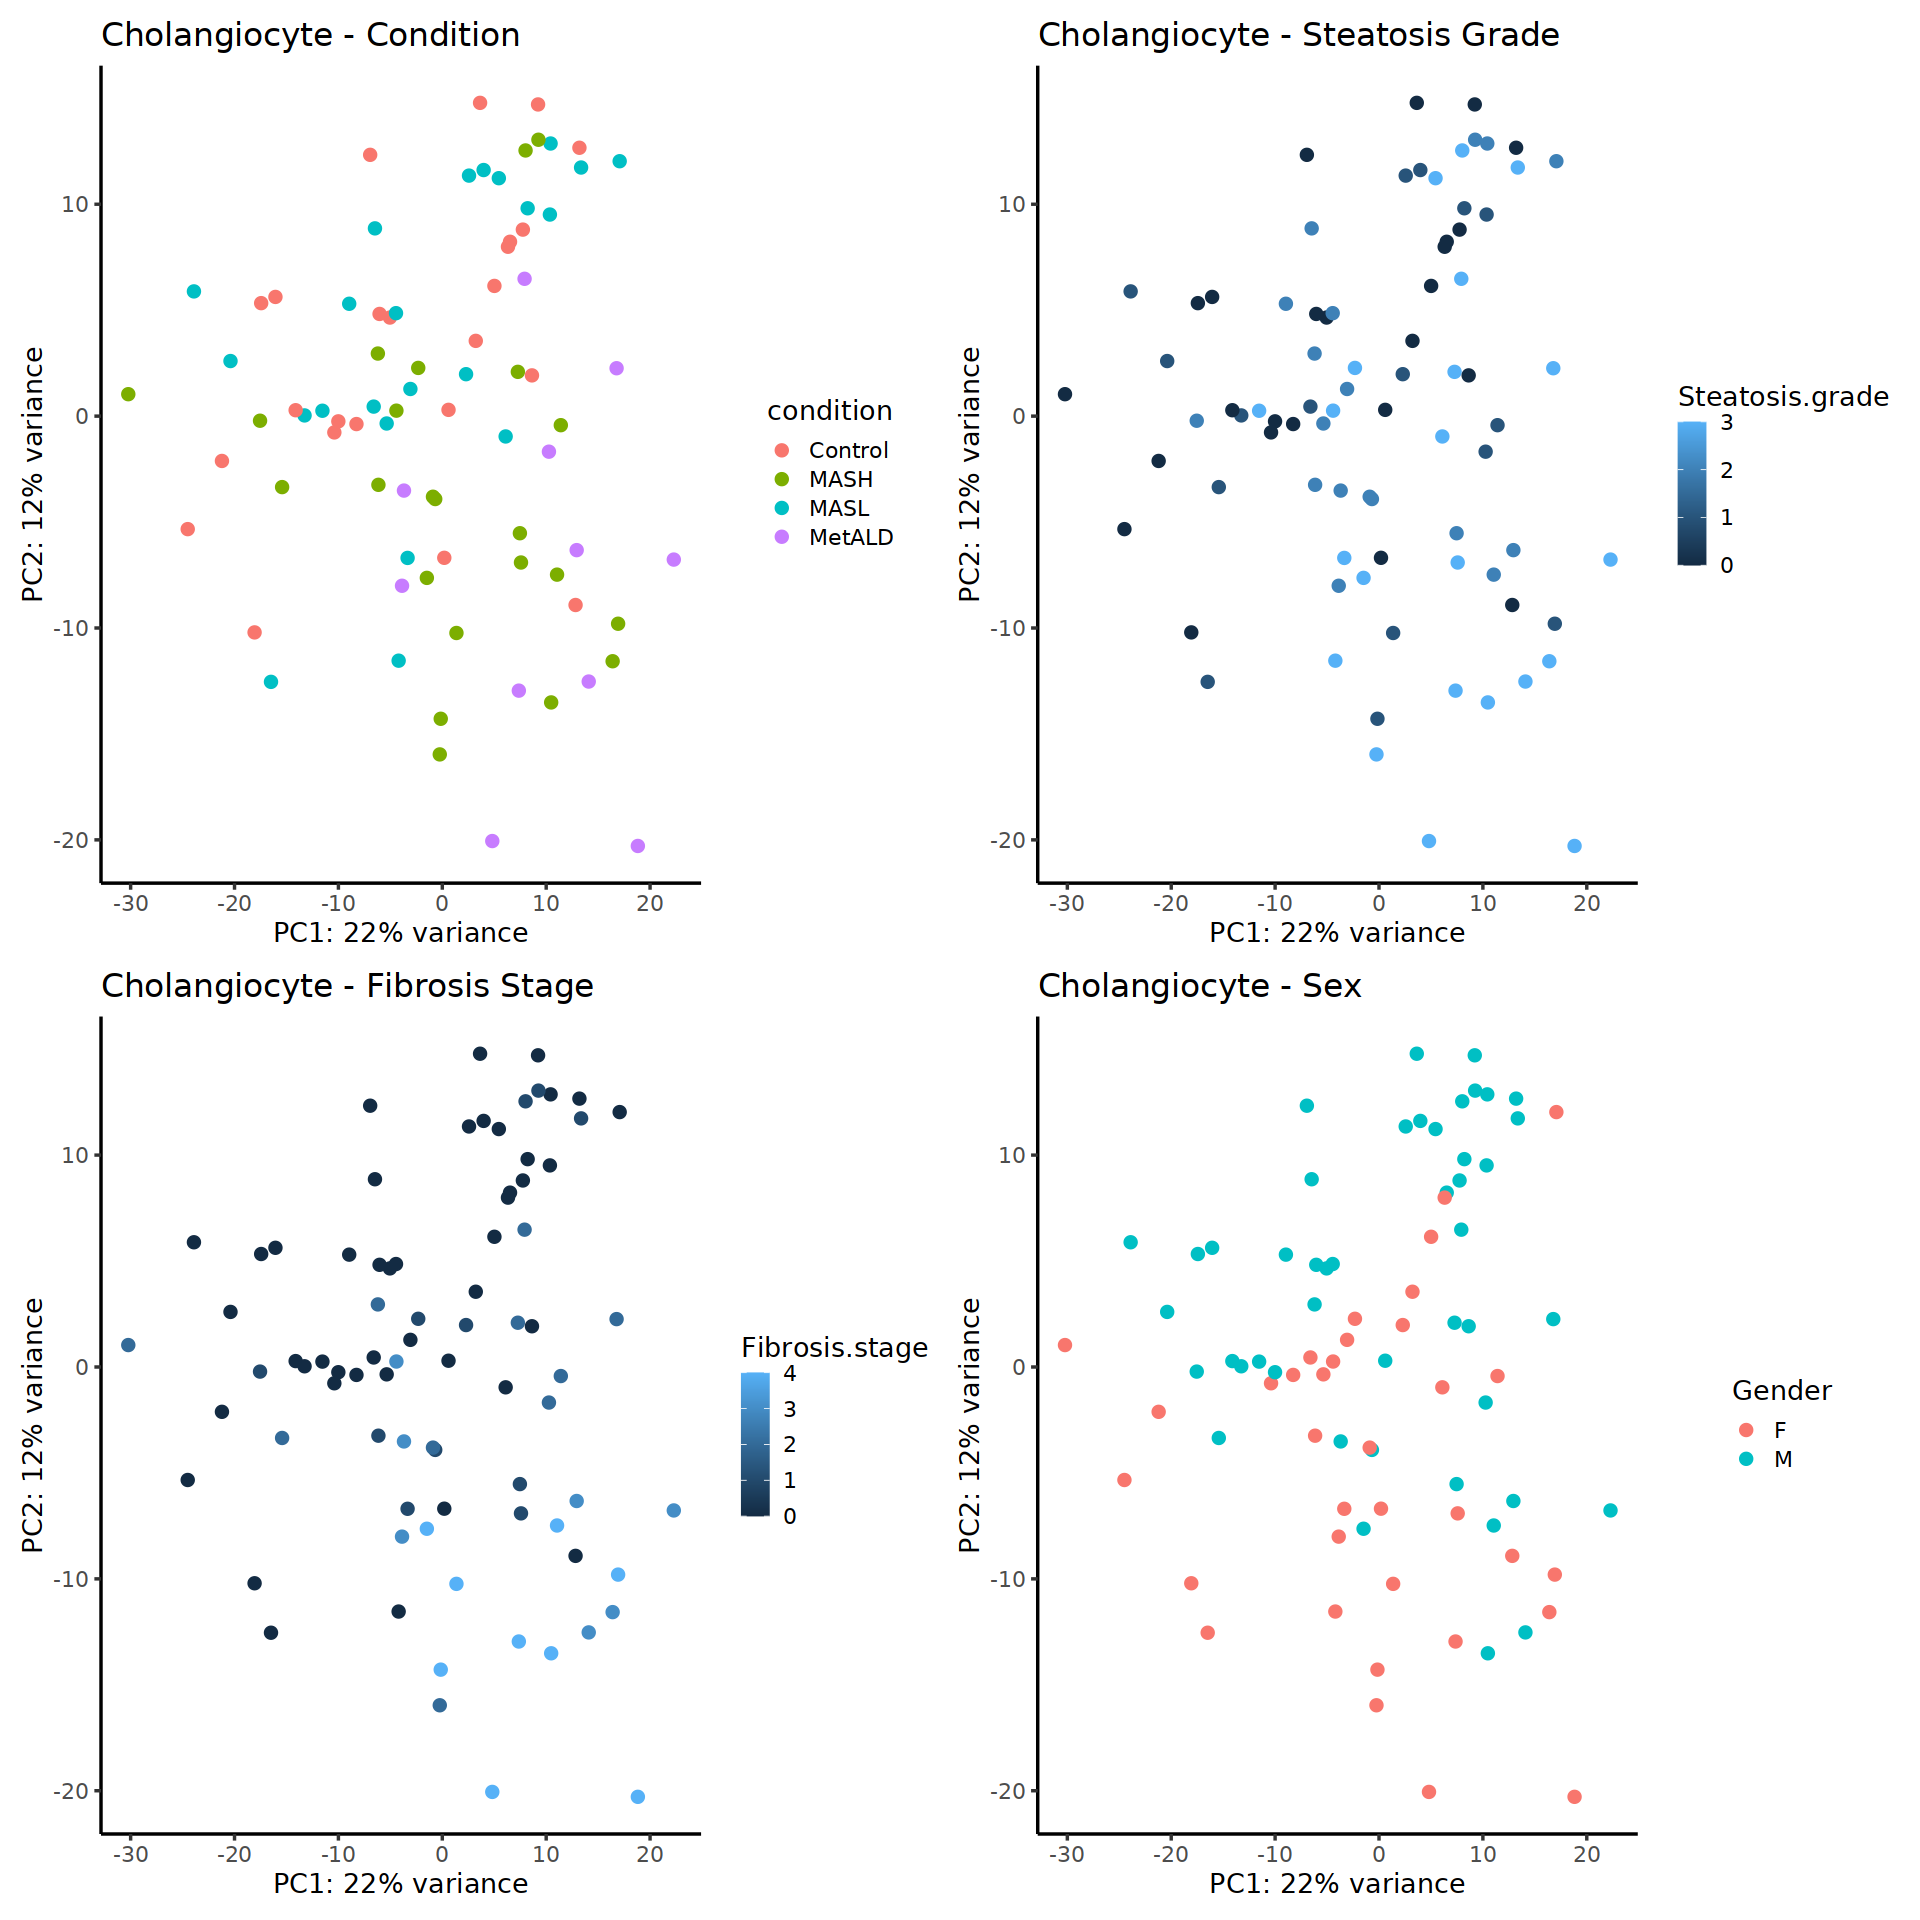

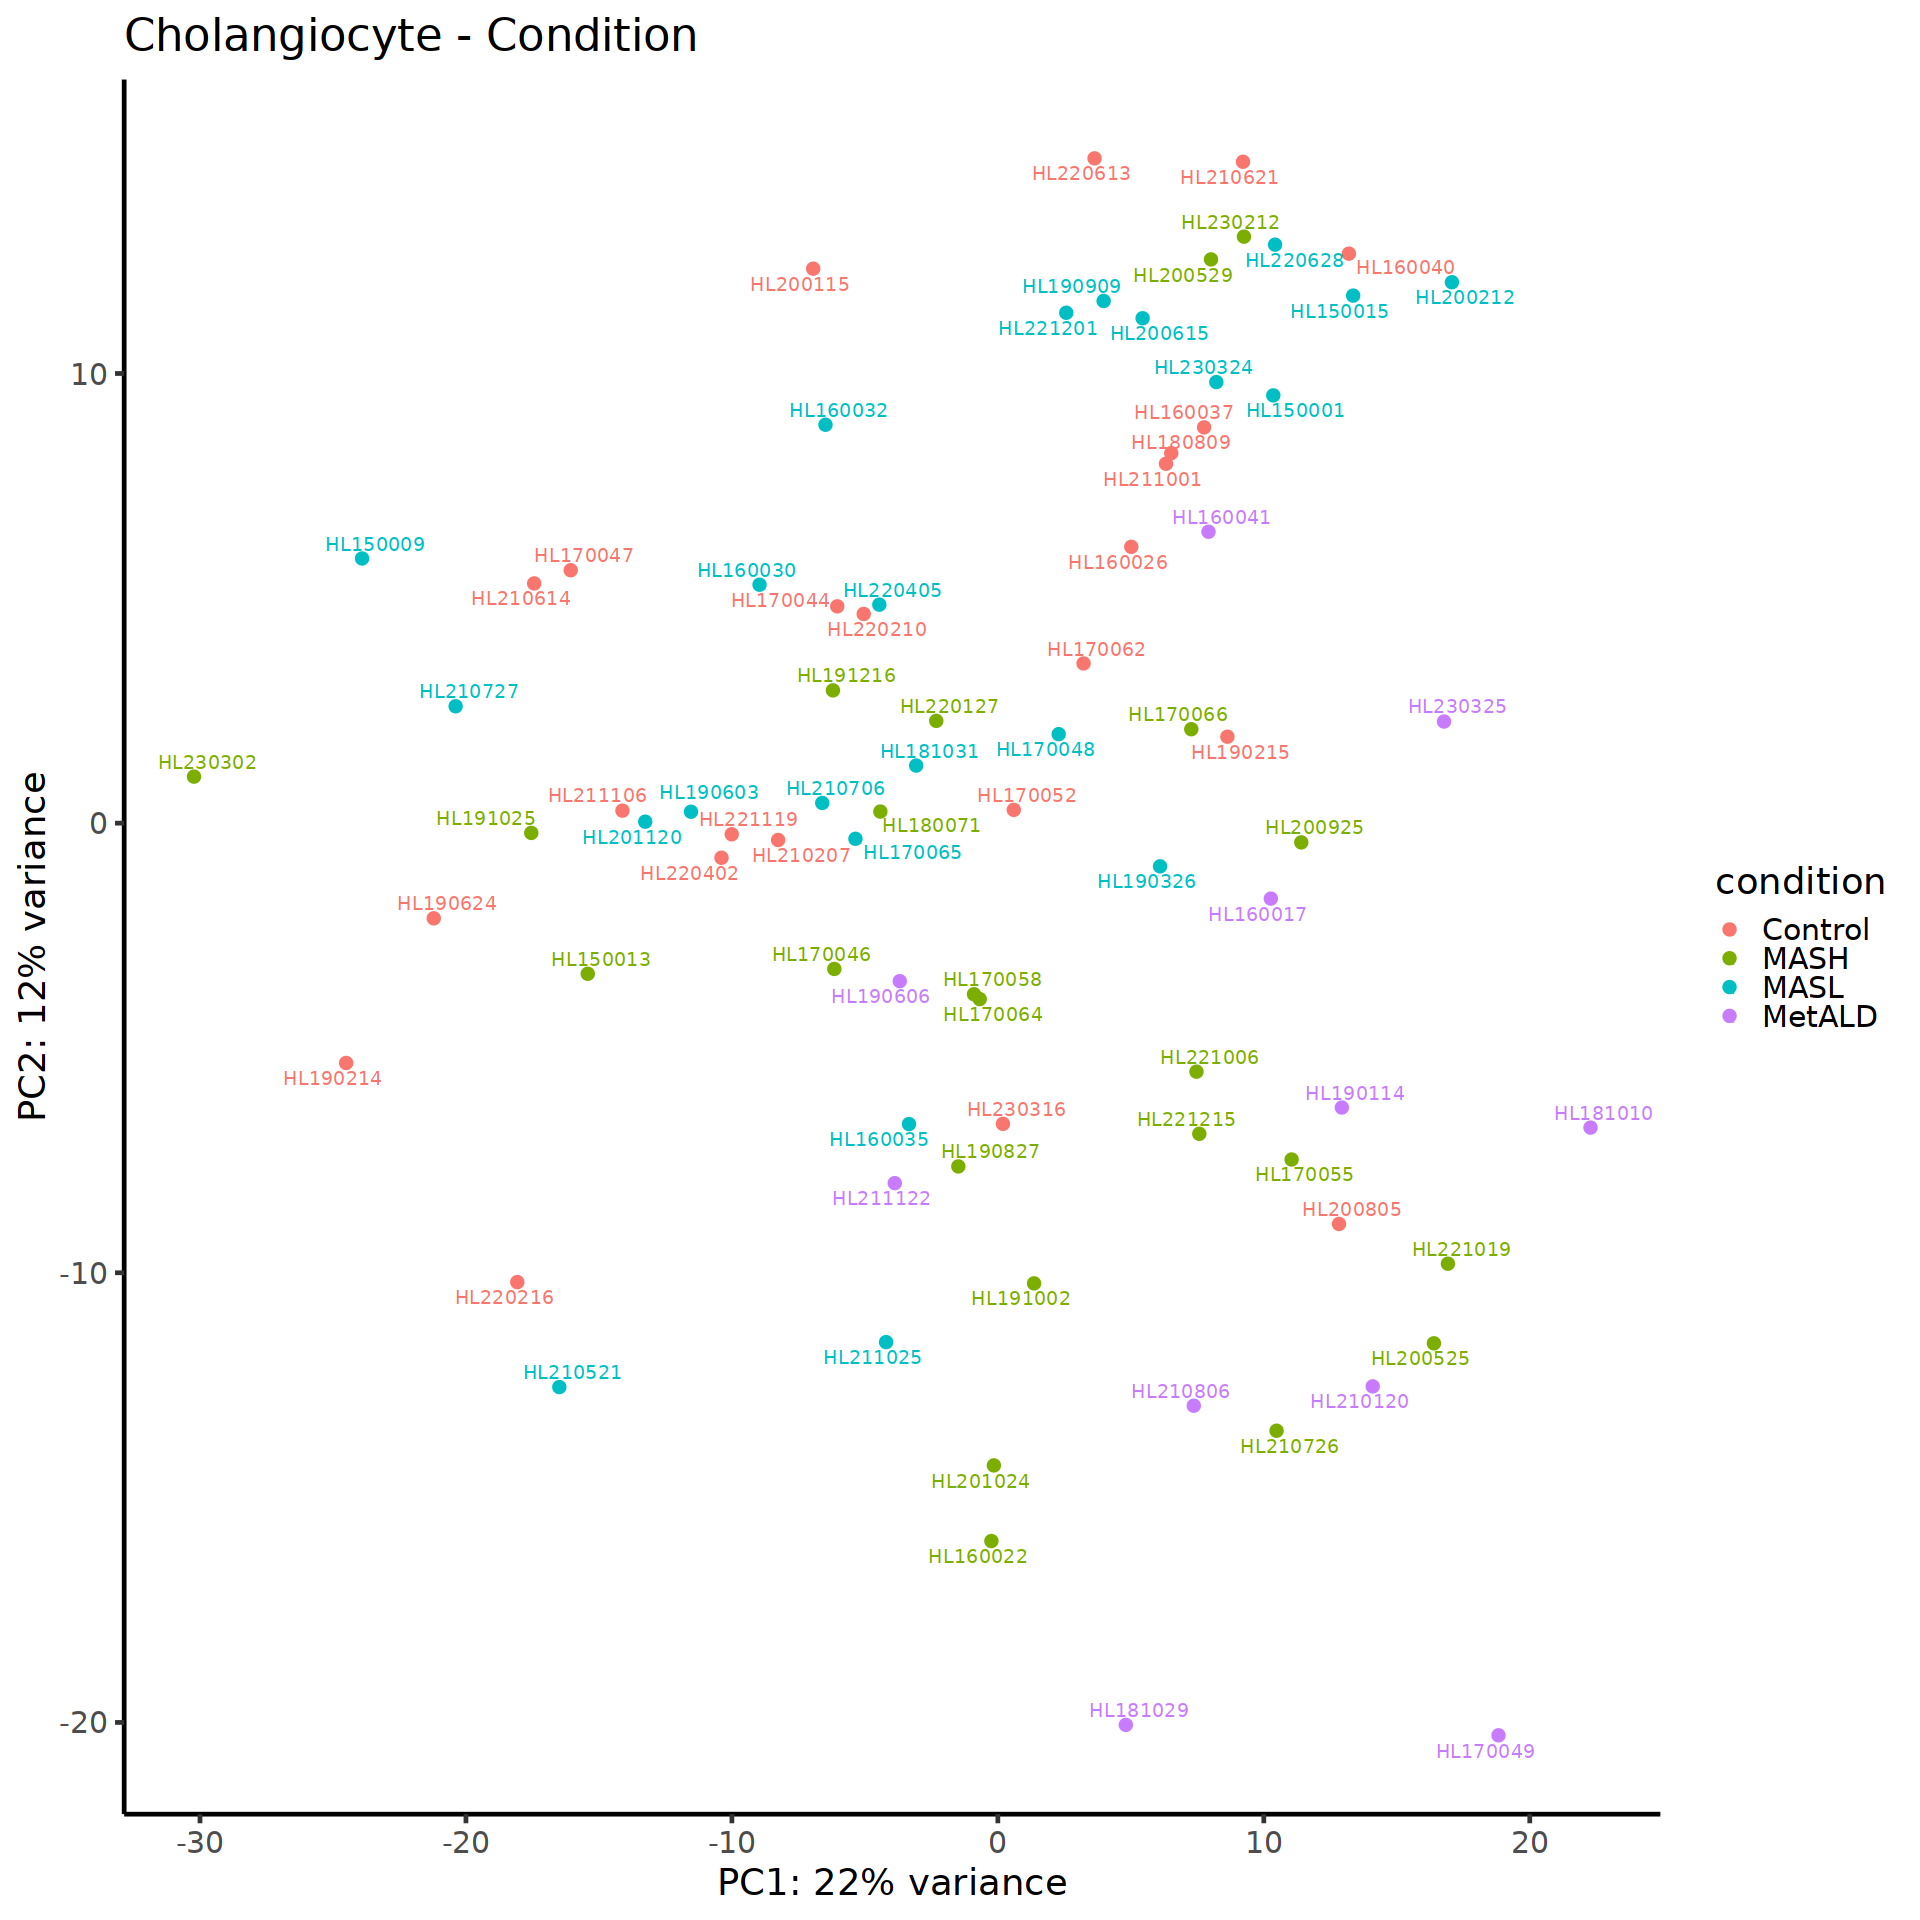

Warning message:
“ggrepel: 38 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Hepatocytes"
[1] 36601    86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



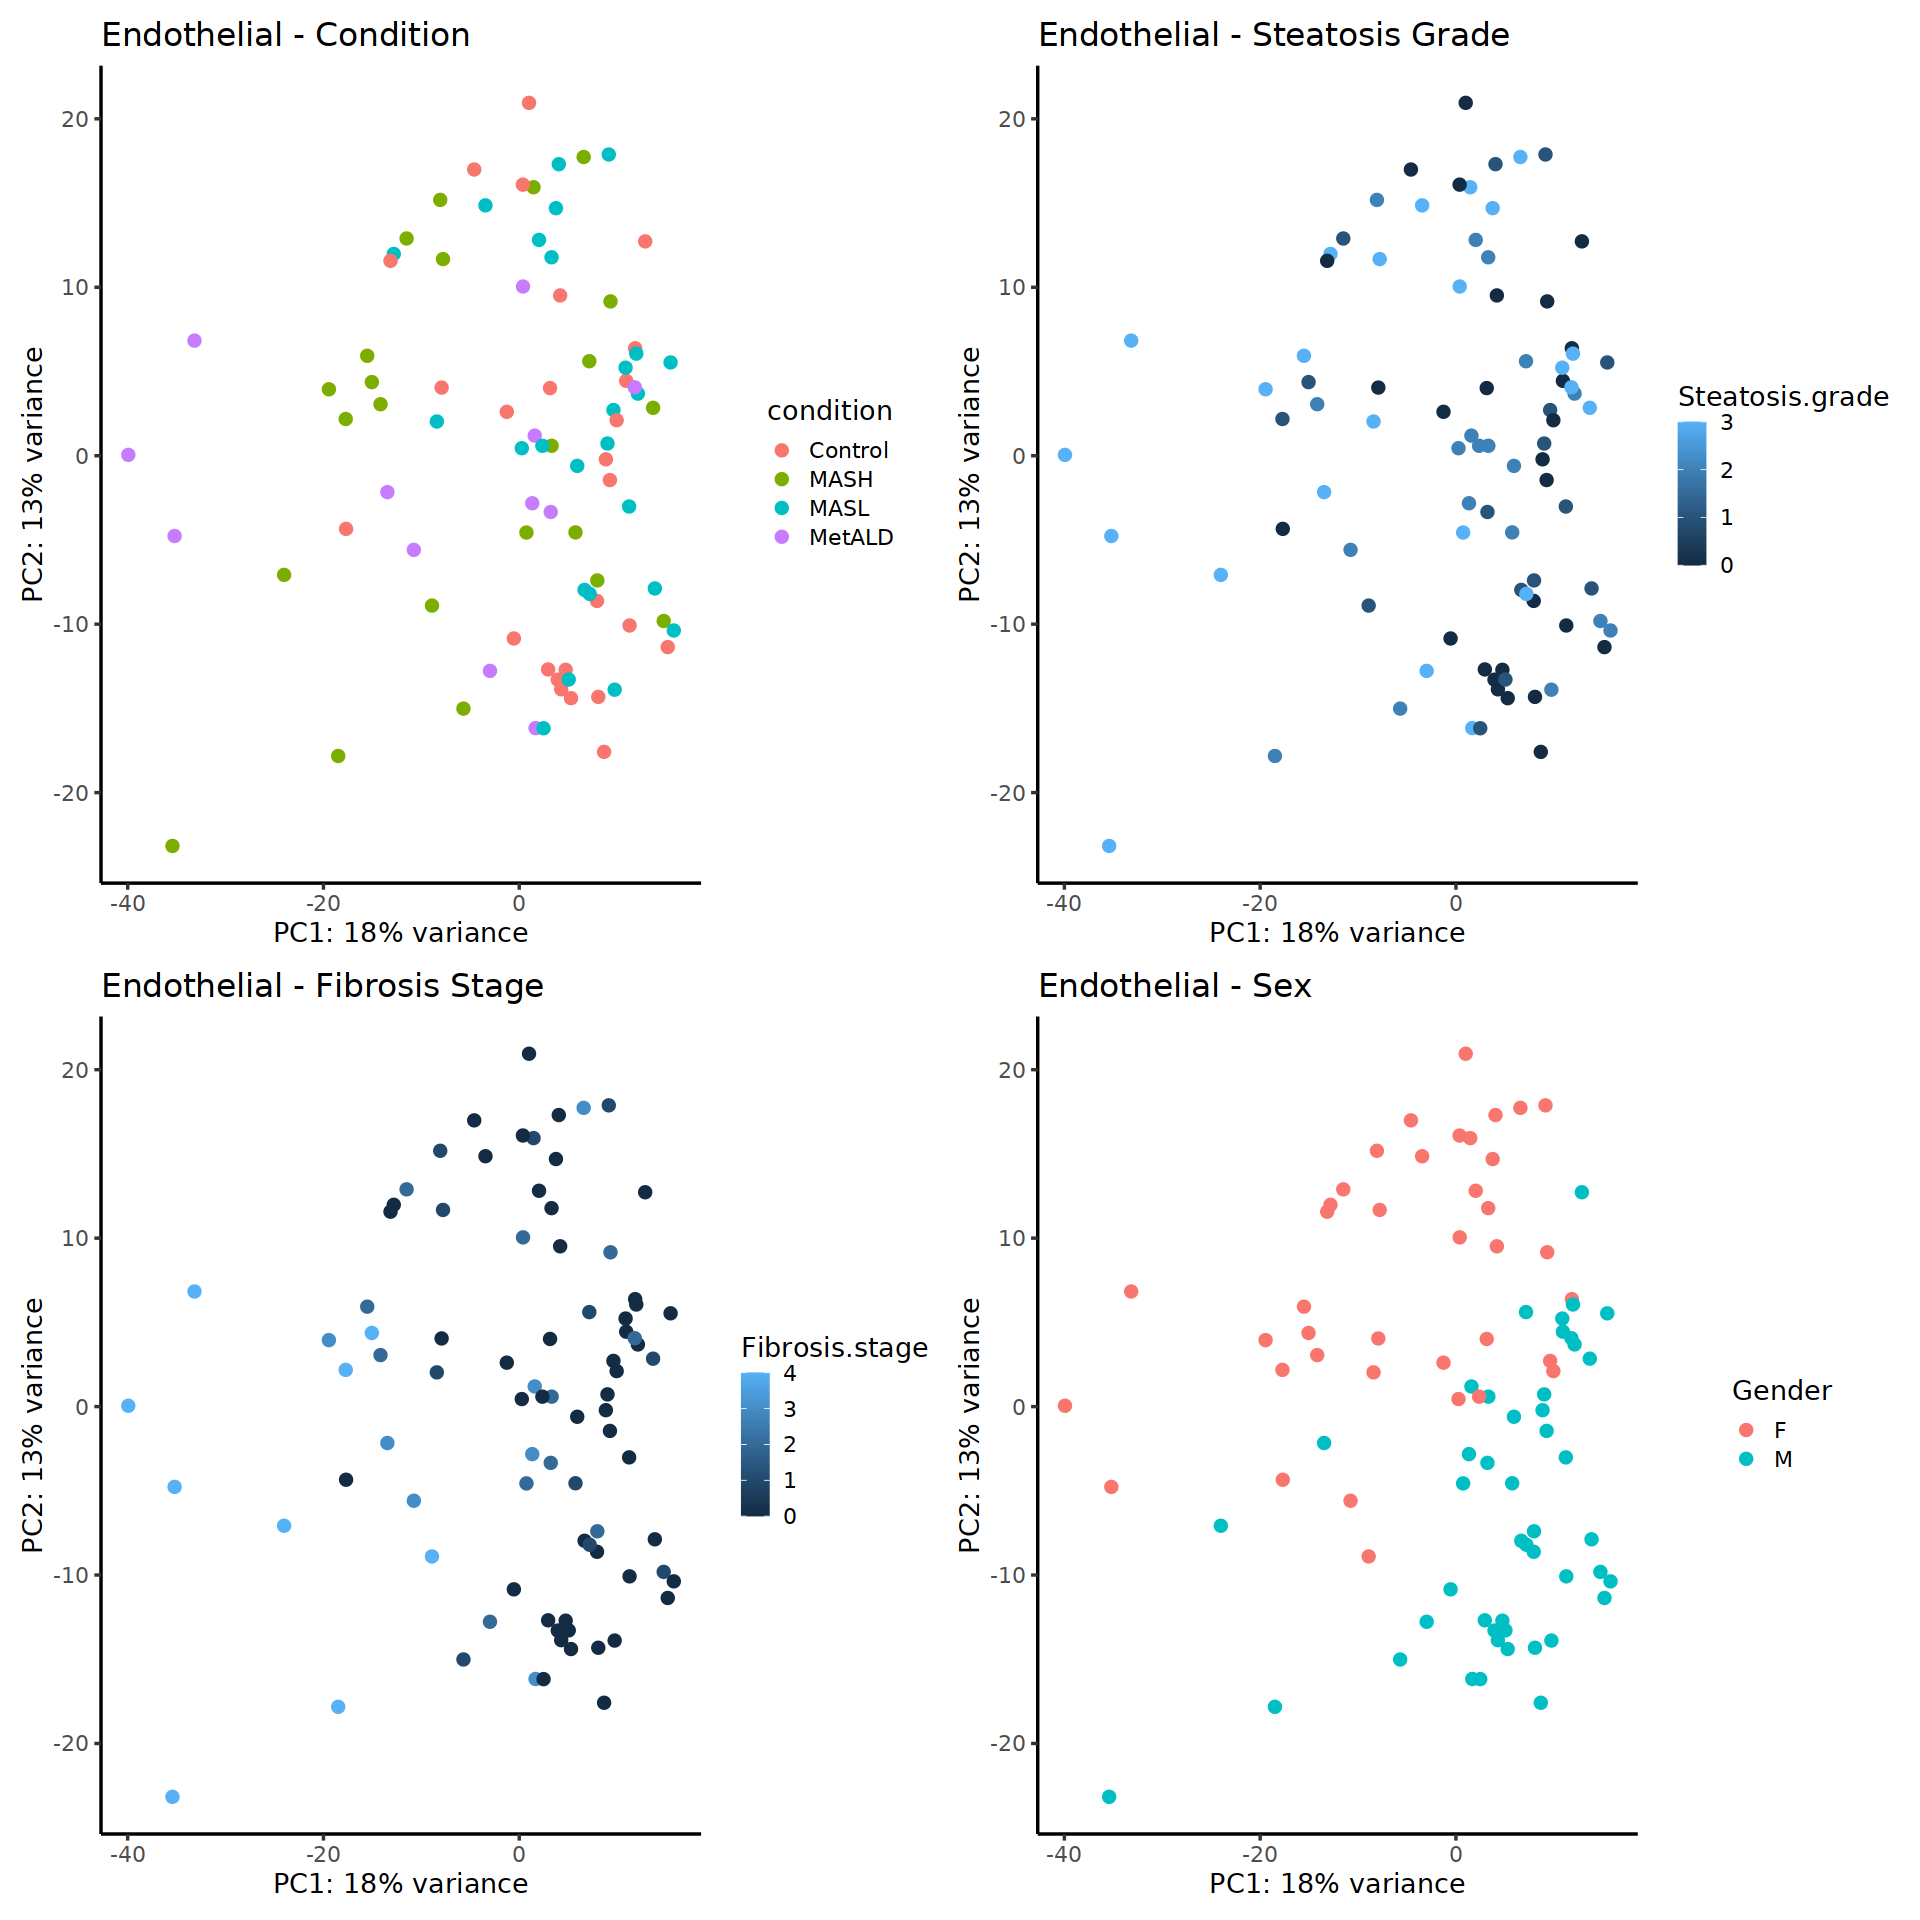

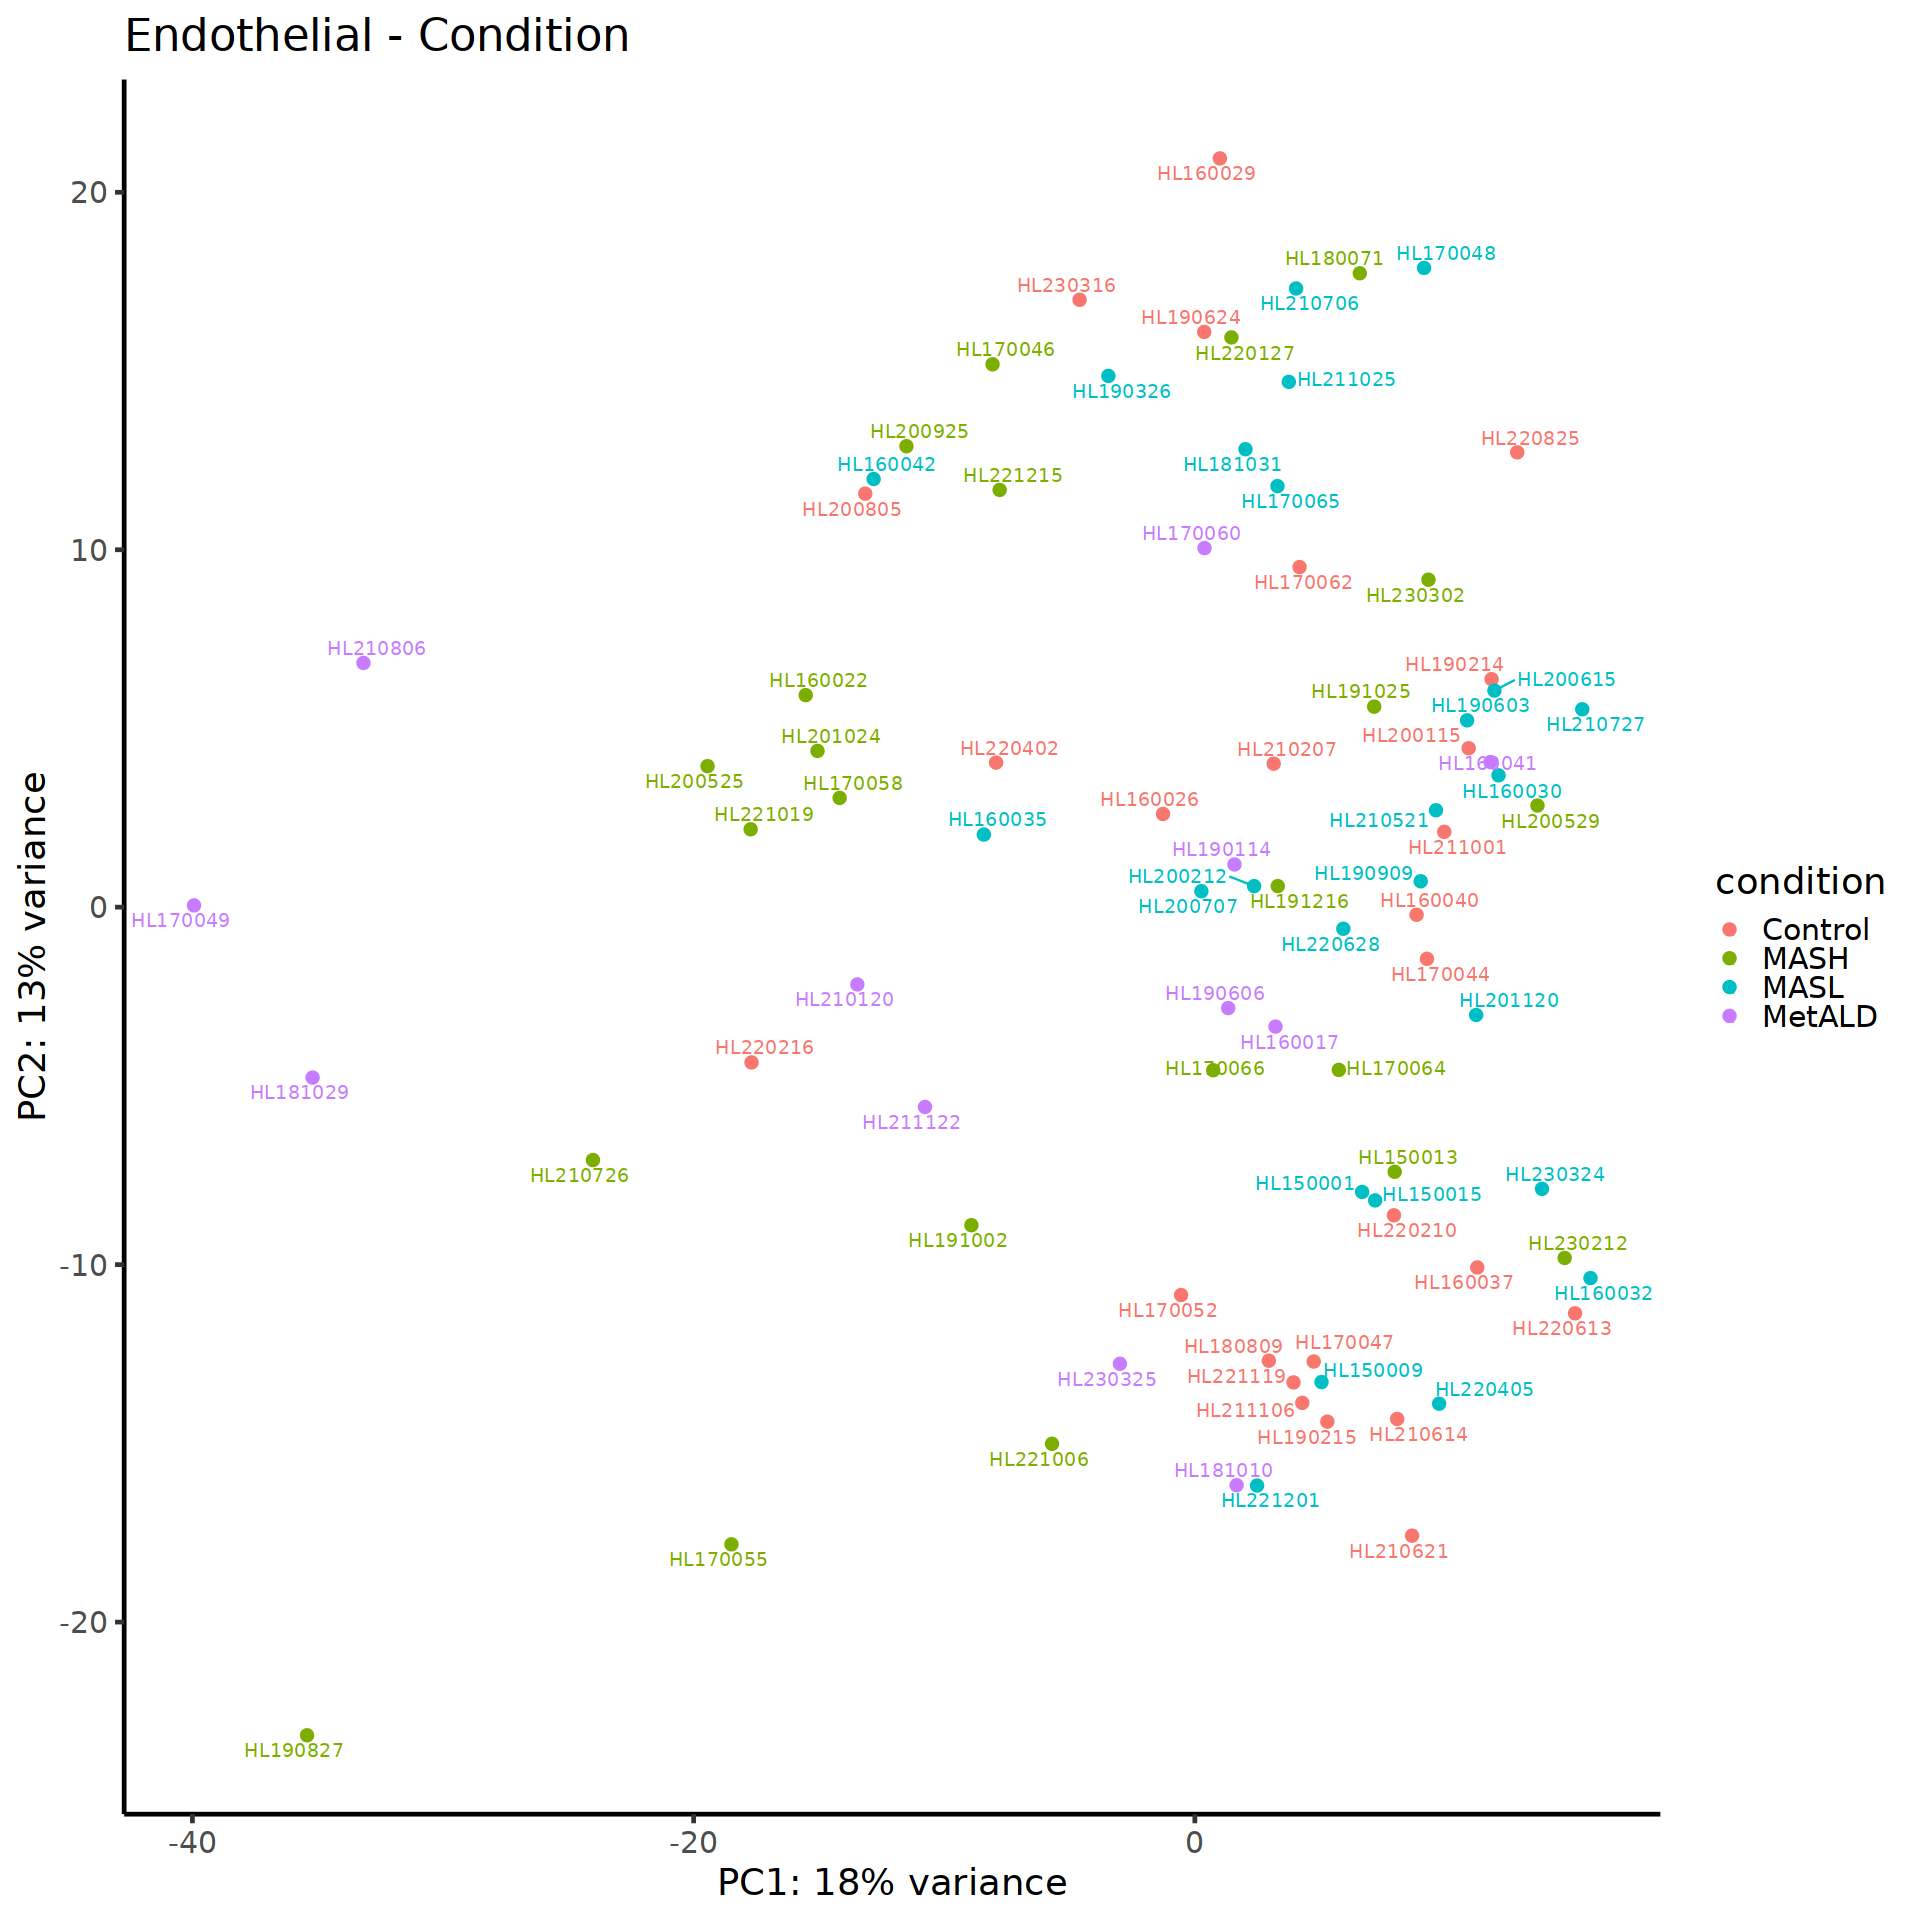

Warning message:
“ggrepel: 54 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: HSC"
[1] 36601    86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



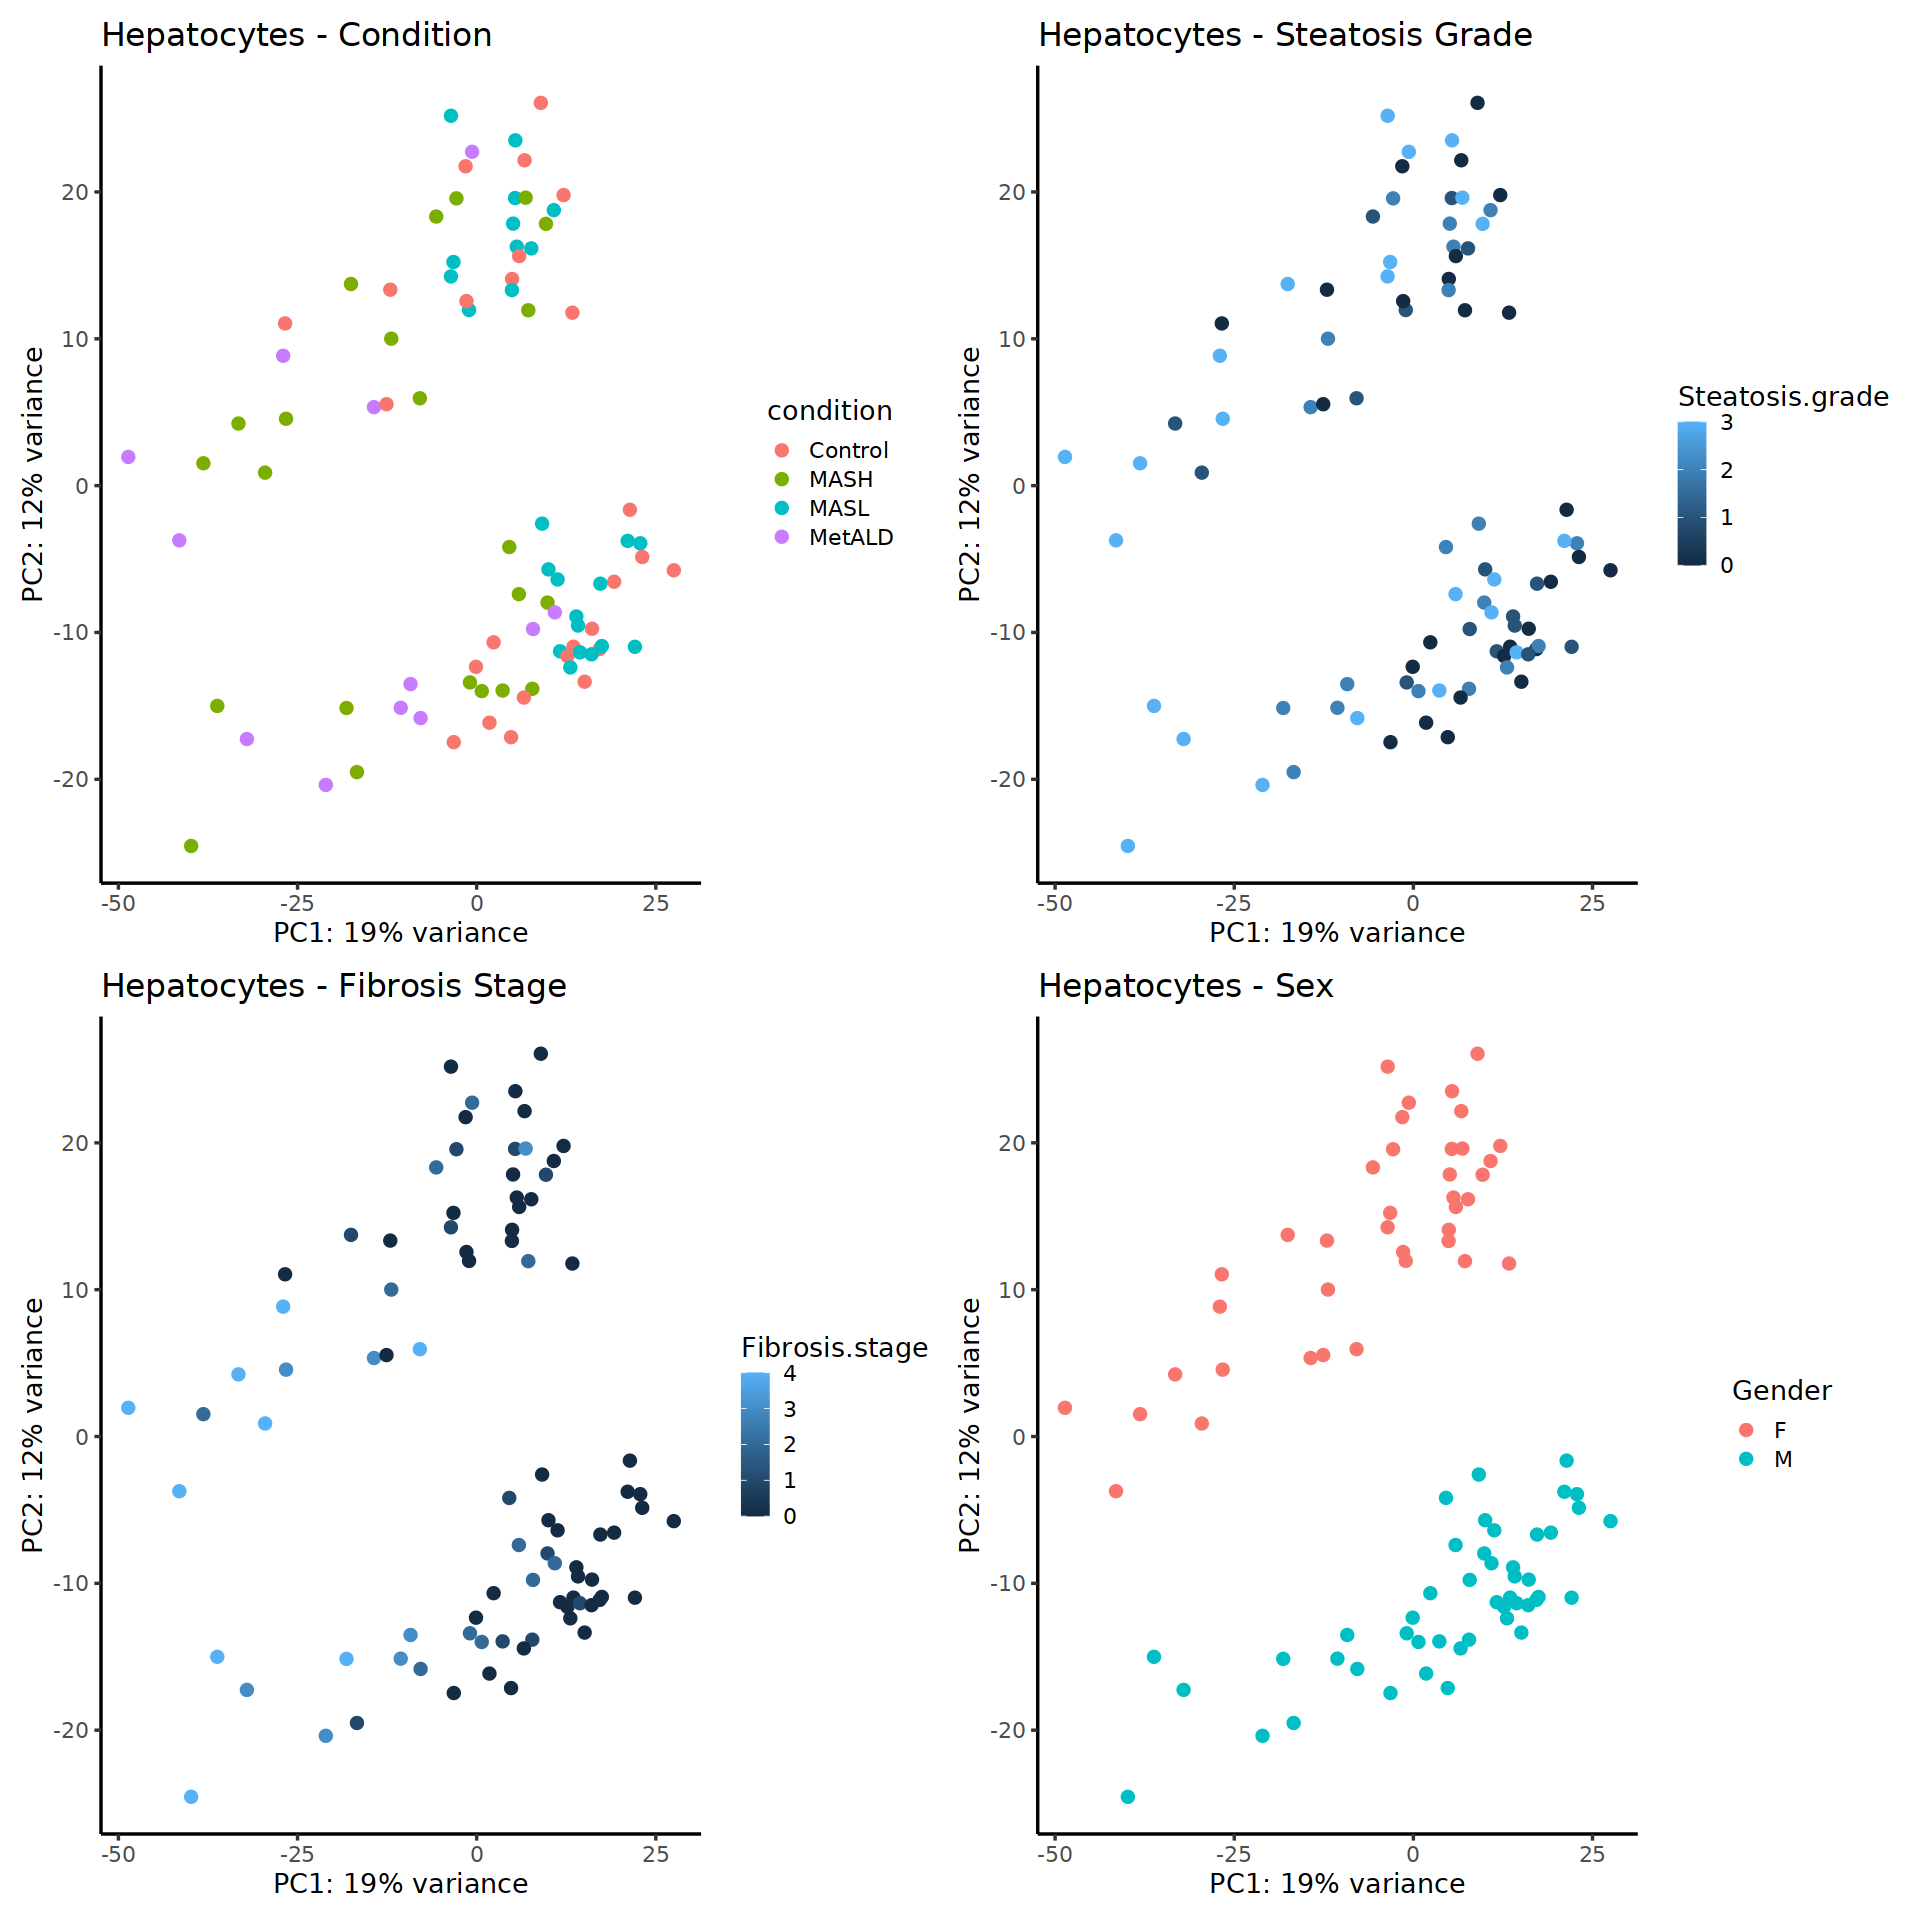

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


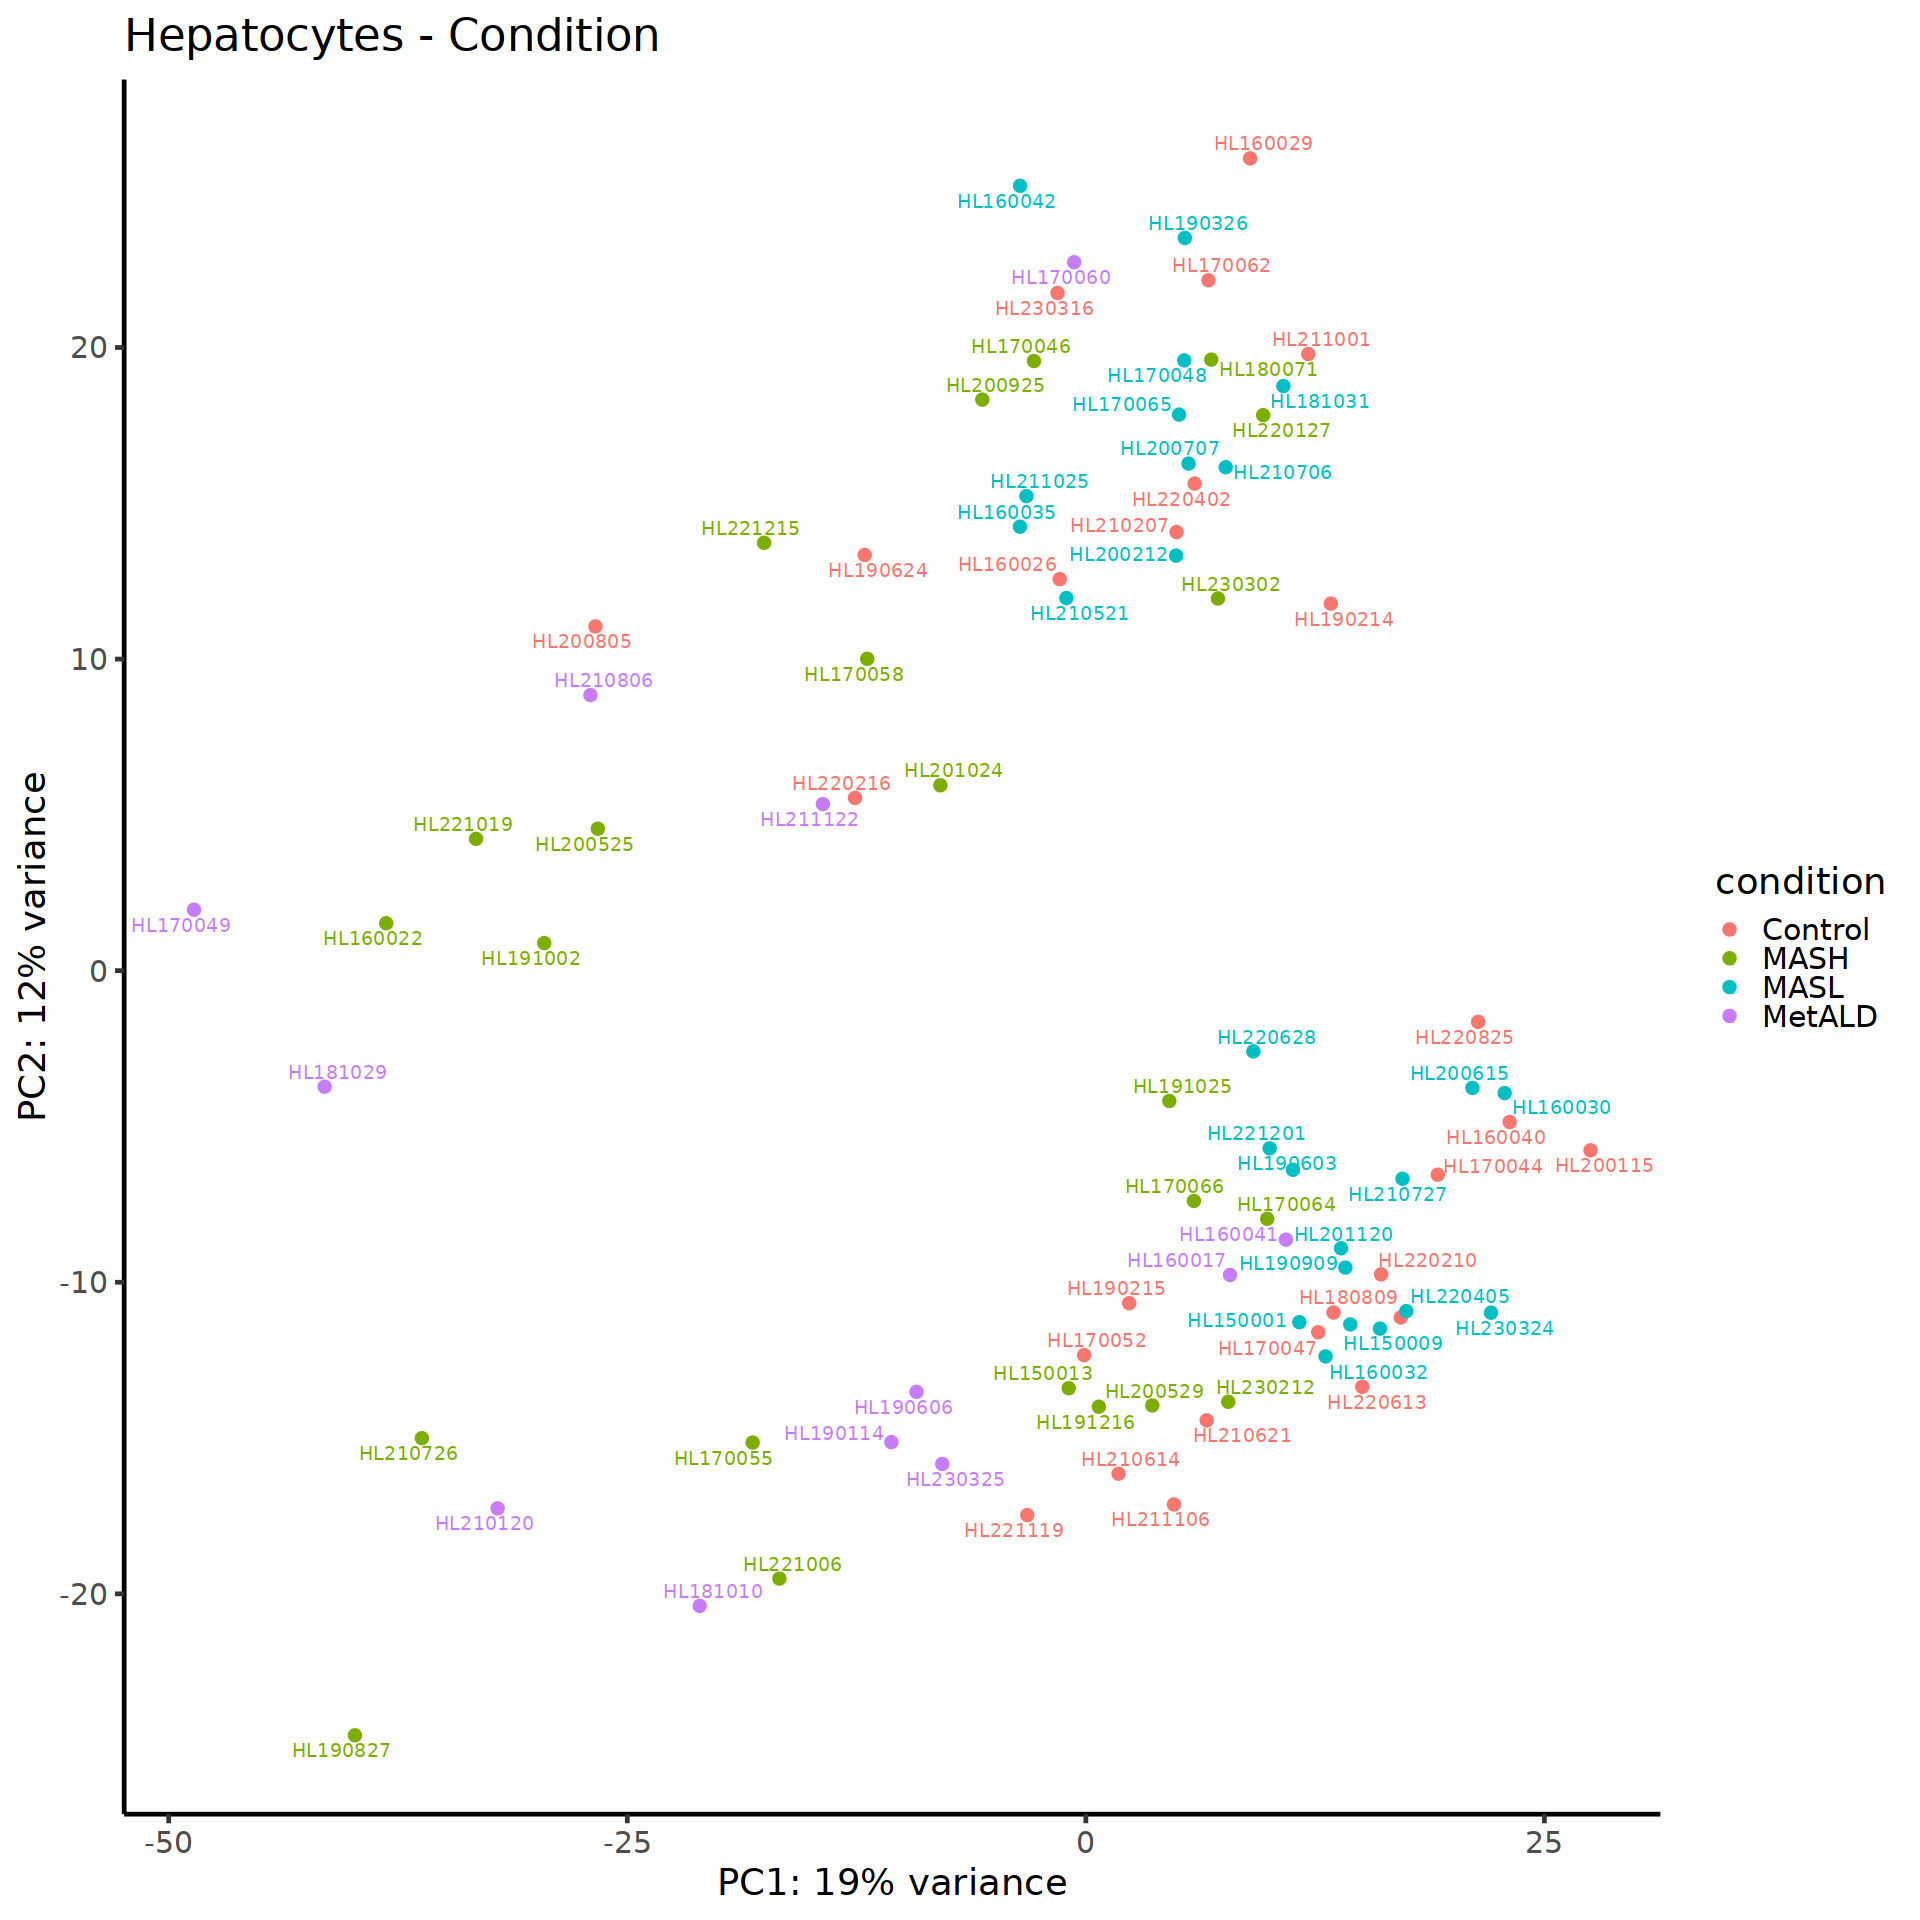

Warning message:
“ggrepel: 31 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Mast"
[1] 36601     6


Donors detectected with celltype: 6

subsetting metadata accordingly - Check that value is equal to above: 6

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



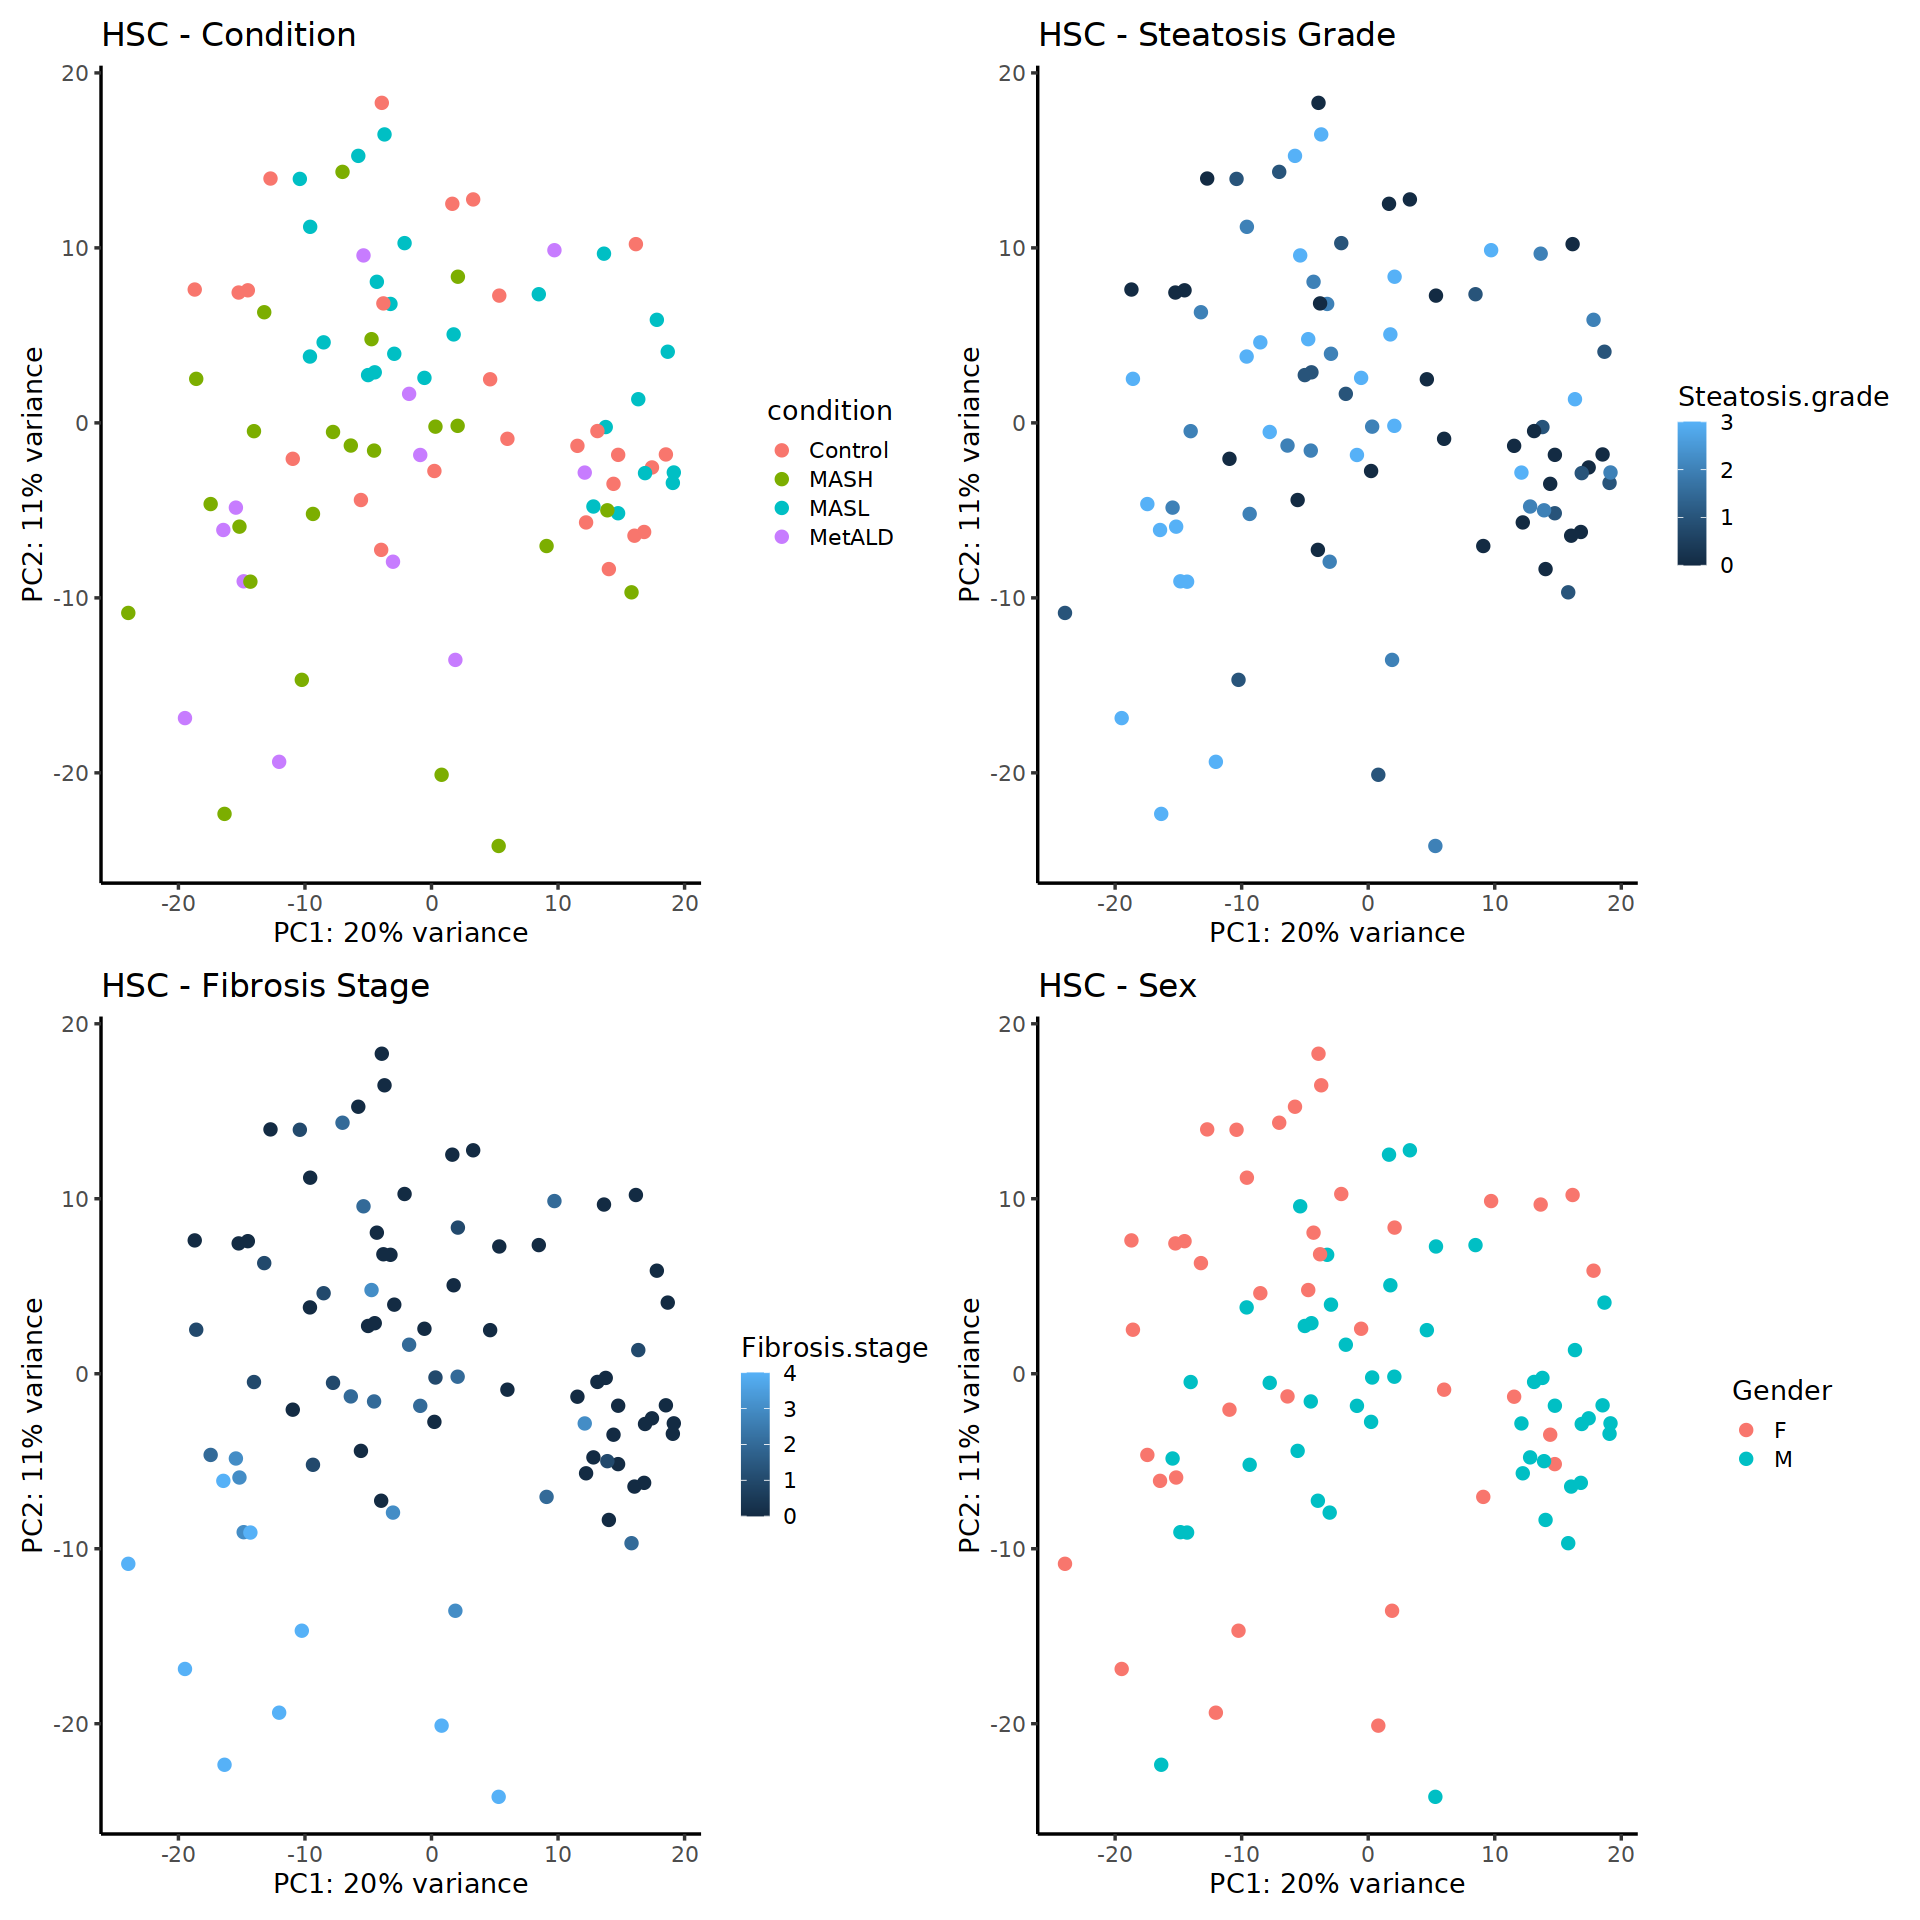

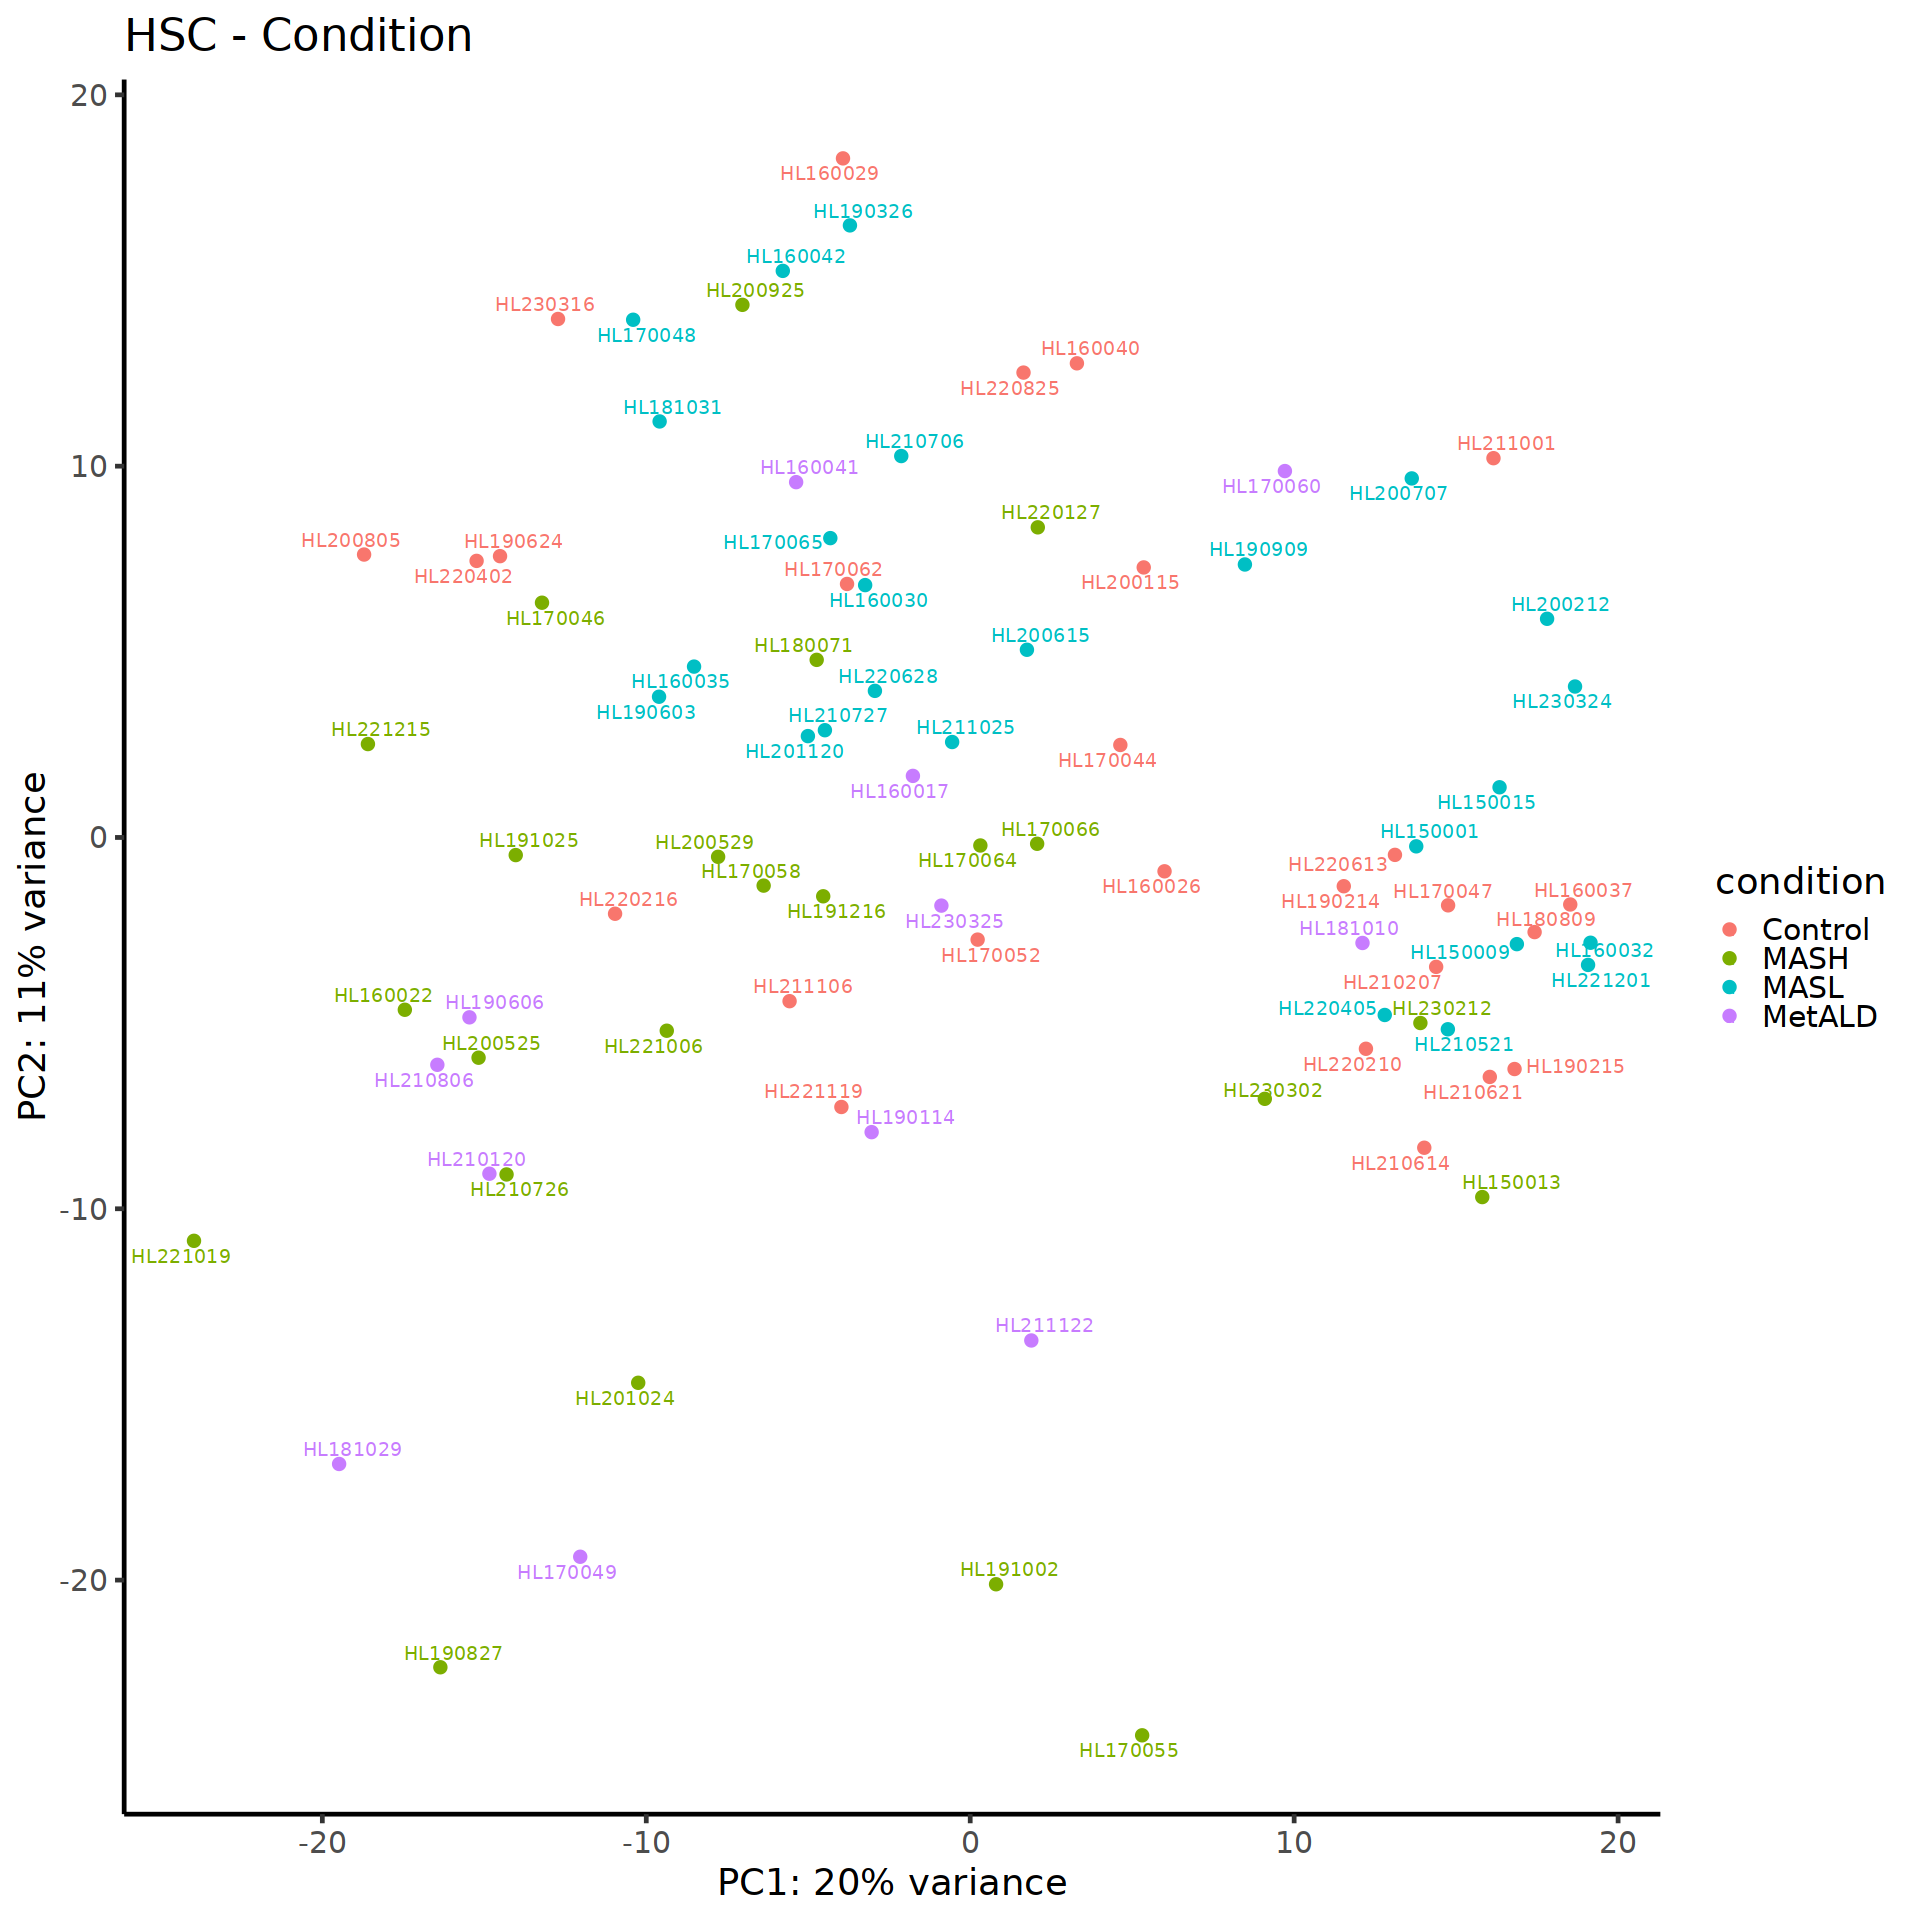

[1] "Analyzing: Myeloid"
[1] 36601    86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



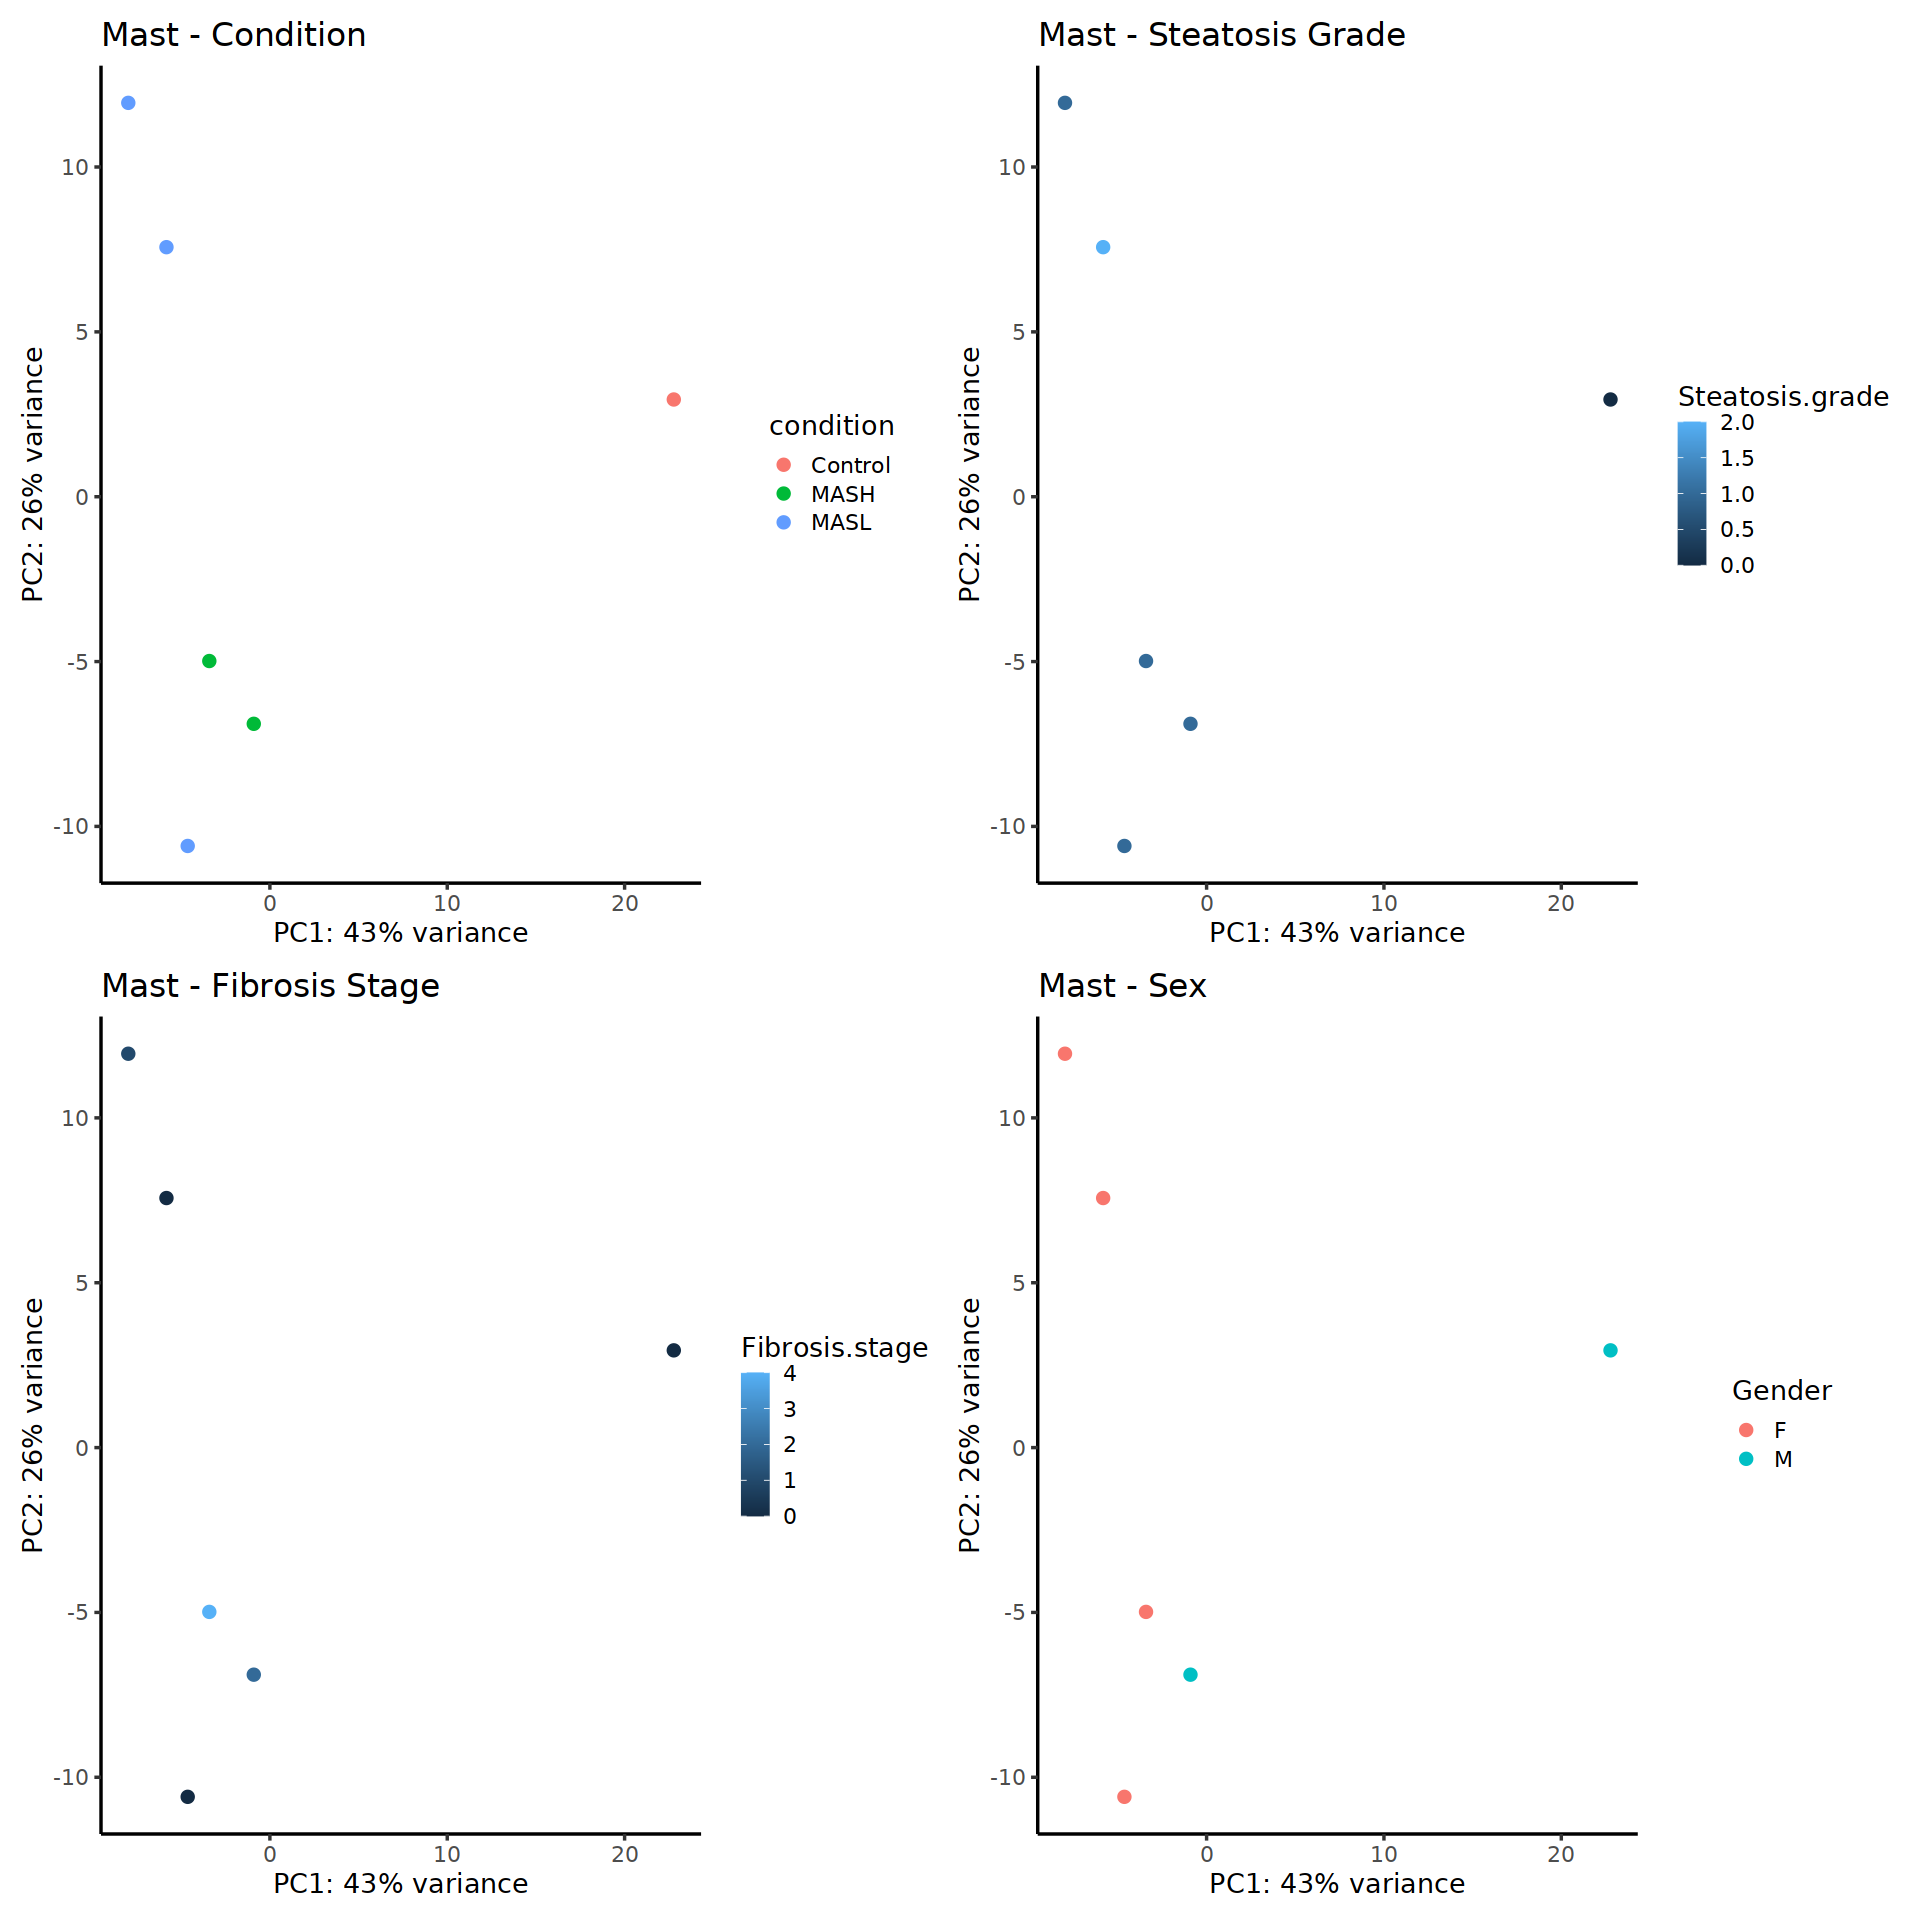

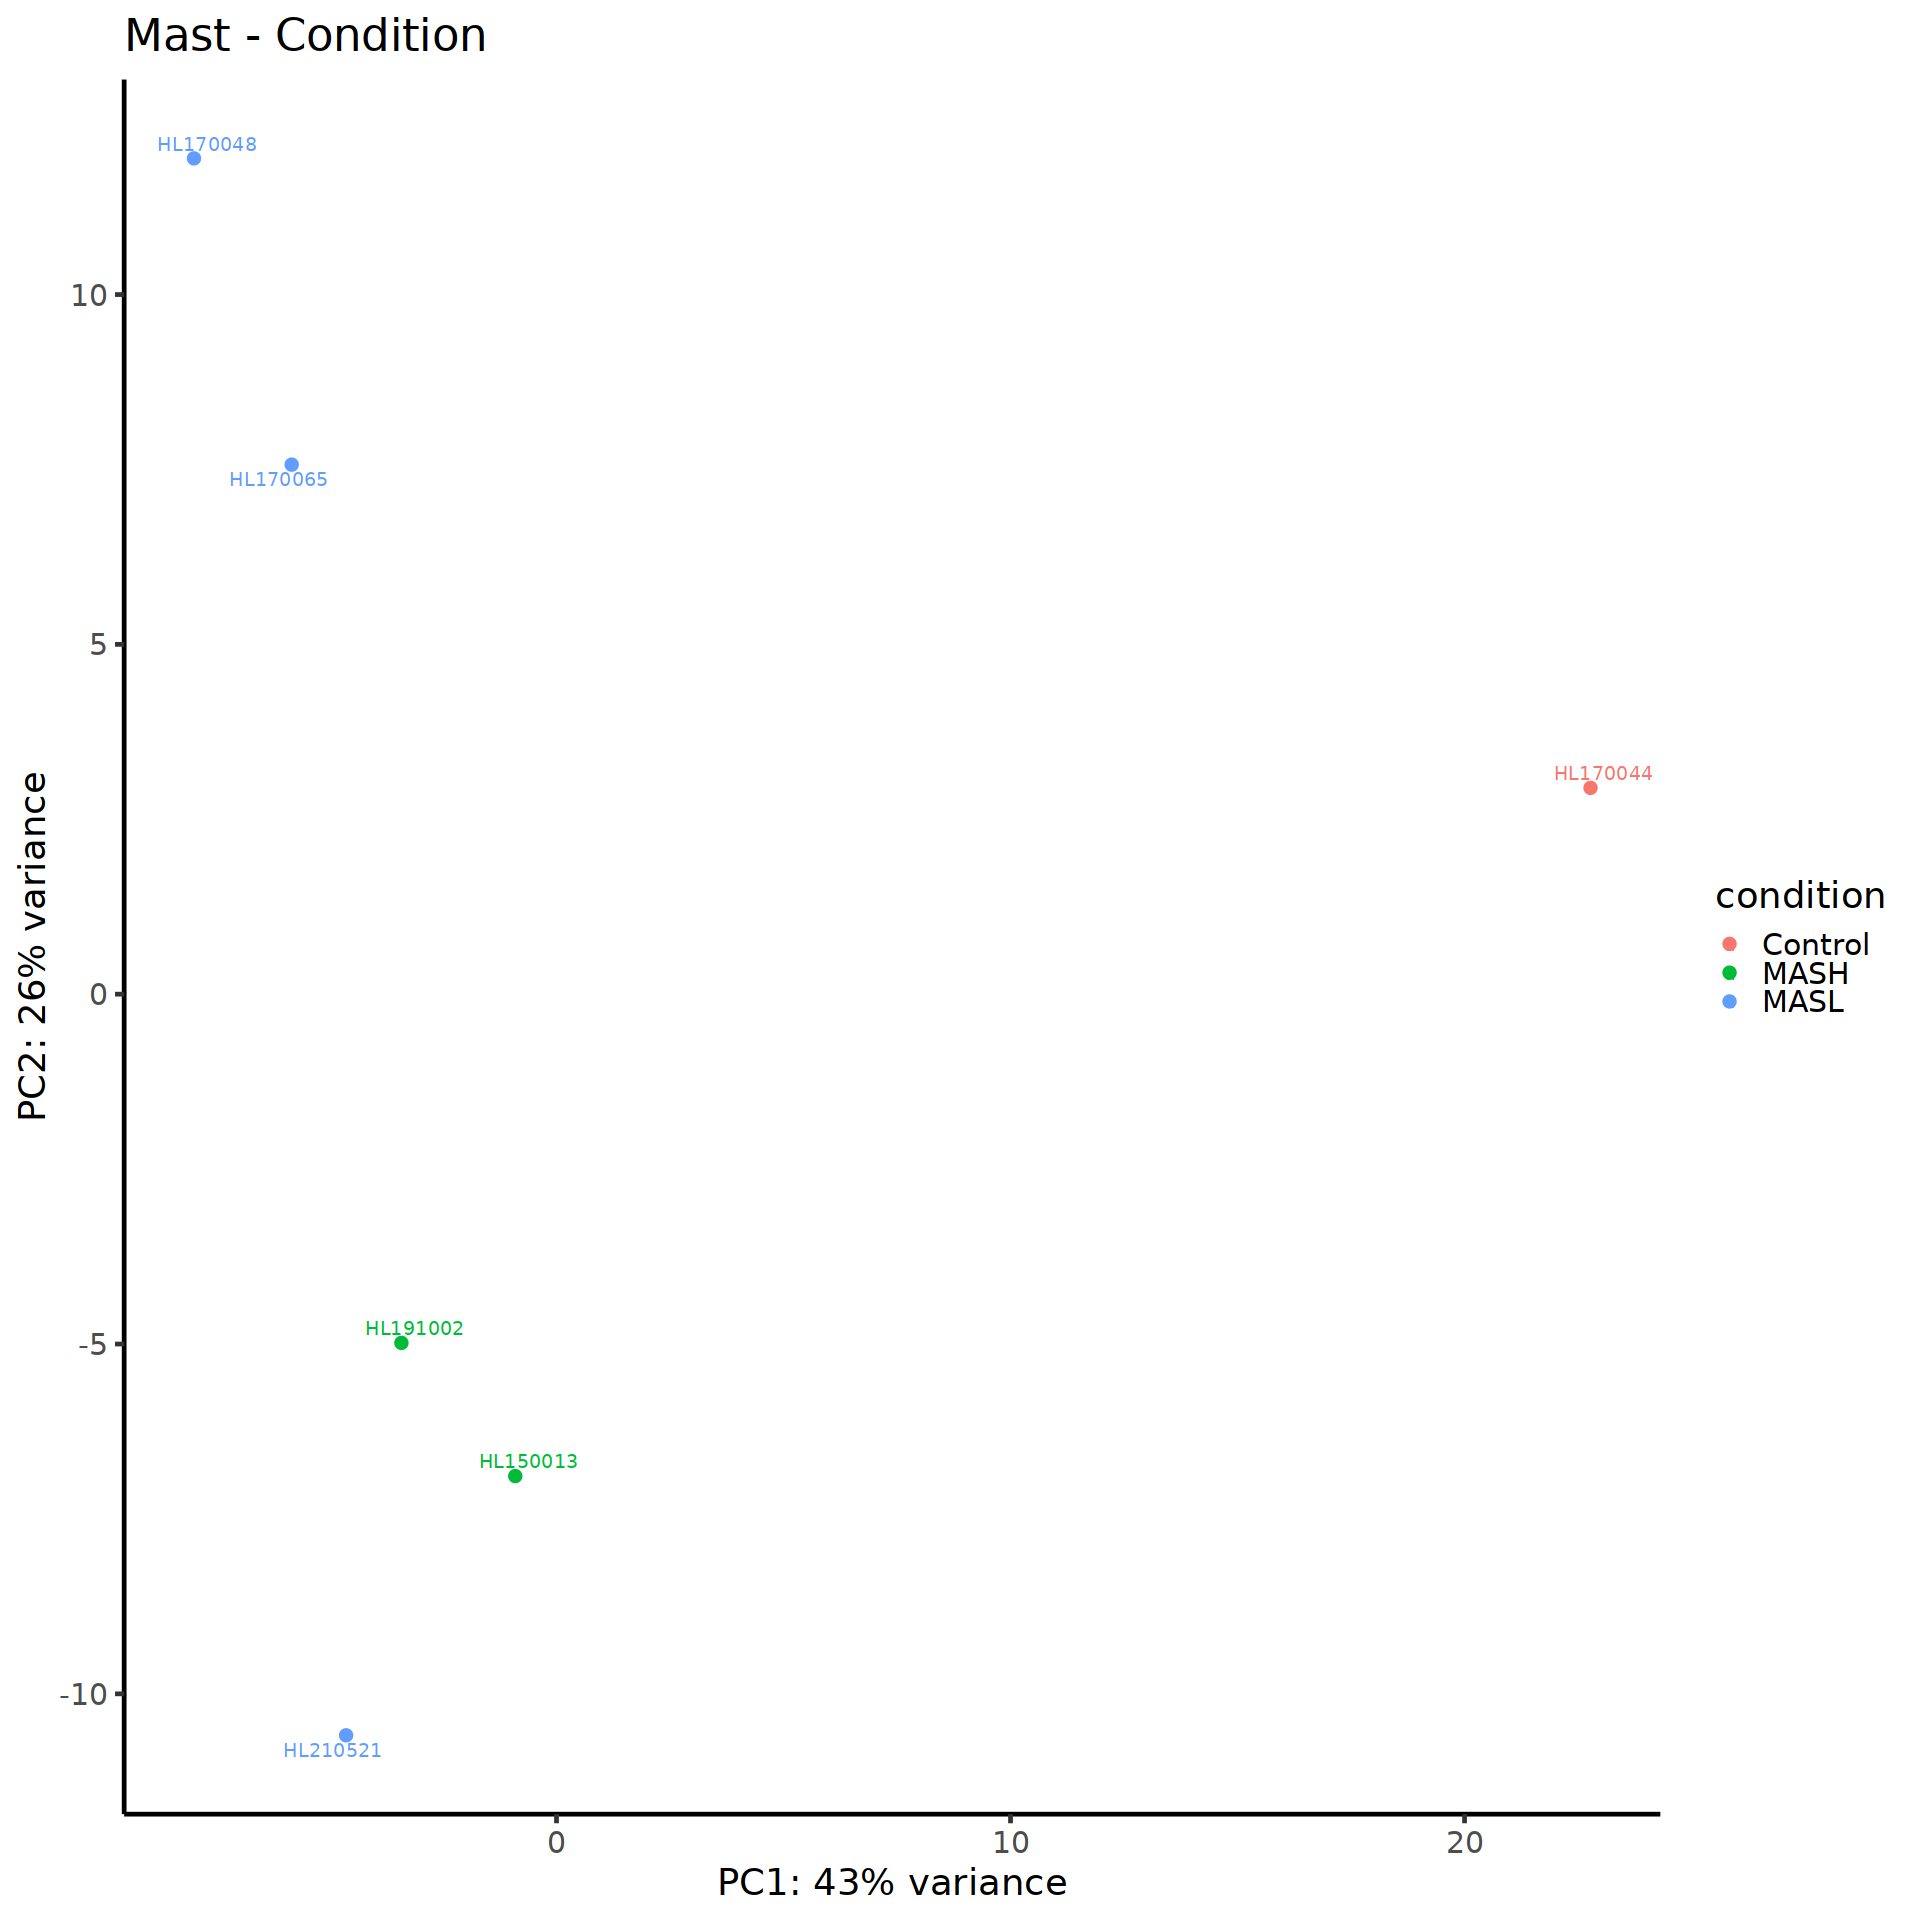

Warning message:
“ggrepel: 54 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: NK"
[1] 36601    85


Donors detectected with celltype: 85

subsetting metadata accordingly - Check that value is equal to above: 85

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



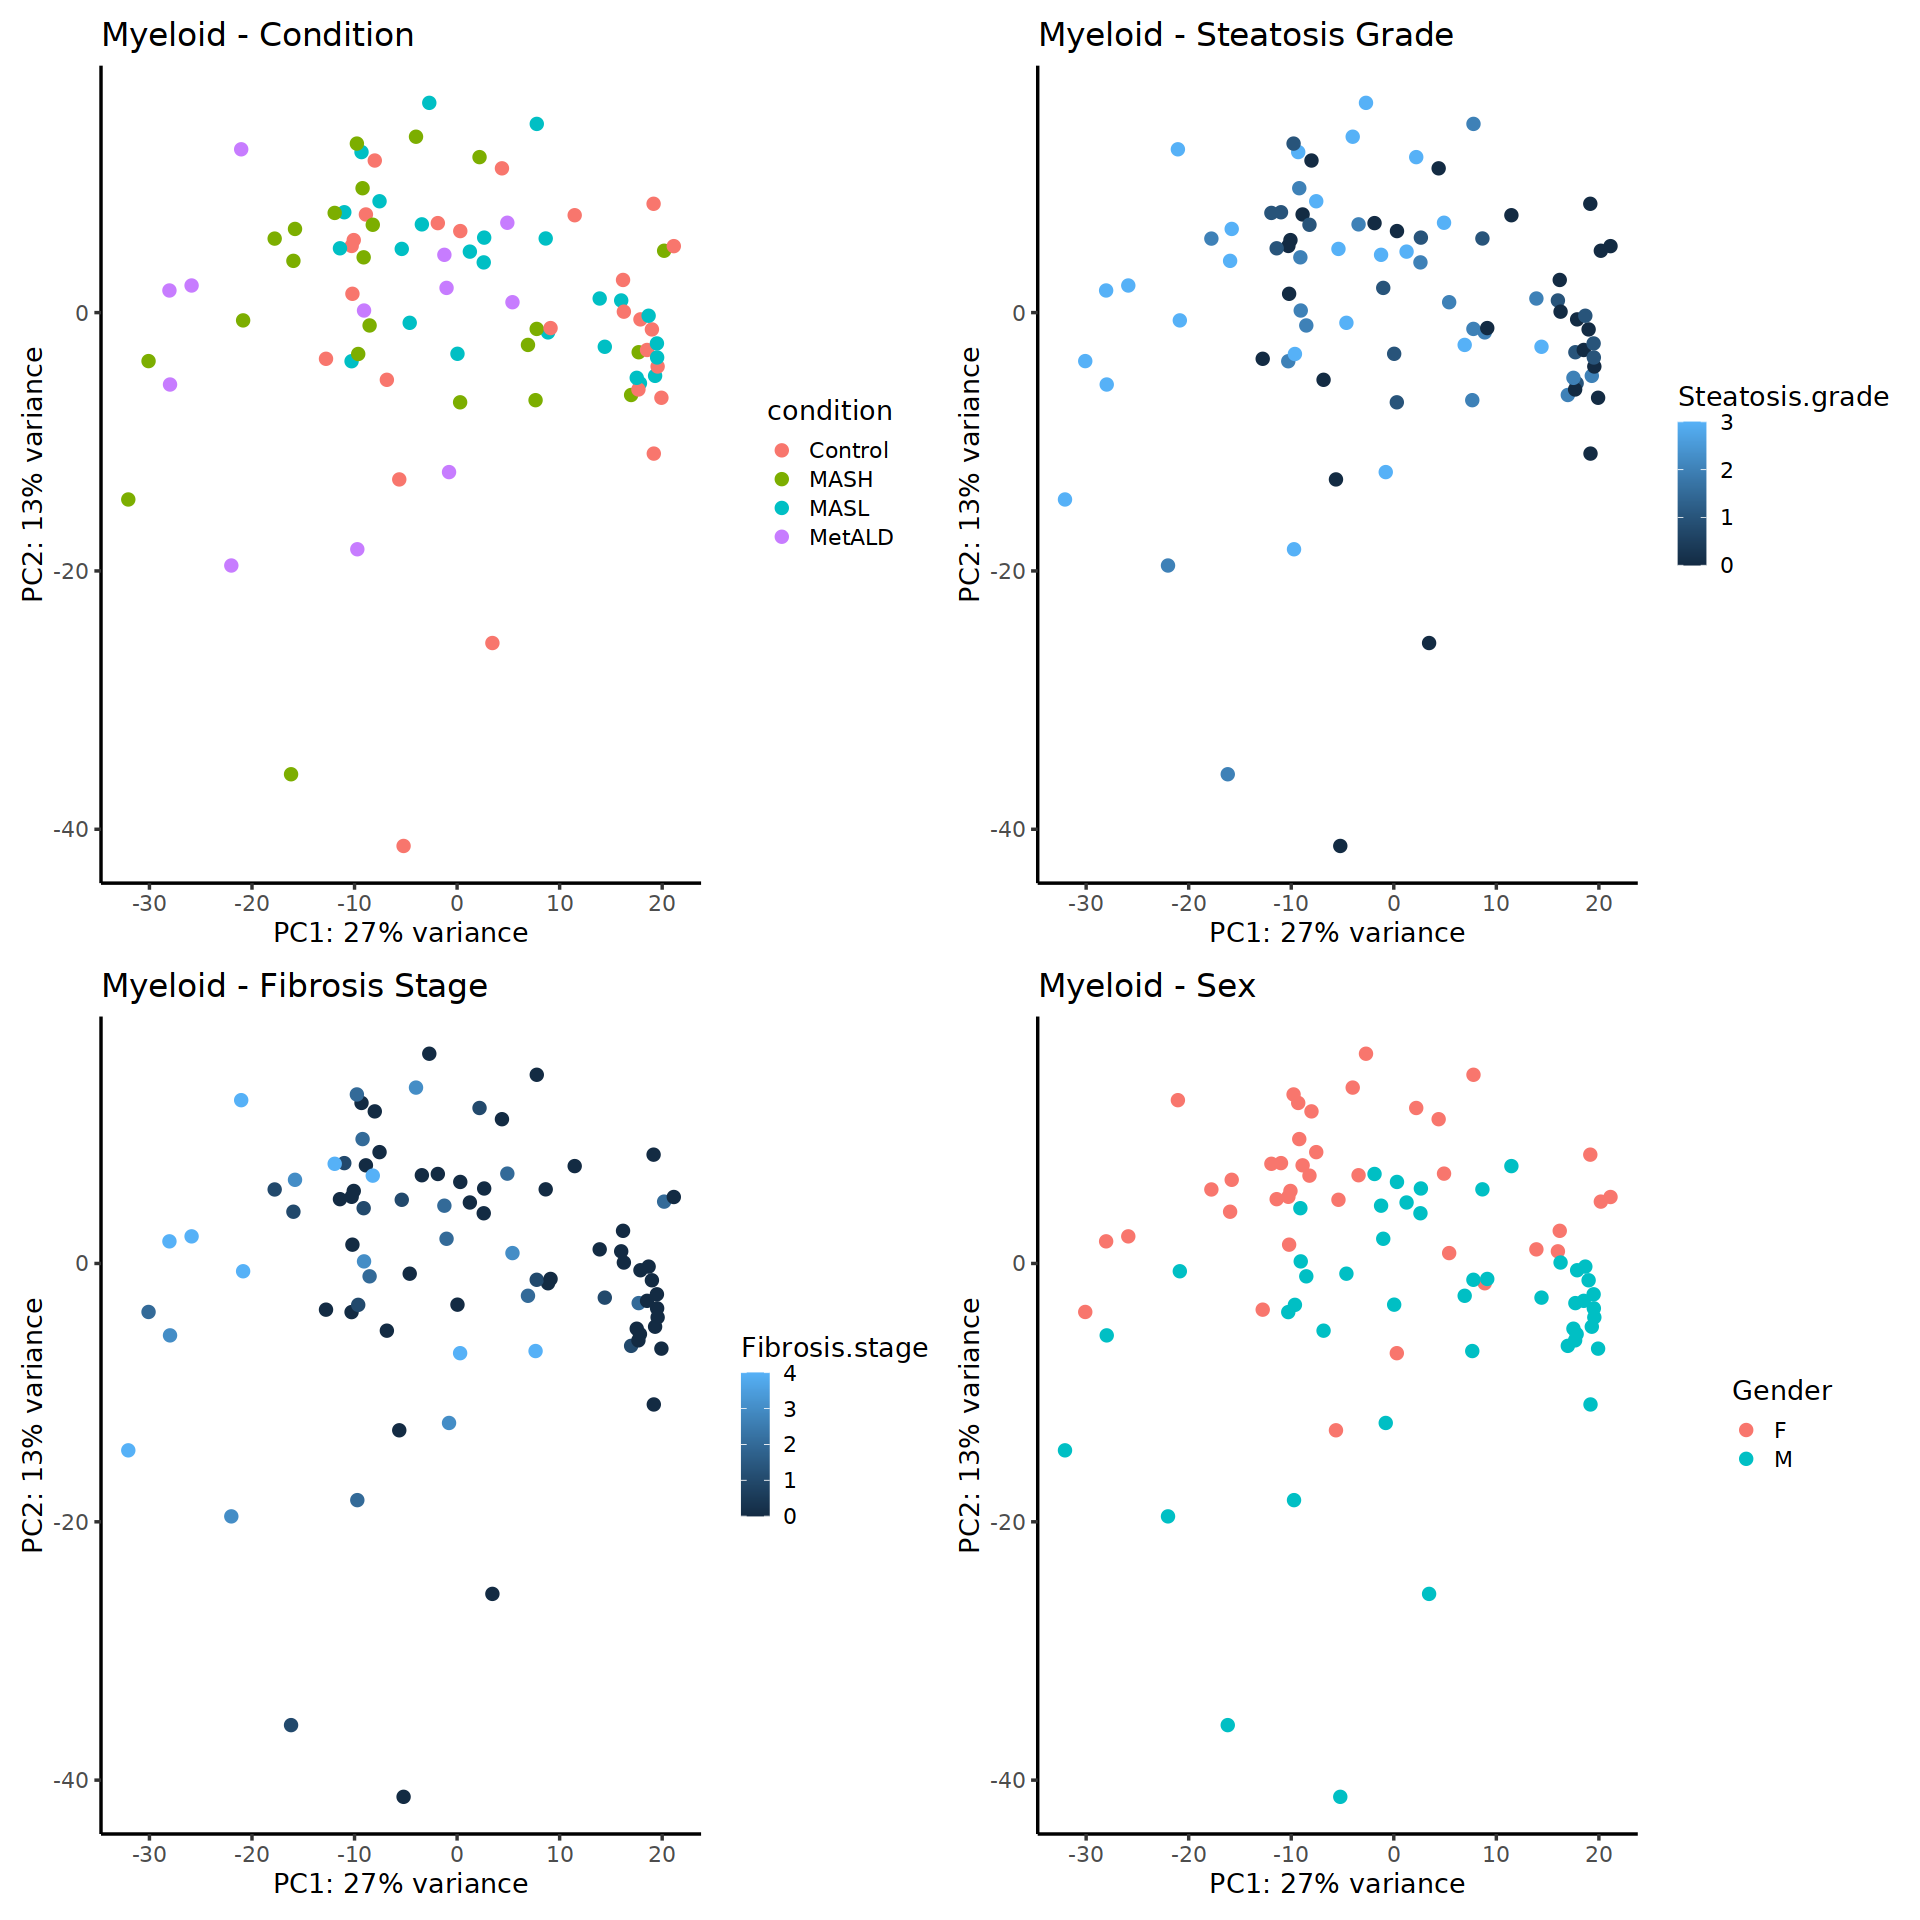

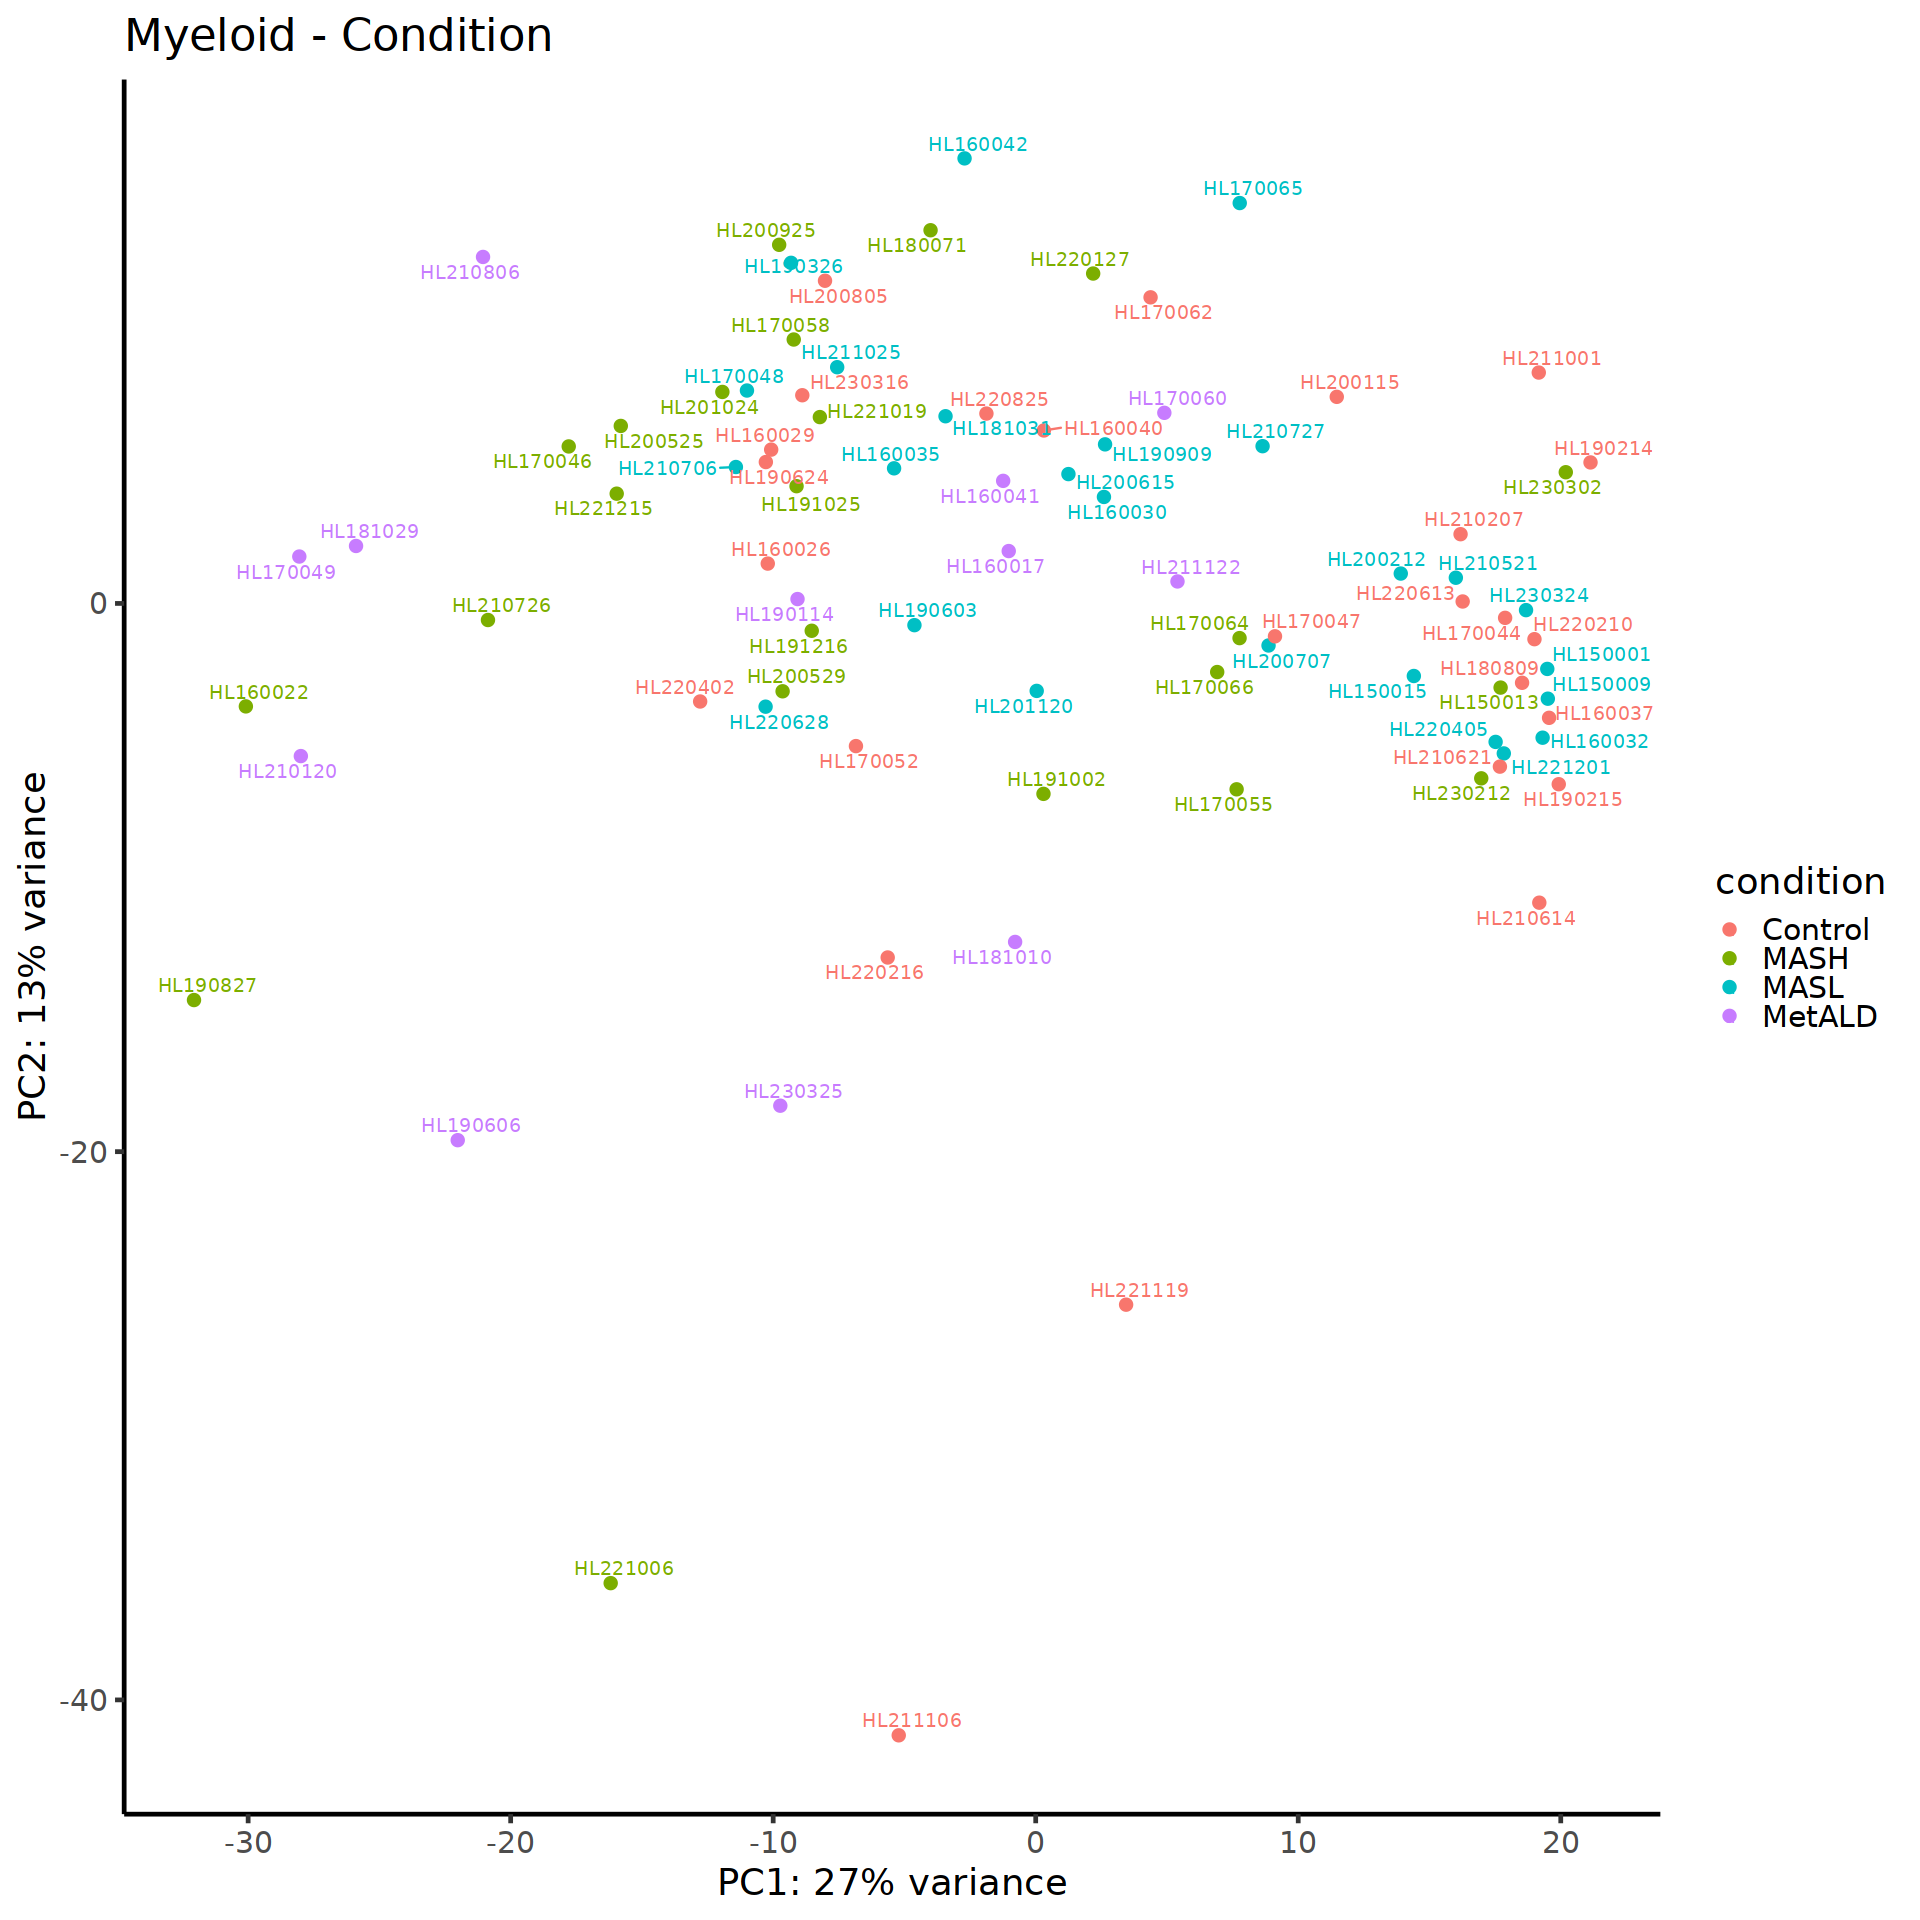

Warning message:
“ggrepel: 46 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Analyzing: Schwann"
[1] 36601     8


Donors detectected with celltype: 8

subsetting metadata accordingly - Check that value is equal to above: 8

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



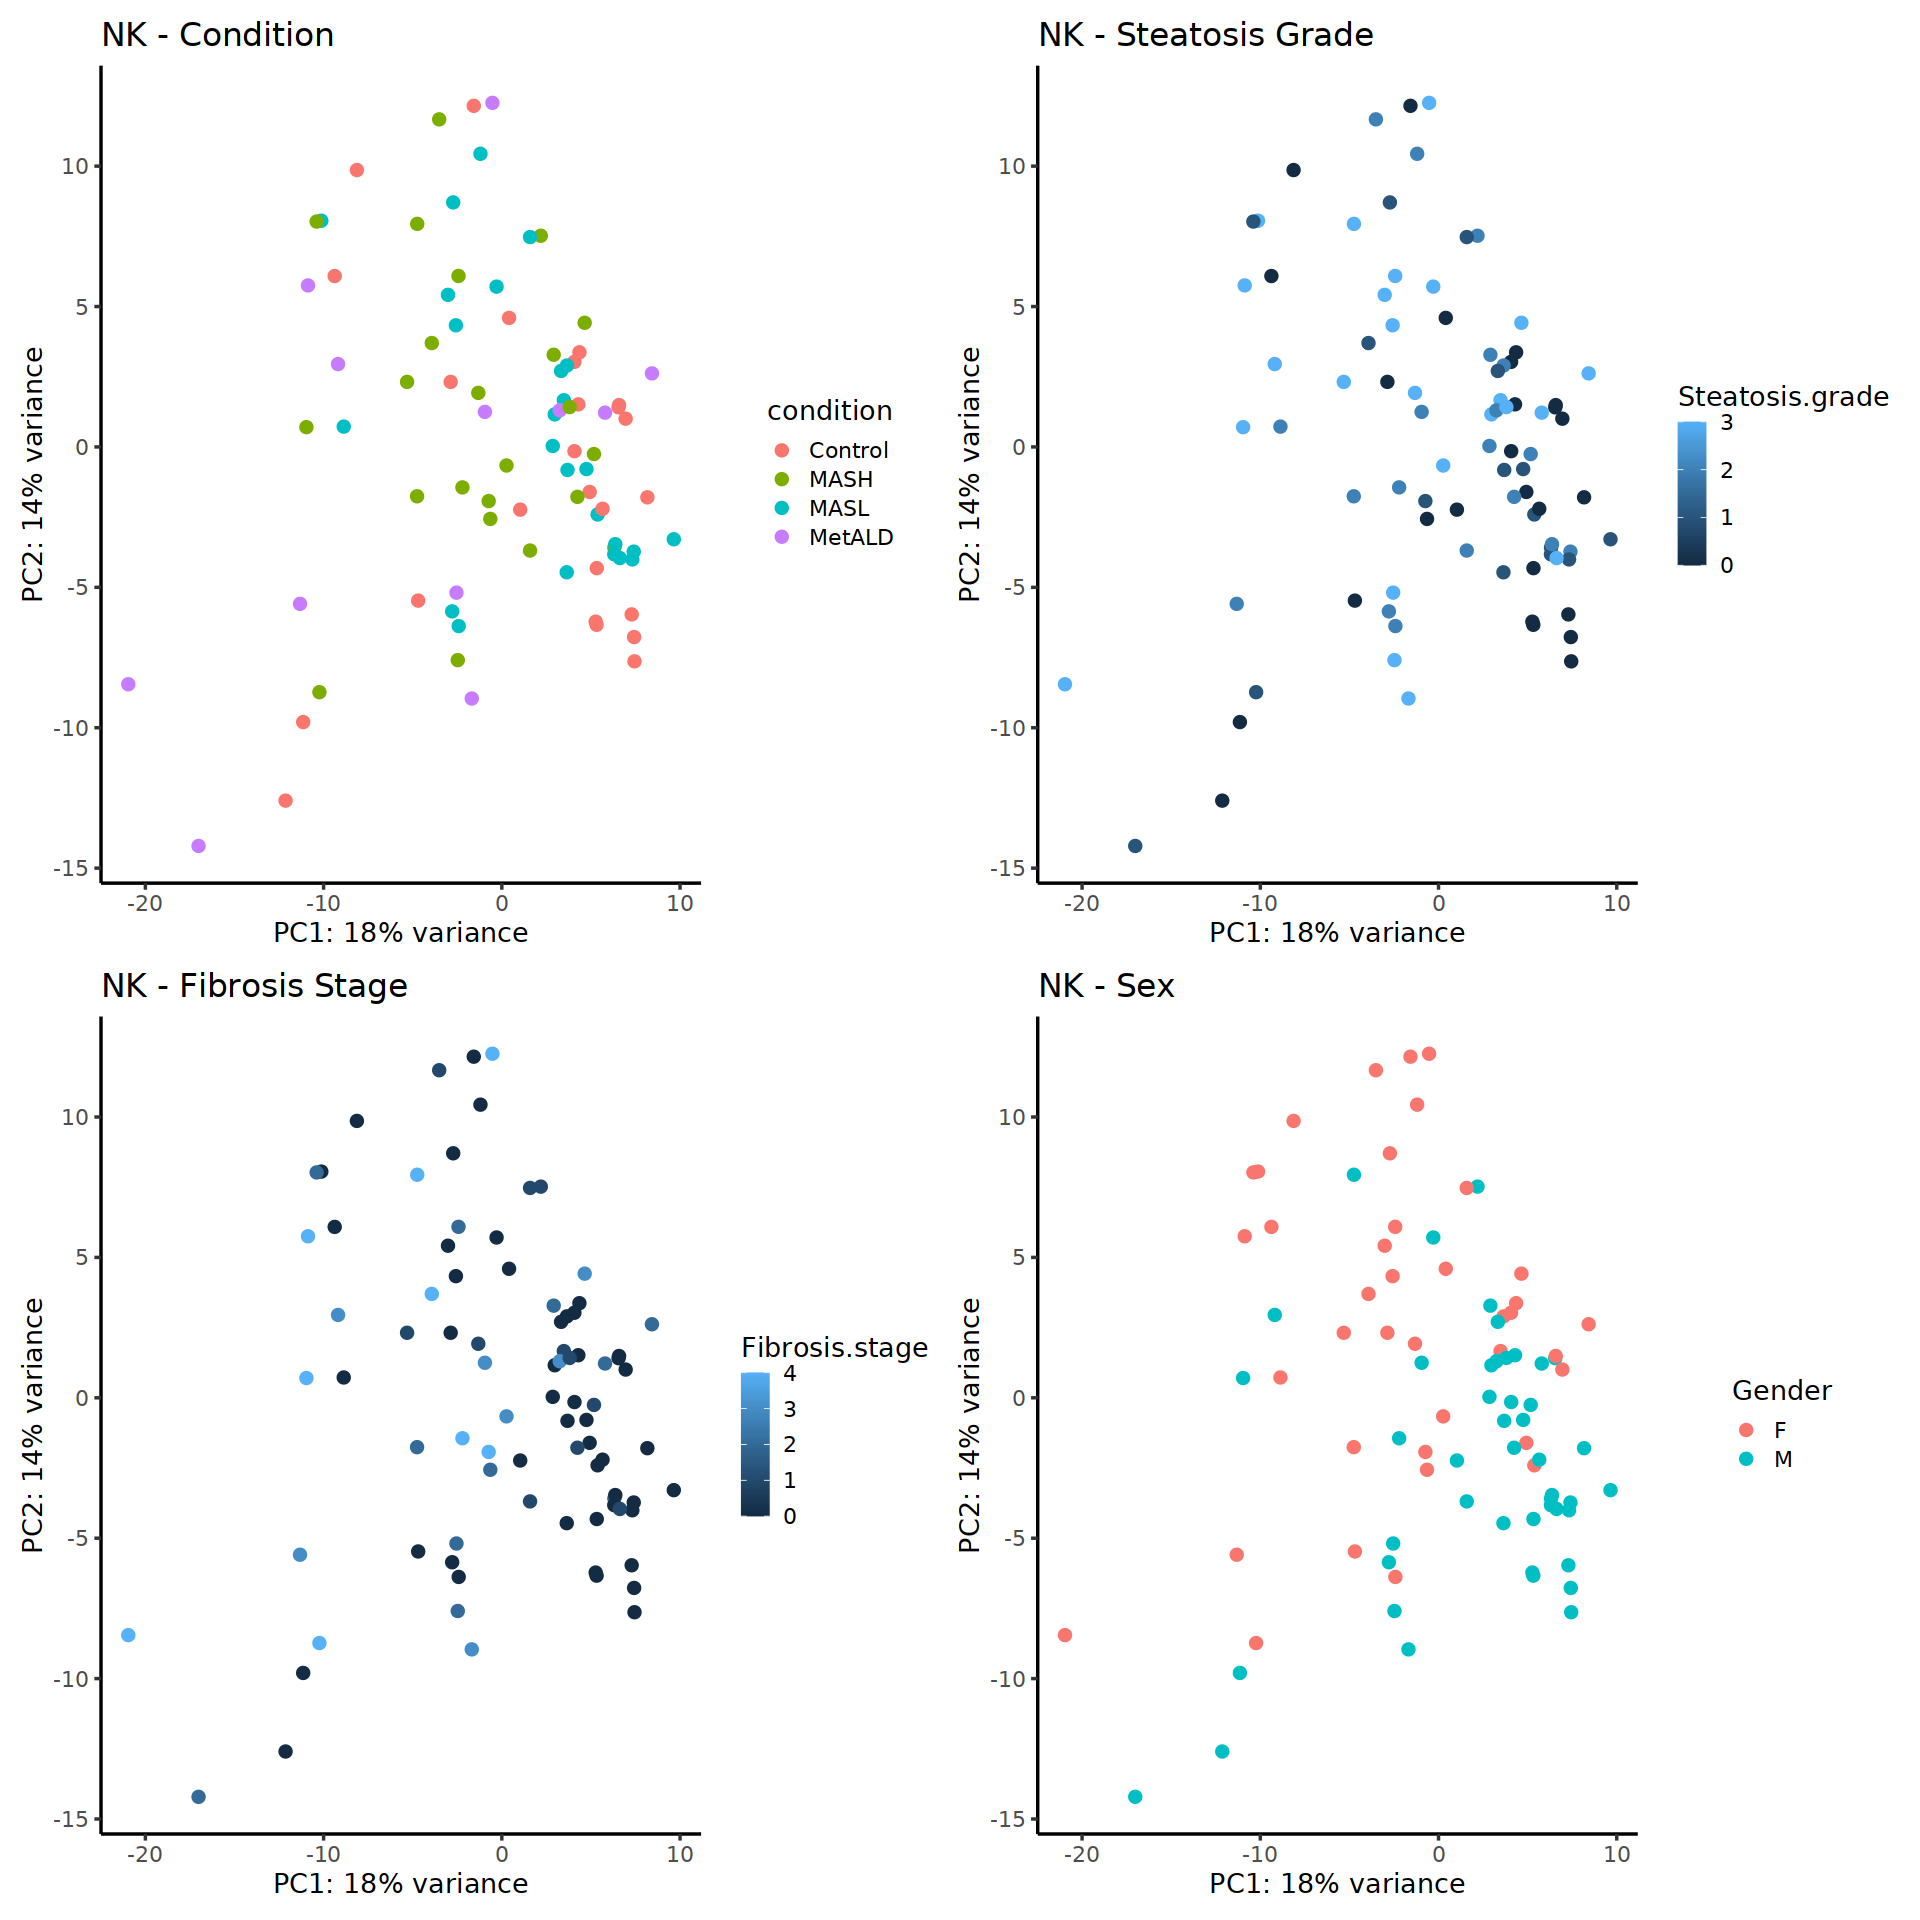

Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


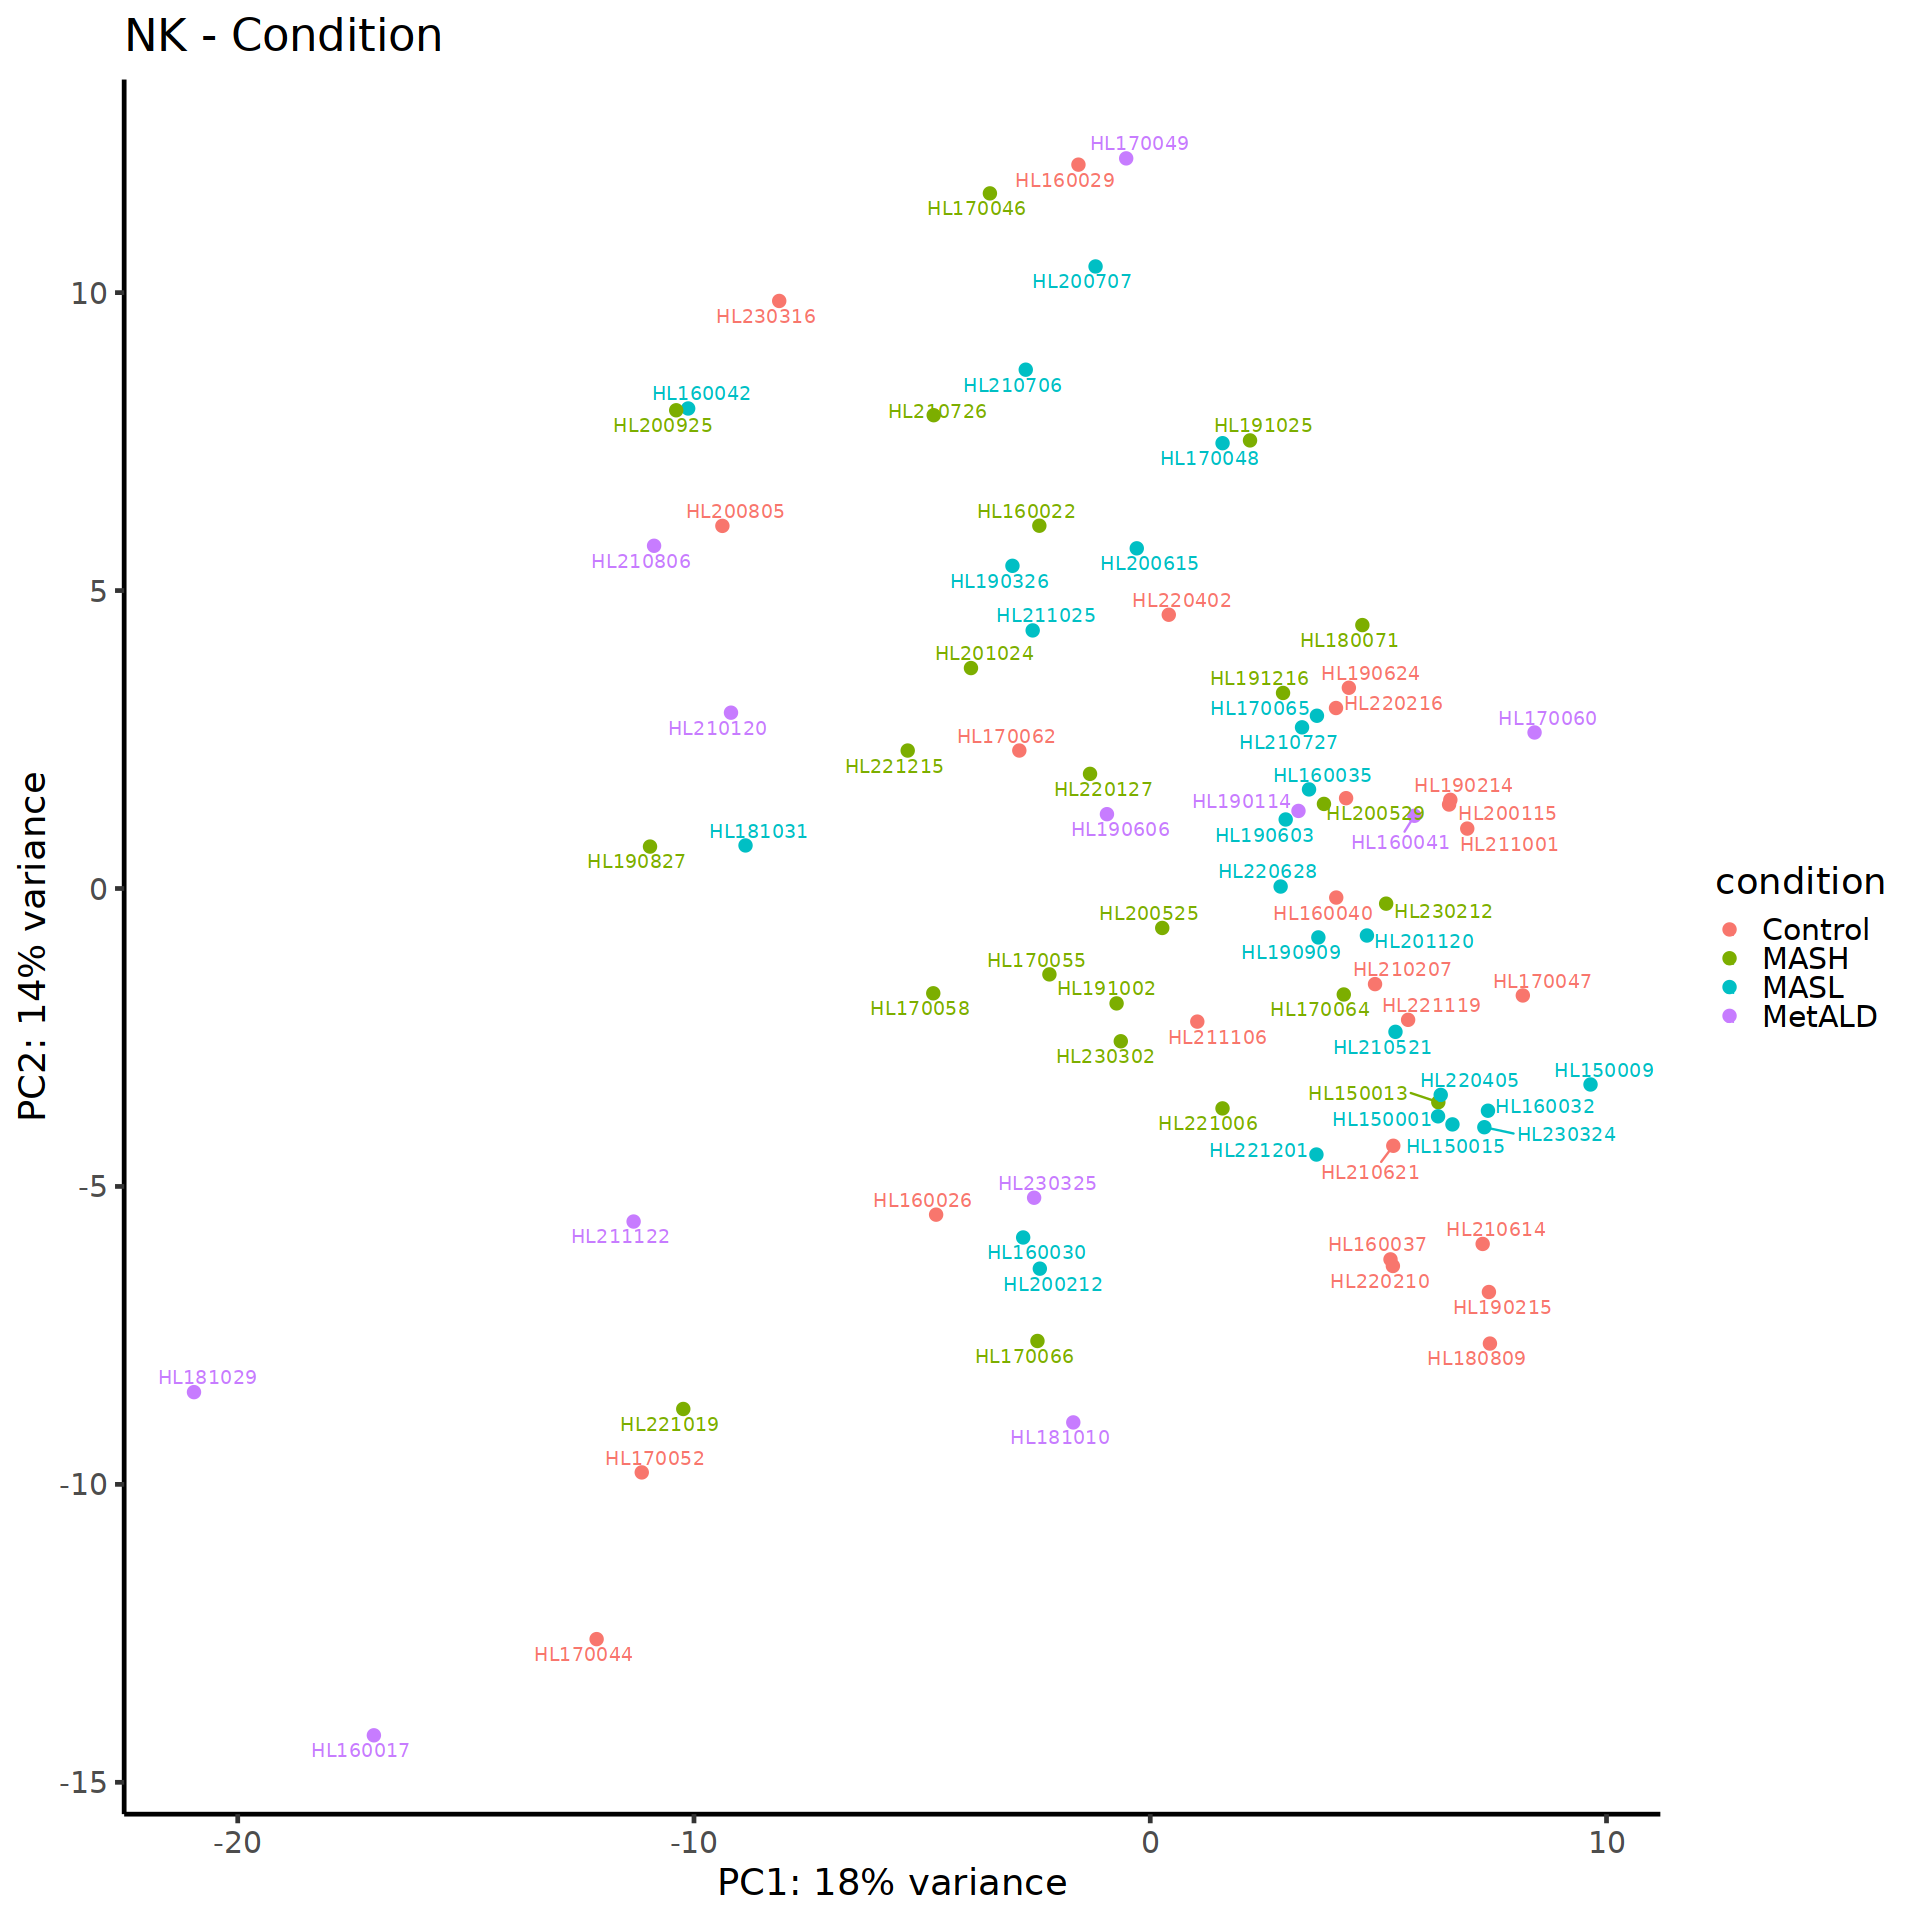

[1] "Analyzing: T"
[1] 36601    86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
using ntop=500 top features by variance



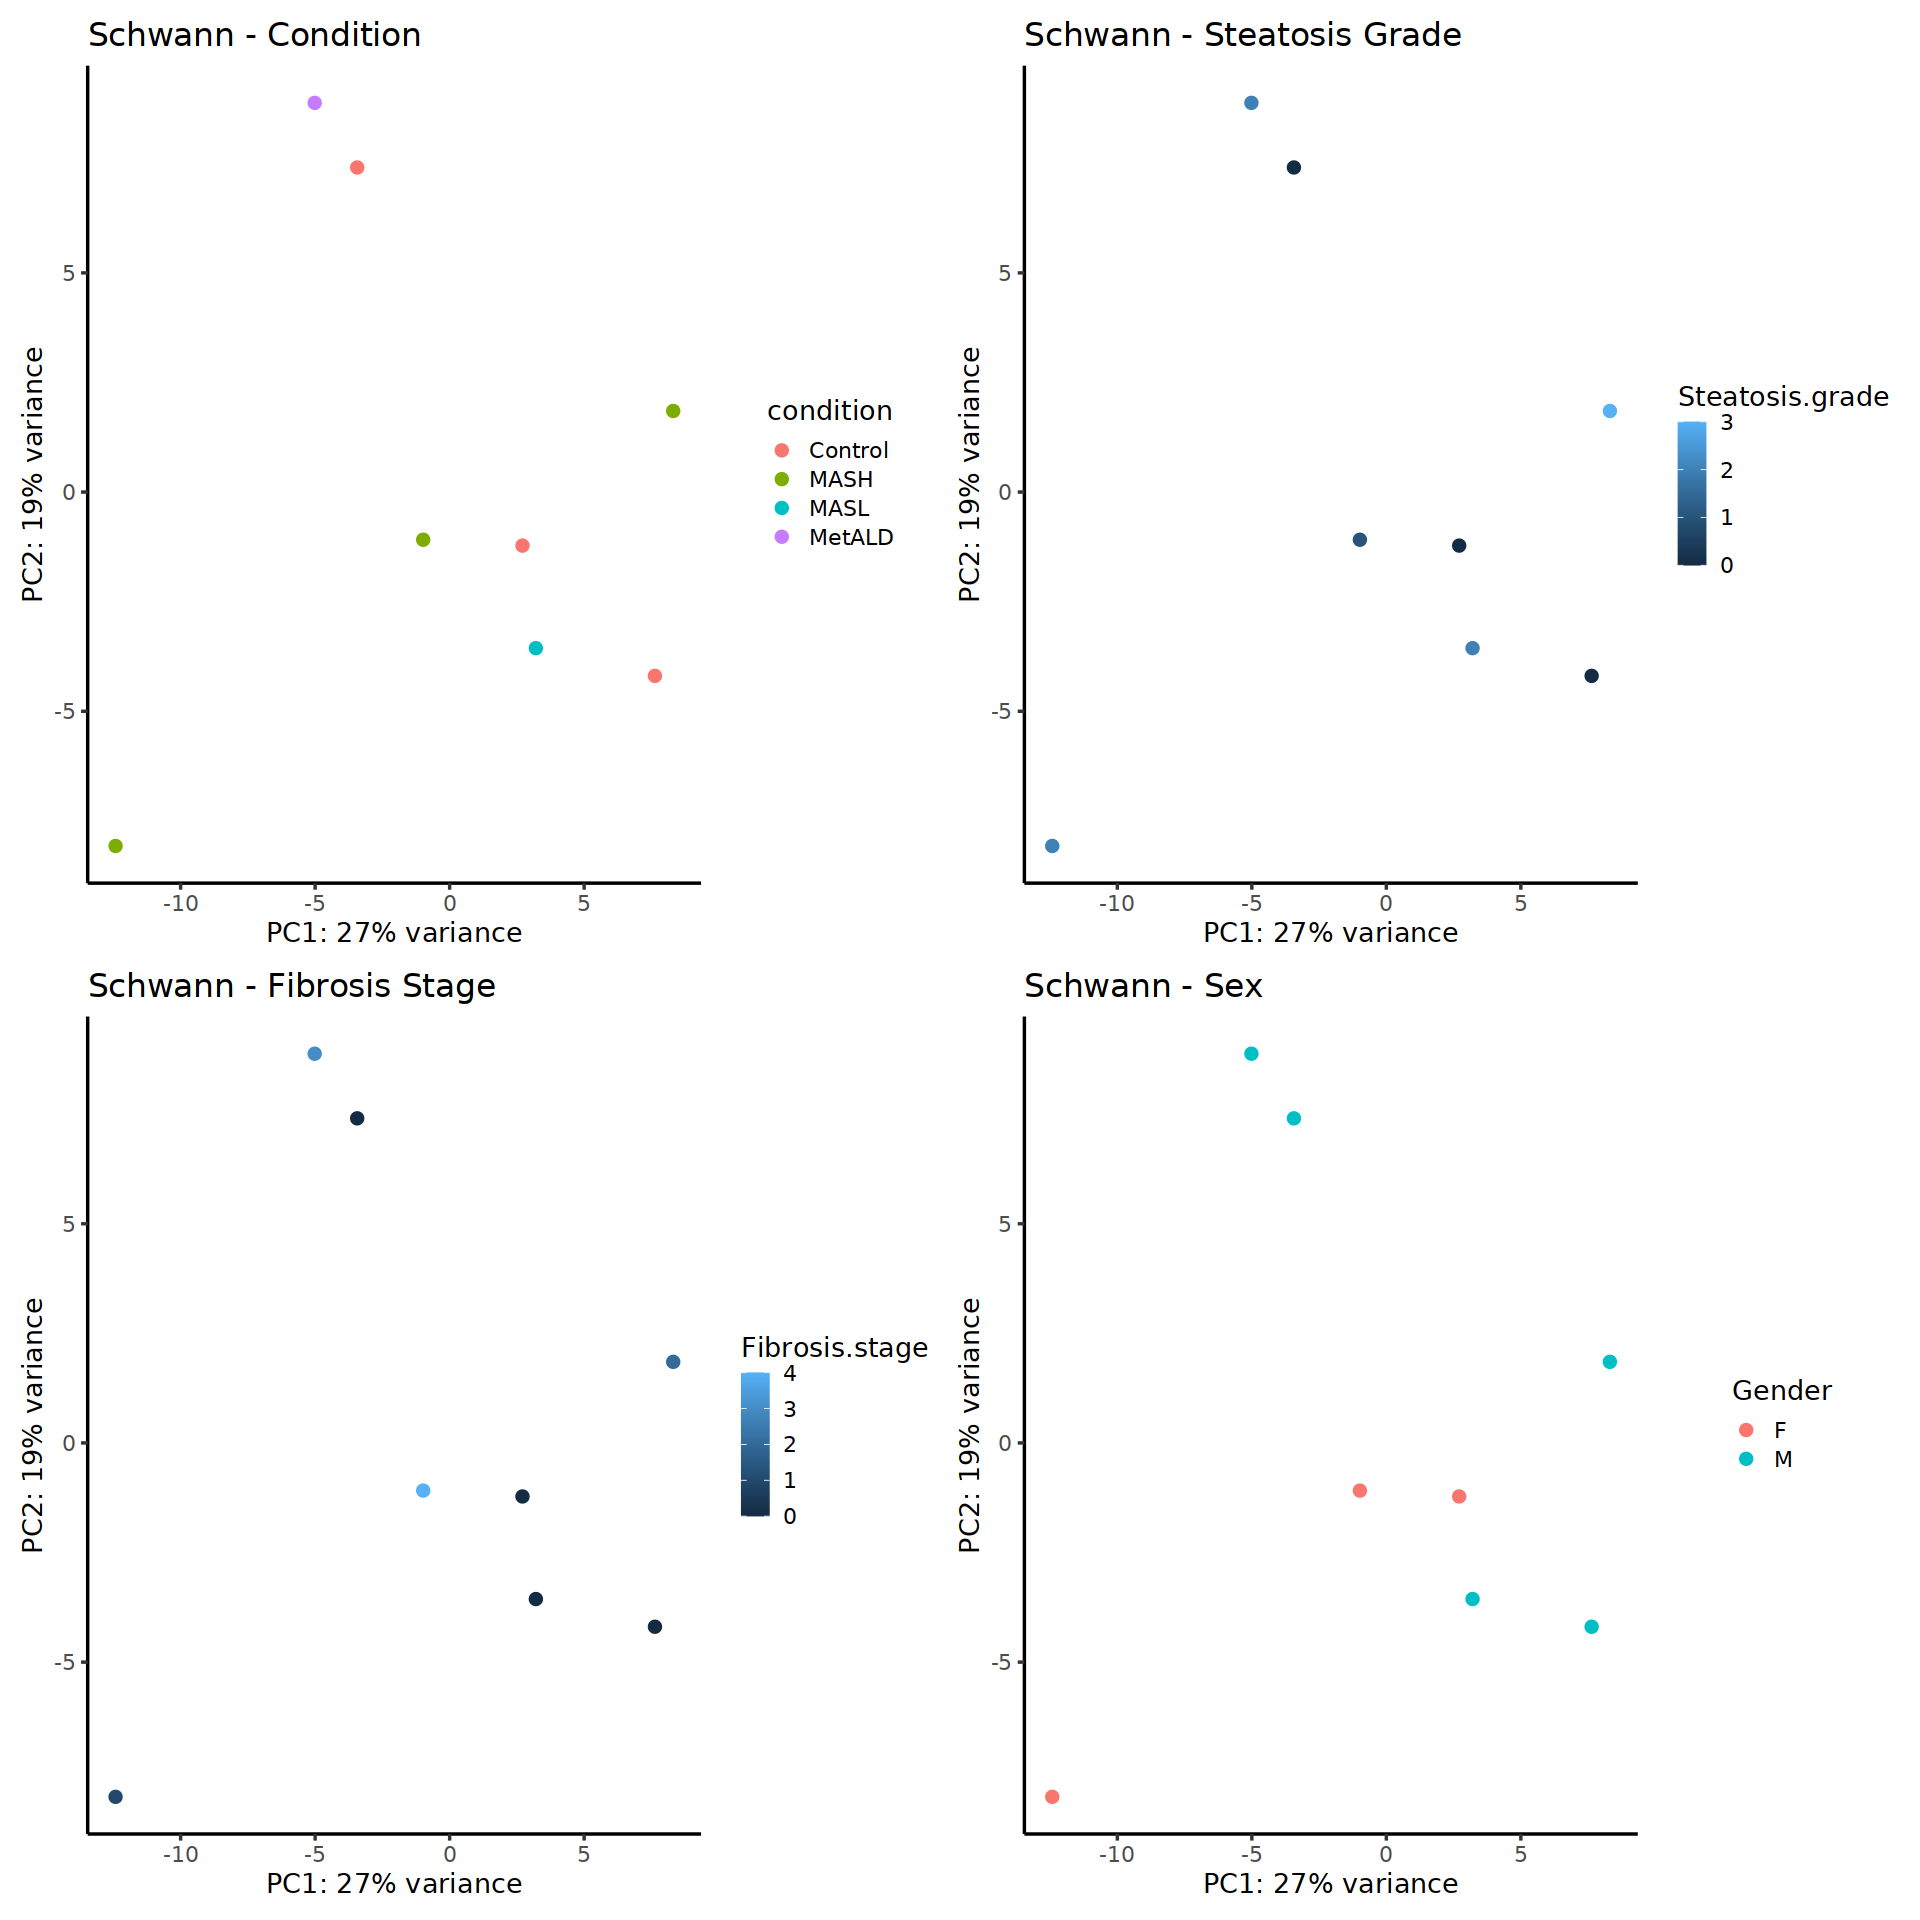

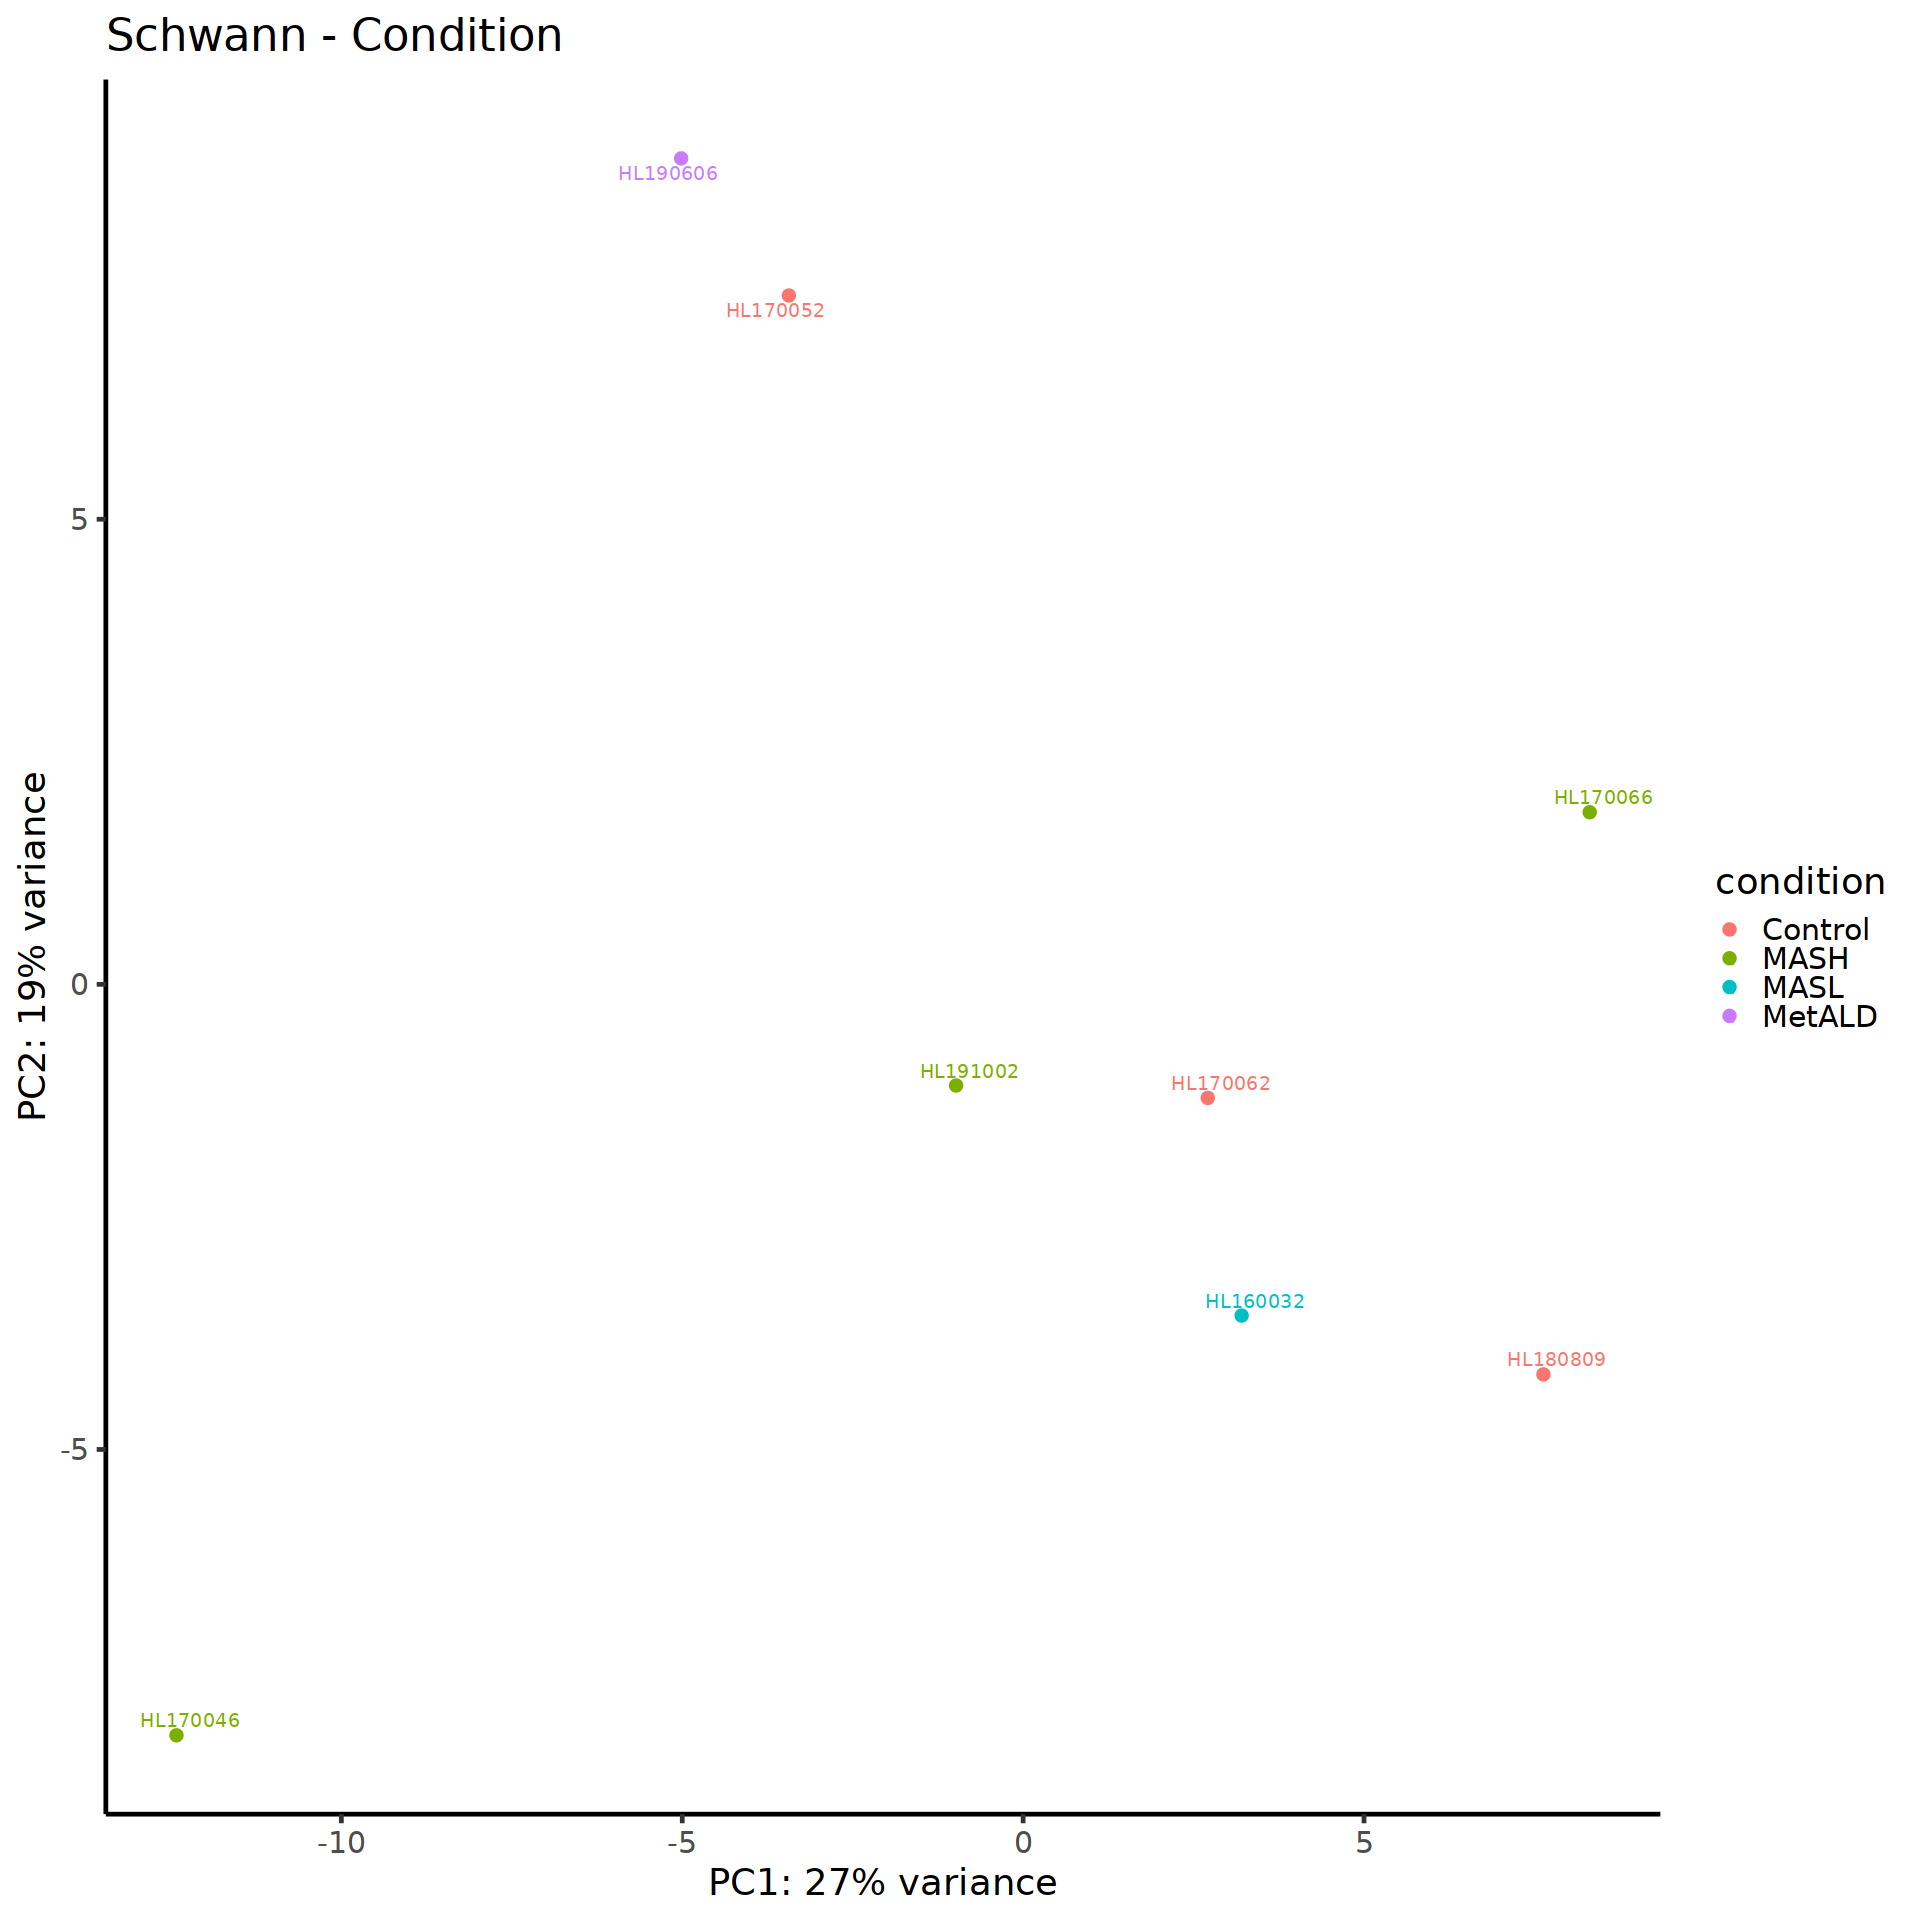

Warning message:
“ggrepel: 34 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


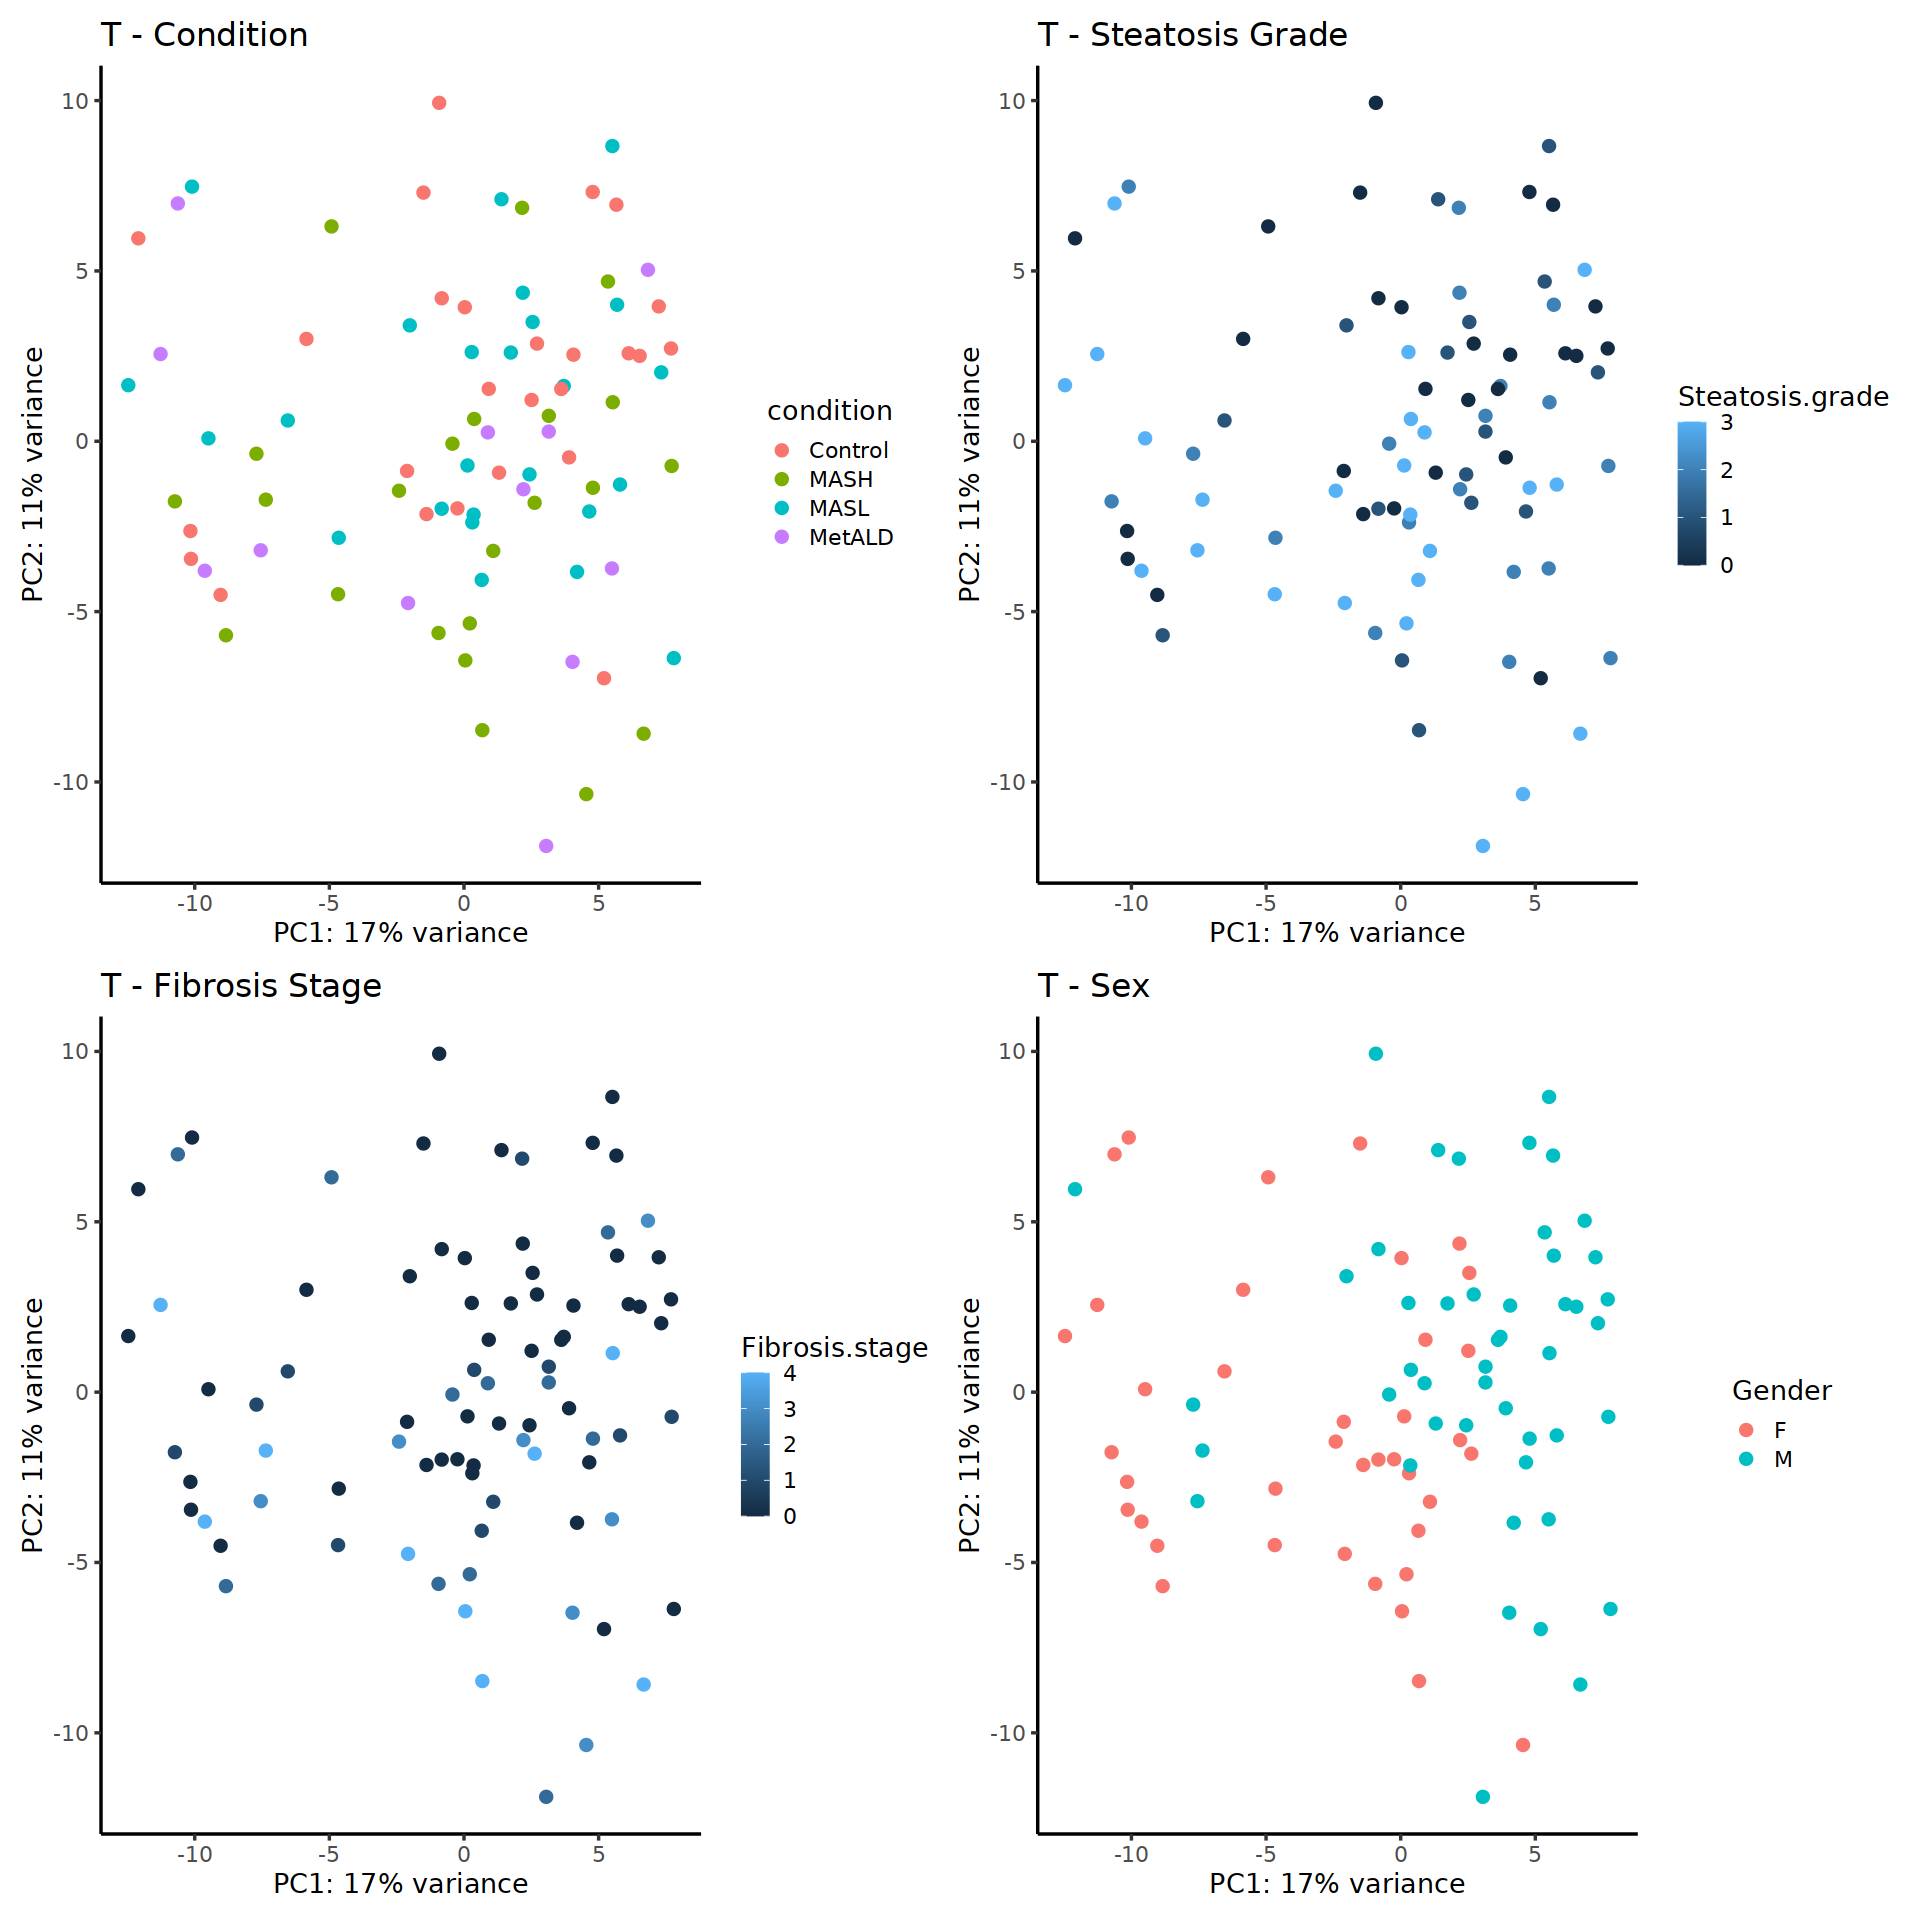

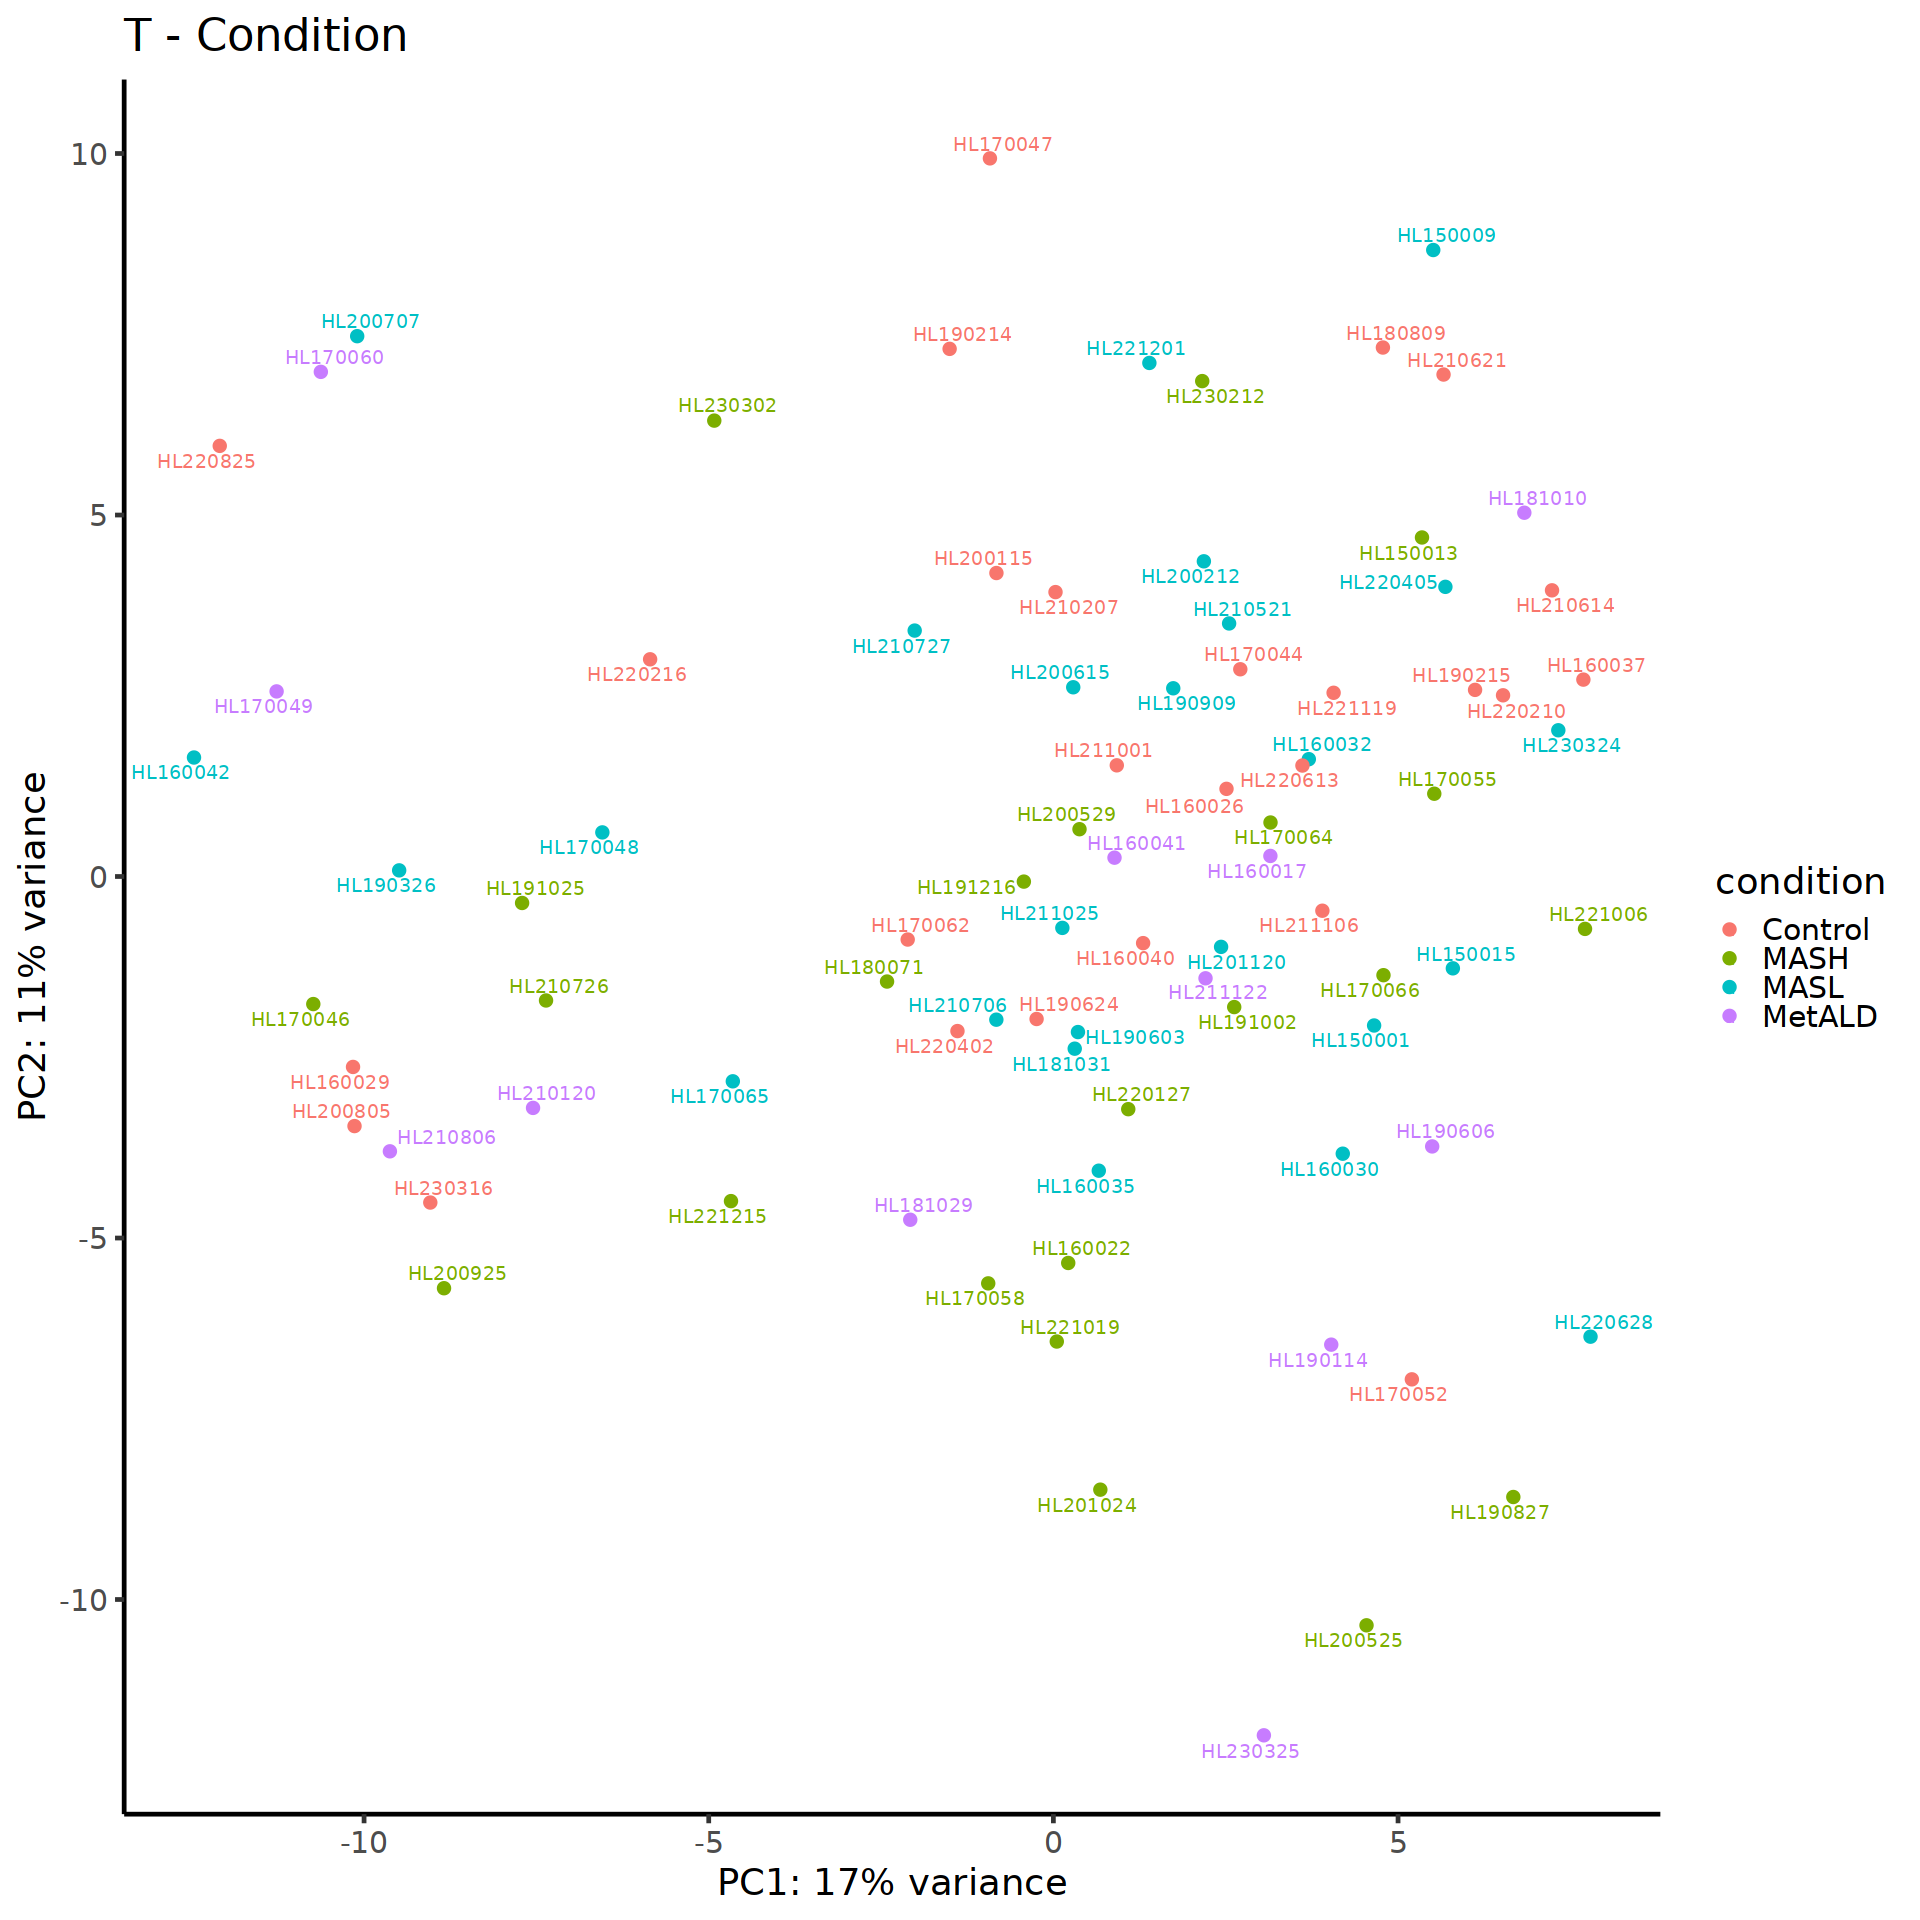

In [6]:
options(repr.plot.width=16, repr.plot.height=16)
pca_data <- list()

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    if (cell.use != 'Bulk') {
        raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    }
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    dds <- DESeqDataSetFromMatrix(countData = raw_counts,
                              colData = meta_cell,
                              design = ~ condition)
    dds <- estimateSizeFactors(dds)
    if (sum( rowMeans( counts(dds, normalized=TRUE)) > 5 ) < 1000) {
        vsd <- vst(dds, blind=FALSE, nsub = sum( rowMeans( counts(dds, normalized=TRUE)) > 5 ))
    } else {
        vsd <- vst(dds, blind=FALSE)
    }
    
    pcaData <- plotPCA(vsd, intgroup=c("condition"), returnData=TRUE)
    pca_data[[cell.use]] <- left_join(pcaData, select(meta_cell, -condition), join_by(name==donor_demux))
    gc()
    
    percentVar <- round(100 * attr(pca_data[[cell.use]], "percentVar"))

    p1 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=condition, label=name)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Condition')) + theme_classic(base_size=16)
        
    p2 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Steatosis.grade)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Steatosis Grade')) + theme_classic(base_size=16)
        
    p3 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Fibrosis.stage)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Fibrosis Stage')) + theme_classic(base_size=16)
        
    p4 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=Gender)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Sex')) + theme_classic(base_size=16)
    p6 <- p1 + p2 + p3 + p4
    print(p6)
    
    p5 <- ggplot(pca_data[[cell.use]], aes(PC1, PC2, color=condition, label=name)) +
          geom_point(size=3) +
          xlab(paste0("PC1: ",percentVar[1],"% variance")) +
          ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
          ggtitle(paste0(cell.use,' - Condition')) + theme_classic(base_size=22) + ggrepel::geom_text_repel(size=4)
    print(p5)
    
    write.table(pca_data[[cell.use]], paste0(outdir, cell.use, '_PCA.tsv'),
               sep='\t', col.names=T, row.names=T, quote=F)
}

# DESeq2 - Conditions status

In [8]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/RNA.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,HL150001,85,47,746,8760,308,4,726,167,8,⋯,0,0,0,0,1,M,47,27.1,-0.6385847,-0.01553551
2,HL150009,19,34,459,2317,329,0,227,23,6,⋯,0,0,0,0,1,M,37,29.4,-0.3346869,-0.75778750


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "BMI.scaled"           "Age.scaled"

In [9]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/'
# dir.create(outdir)
dir.create(paste0(outdir, 'na.keep/'))
#Get list of pseudobulk files
files <- list.files(dir, pattern='_perdonor.RNA.counts.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_perdonor.RNA.counts.tsv','', files) 

Warning message in dir.create(paste0(outdir, "na.keep/")):
“'/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/na.keep' already exists”


In [10]:
files
cells

[1] "B_perdonor.RNA.counts.tsv"            
 [2] "Bulk_perdonor.RNA.counts.tsv"         
 [3] "Cholangiocyte_perdonor.RNA.counts.tsv"
 [4] "Endothelial_perdonor.RNA.counts.tsv"  
 [5] "Hepatocytes_perdonor.RNA.counts.tsv"  
 [6] "HSC_perdonor.RNA.counts.tsv"          
 [7] "Mast_perdonor.RNA.counts.tsv"         
 [8] "Myeloid_perdonor.RNA.counts.tsv"      
 [9] "NK_perdonor.RNA.counts.tsv"           
[10] "Schwann_perdonor.RNA.counts.tsv"      
[11] "T_perdonor.RNA.counts.tsv"

[1] "B"             "Bulk"          "Cholangiocyte" "Endothelial"  
 [5] "Hepatocytes"   "HSC"           "Mast"          "Myeloid"      
 [9] "NK"            "Schwann"       "T"

In [11]:
# List your contrasts  
conditions.1 = c("MASL", "MASH", "MetALD") # disease
conditions.2 = c("Control", "Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [ ]:
deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc donors
    raw_counts <- raw_counts[, colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.1) %>% 
                               pull(donor)
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            print(typeof(meta_cell.use$condition))
            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, 'na.keep/', cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            #write.table(dds.results, 
            #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
            #            sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            #ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                            #       height = 10, width = 10,
                            #       plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

In [9]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,302,235,9,2
B,MASH_vs_Control,272,226,19,10
B,MetALD_vs_Control,404,235,5,12
Cholangiocyte,MASL_vs_Control,391,443,1,0
Cholangiocyte,MASH_vs_Control,855,534,87,53
Cholangiocyte,MetALD_vs_Control,1109,934,498,353
Endothelial,MASL_vs_Control,954,1046,6,7
Endothelial,MASH_vs_Control,1223,660,228,52
Endothelial,MetALD_vs_Control,1203,661,323,101


In [ ]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

In [ ]:
deseq.stats2 <- deseq.stats

In [ ]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T)),'.'))                           

In [ ]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### MASH_ALL

In [16]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    contrast.use <- 'MASH_ALL_vs_Control'
    
    condition.1 = c('MASH','MetALD')
    condition.2 = 'Control'
    message(" - ", contrast.use)

    # Create vectors of samples for each condition
    samples.condition.1 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.1) %>% 
                           pull(donor)
    samples.condition.2 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.2) %>% 
                           pull(donor)
    
    if(length(samples.condition.1) < 3) {
        next
    }
    if(length(samples.condition.2) < 3) {
        next
    }
    
    # Subset meta_cell for the current contrast
    meta_cell.use <- meta_cell %>% 
                 dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
    meta_cell.use[meta_cell.use$condition == 'MASH',]$condition <- 'MASH_ALL'
    meta_cell.use[meta_cell.use$condition == 'MetALD',]$condition <- 'MASH_ALL'
    rownames(meta_cell.use) <- meta_cell.use$donor
    
    # Subset raw_counts for the donors in meta_cell
    raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
    
    # Check if enough samples are present for both conditions
    if (length(unique(meta_cell$condition)) >= 2) {
        deseq.stats.tmp <- data.frame()
        
        # Light pre-filtering
        counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
        counts_filtered <- counts_filtered[,colSums(counts_filtered) > 0]

        # Run DESeq2
        tryCatch({
        dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                      colData = meta_cell.use, 
                                      design = deseq.formula)
        dds$condition <- relevel(dds$condition, ref = condition.2)
        dds <- DESeq(dds)
        dds.results <- results(dds)
            
        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, 'na.keep/', cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
            
        dds.results <- na.omit(dds.results[order(dds.results$padj), ])

        # Write DESeq results to file
        #write.table(dds.results, 
        #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
        #            sep = '\t', quote = FALSE)
        
        # Collect summary statistics
        deseq.stats.tmp <- data.frame(
            celltype = cell.use,
            contrast = contrast.use,
            up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
            down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
            up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
            down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
            deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                       # Make Volcano plot - Padj
                        res = as.data.frame(dds.results)
                        res$SYMBOL = rownames(res)
                        res = res %>%
                        dplyr::filter(!is.na(SYMBOL)) %>%
                        dplyr::filter(padj < 0.1) %>%
                        dplyr::group_by(sign(log2FoldChange)) %>%
                        dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                        dplyr::top_n(50, rank) %>%
                        dplyr::mutate(delabel = SYMBOL) %>%
                        ungroup() %>%
                        dplyr::select(delabel, SYMBOL) %>%
                        right_join(res) %>%
                        dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                        # Add a new column for color based on significance and direction
                        res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                            ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                        # Get the number of upregulated and downregulated genes
                        n_up <- sum(res$changes == "Up-regulated")
                        n_down <- sum(res$changes == "Down-regulated")

                        # Modify log2FoldChange values to be max x
                        res$log2FoldChange[res$log2FoldChange > 10] <- 10
                        res$log2FoldChange[res$log2FoldChange < -10] <- -10
                        # Modify padj values to be max x 
                        res$padj[res$padj < 10^-200] <- 10^-200
                
                        plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                            theme_bw() +
                            labs(y="-log10(padj)", x="log2FoldChange", 
                               title=paste(cell.use, " - ",
                                           condition.1, "Vs", condition.2, "\n",
                                          "Up: ", n_up, "-",
                                           "Down: ", n_down)) +
                            geom_point() +
                            scale_color_manual(values=c("blue", "grey", "red")) + 
                            theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                            scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                        labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                            scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                        labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                            geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                          point.padding=0, min.segment.length=0,
                                          max.time=20, max.iter=1e5, box.padding=0.3)
                
                        #ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                        #       height = 10, width = 10,
                        #       plot = plot, device = "pdf")
            #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
    } else {
        message("Not enough samples for contrast: ", contrast.use)
    }
}

[1] "Analyzing: B"
[1] 36601    77


Donors detectected with celltype: 77

subsetting metadata accordingly - Check that value is equal to above: 77

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


[1] "Analyzing: Cholangiocyte"
[1] 36601    81


Donors detectected with celltype: 81

subsetting metadata accordingly - Check that value is equal to above: 81

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


[1] "Analyzing: Endothelial"
[1] 36601    86


...

Donors detectected with celltype: 85

subsetting metadata accordingly - Check that value is equal to above: 85

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


[1] "Analyzing: Schwann"
[1] 36601     8


Donors detectected with celltype: 8

subsetting metadata accordingly - Check that value is equal to above: 8

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
Skipping contrast MASH_ALL_vs_Control: the model matrix is not full rank, so the model cannot be fit as specified.
  One or more variables or interaction terms in the design formula are linear
  combinations of the others and must be removed.

  Please read the vignette section 'Model matrix not full rank':

  vignette('DESeq2')



[1] "Analyzing: T"
[1] 36601    86


Donors detectected with celltype: 86

subsetting metadata accordingly - Check that value is equal to above: 86

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


In [16]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,302,235,9,2
B,MASH_vs_Control,272,226,19,10
B,MetALD_vs_Control,404,235,5,12
Cholangiocyte,MASL_vs_Control,391,443,1,0
Cholangiocyte,MASH_vs_Control,855,534,87,53
Cholangiocyte,MetALD_vs_Control,1109,934,498,353
Endothelial,MASL_vs_Control,954,1046,6,7
Endothelial,MASH_vs_Control,1223,660,228,52
Endothelial,MetALD_vs_Control,1203,661,323,101


In [17]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

Warning message:
“Values from `sig` are not uniquely identified; output will contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} %>%
  dplyr::group_by(celltype, contrast) %>%
  dplyr::summarise(n = dplyr::n(), .groups = "drop") %>%
  dplyr::filter(n > 1L)”


celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control
<chr>,<list>,<list>,<list>,<list>
B,11,29,17,"53, 53"
Cholangiocyte,1,140,851,"1019, 1019"
Endothelial,13,280,424,"811, 811"
Hepatocytes,30,537,584,"1088, 1088"
HSC,146,433,456,"892, 892"
Myeloid,1,649,1001,"1597, 1597"
NK,1,21,87,"103, 103"
T,1,81,55,182


In [18]:
deseq.stats2 <- deseq.stats

In [19]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control"))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

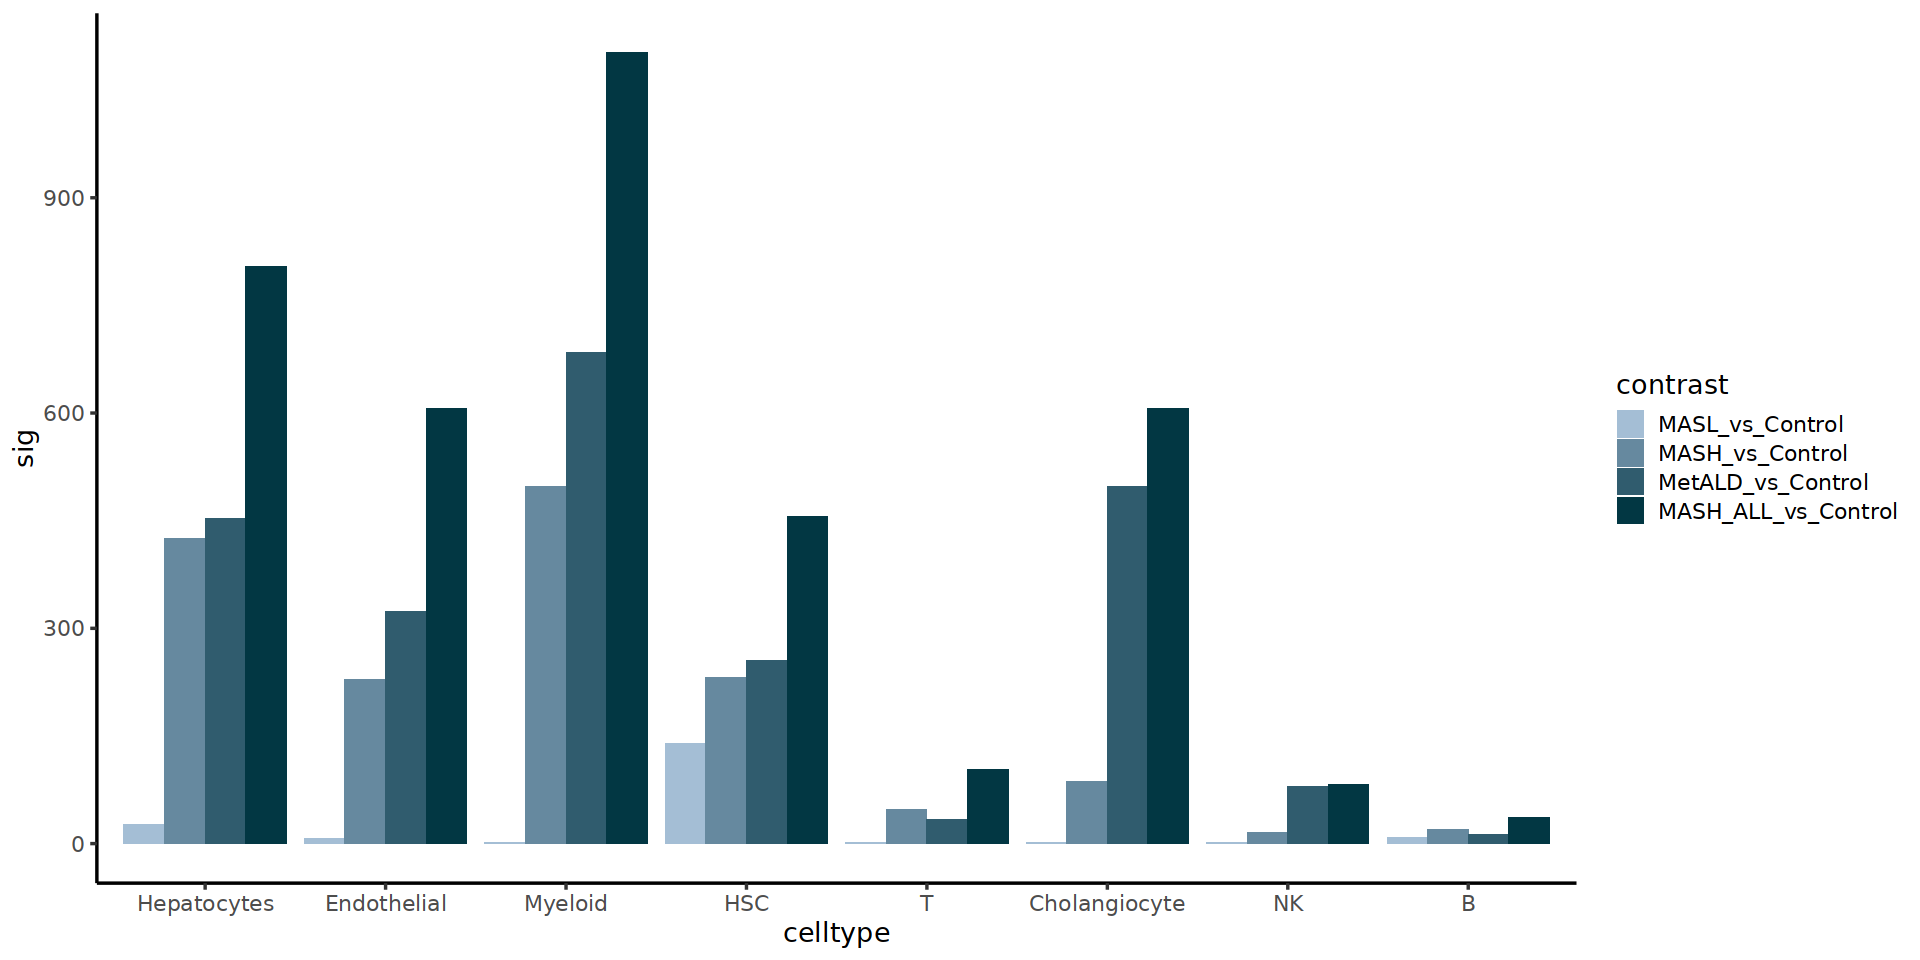

In [20]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [21]:
library(nationalparkcolors)
park_palette("Acadia")[c(5,4,2)]

[1] "#A4BED5" "#476F84" "#023743"

In [22]:
colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast)))

[1] "#A4BED5" "#66899F" "#305C6E" "#023743"

In [23]:
length(levels(deseq.stats2$contrast))

[1] 4

### Fibrosis

In [17]:
contrasts  <- c('Fibrosis.stage')


# Define the DESeq2 formula
deseq.base.formula <- '~ Age.scaled + BMI.scaled + batch + Gender'

In [18]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                        file = paste0(outdir, 'na.keep/', cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                #write.table(dds.results, 
                #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                #            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            #ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                            #       height = 10, width = 10,
                            #       plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: B"
[1] 36601    77


Donors detectected with celltype: 77

Subsetting metadata accordingly - Check that value is equal to above: 77

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


[1] "Analyzing: Cholangiocyte"
[1] 36601    81


Donors detectected with celltype: 81

Subsetting metadata accordingly - Check that value is equal to above: 81

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


[1] "Analyzing: Endothelial"
[1] 36601    86


...

Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


[1] "Analyzing: Schwann"
[1] 36601     8


Donors detectected with celltype: 8

Subsetting metadata accordingly - Check that value is equal to above: 8

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

Skipping contrast Fibrosis.stage: 

  The design matrix has the same number of samples and coefficients to fit,
  so estimation of dispersion is not possible. Treating samples
  as replicates was deprecated in v1.20 and no longer supported since v1.22.





[1] "Analyzing: T"
[1] 36601    86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`


In [26]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,302,235,9,2
B,MASH_vs_Control,272,226,19,10
B,MetALD_vs_Control,404,235,5,12
Cholangiocyte,MASL_vs_Control,391,443,1,0
Cholangiocyte,MASH_vs_Control,855,534,87,53
Cholangiocyte,MetALD_vs_Control,1109,934,498,353
Endothelial,MASL_vs_Control,954,1046,6,7
Endothelial,MASH_vs_Control,1223,660,228,52
Endothelial,MetALD_vs_Control,1203,661,323,101


In [27]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

Warning message:
“Values from `sig` are not uniquely identified; output will contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} %>%
  dplyr::group_by(celltype, contrast) %>%
  dplyr::summarise(n = dplyr::n(), .groups = "drop") %>%
  dplyr::filter(n > 1L)”


celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage
<chr>,<list>,<list>,<list>,<list>,<list>
B,11,29,17,"53, 53",258
Cholangiocyte,1,140,851,"1019, 1019",2137
Endothelial,13,280,424,"811, 811",3141
Hepatocytes,30,537,584,"1088, 1088",5338
HSC,146,433,456,"892, 892",3134
Myeloid,1,649,1001,"1597, 1597",3101
NK,1,21,87,"103, 103",378
T,1,81,55,182,335


In [28]:
deseq.stats2 <- deseq.stats

In [29]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

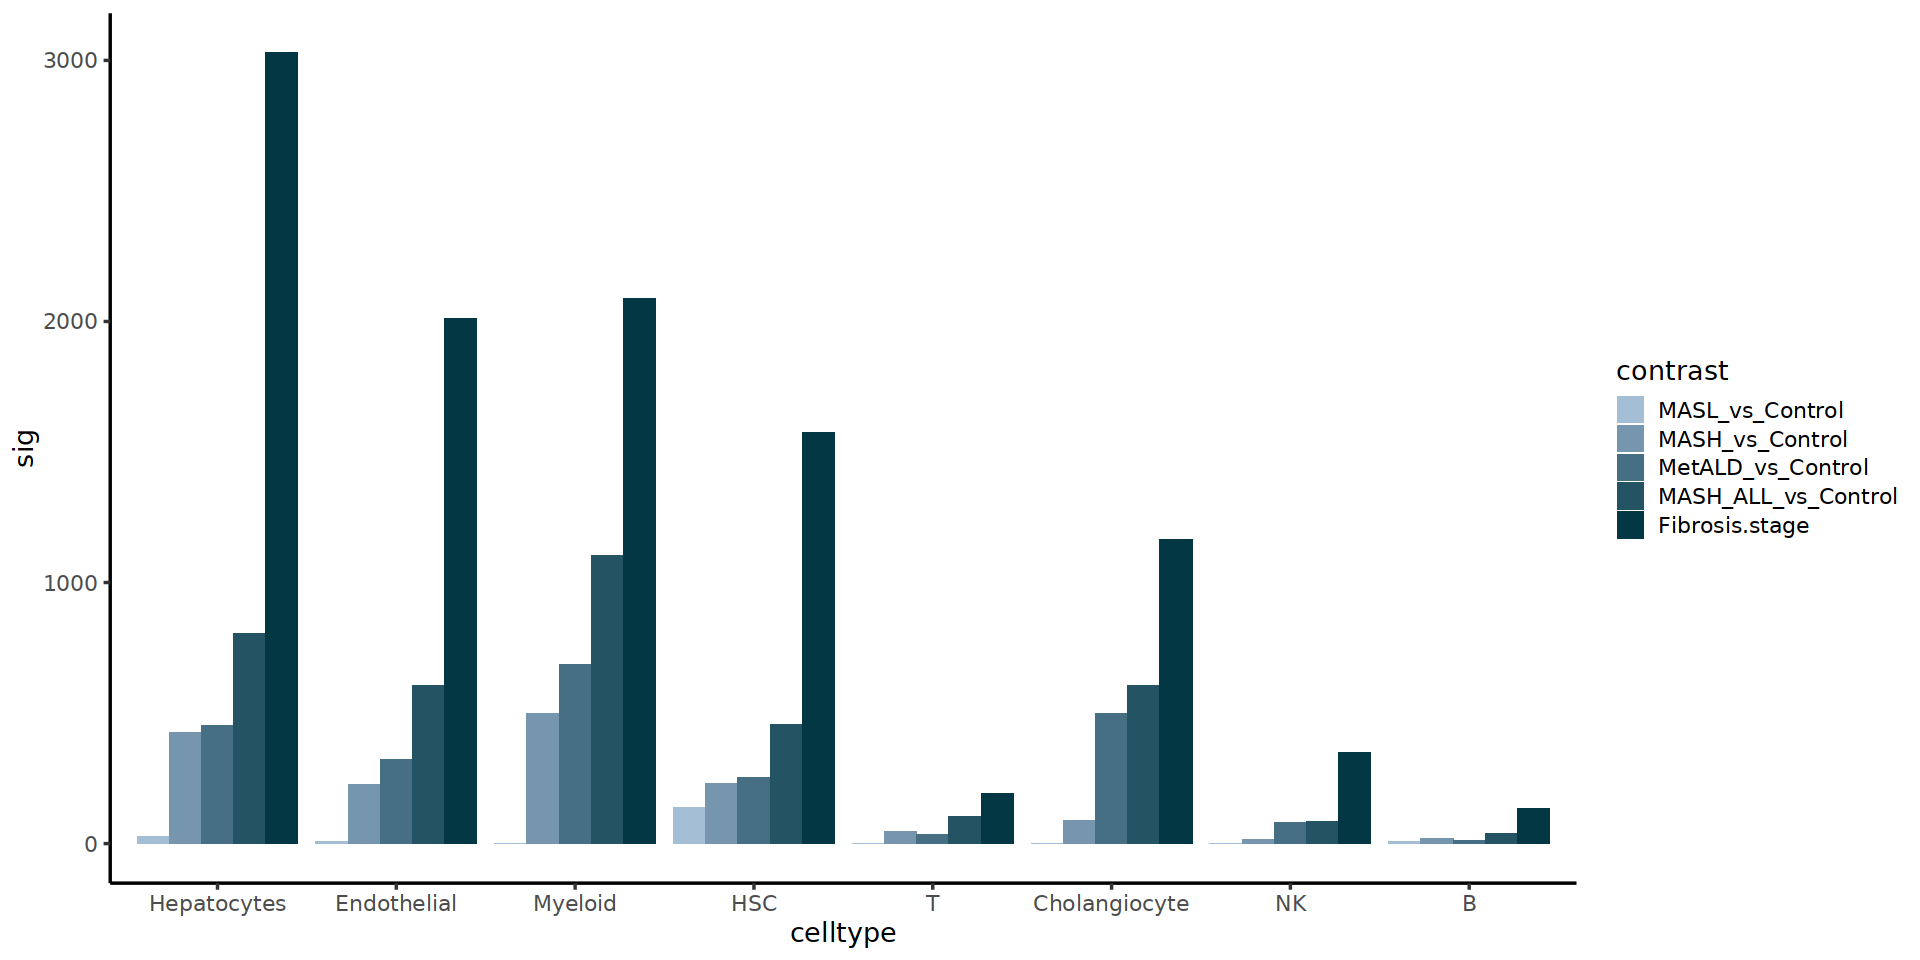

In [30]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [31]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

### Other Meta

In [19]:
contrasts  <- c('Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + BMI.scaled + batch + Gender'

In [20]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                        file = paste0(outdir, 'na.keep/', cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                #write.table(dds.results, 
                #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                #            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            #ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                            #       height = 10, width = 10,
                            #       plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: B"
[1] 36601    77


Donors detectected with celltype: 77

Subsetting metadata accordingly - Check that value is equal to above: 77

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

1 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

Joining with `by = join_by(SYMBOL)`
  - Lobular.inflammation

converting counts to integer mode

Warning message in DESeqDataSet(se, design = de

[1] "Analyzing: Cholangiocyte"
[1] 36601    81


Donors detectected with celltype: 81

Subsetting metadata accordingly - Check that value is equal to above: 81

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - Lobular.inflammation

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula con

[1] "Analyzing: Endothelial"
[1] 36601    86


...

Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

Joining with `by = j

[1] "Analyzing: Schwann"
[1] 36601     8


Donors detectected with celltype: 8

Subsetting metadata accordingly - Check that value is equal to above: 8

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

Skipping contrast Steatosis.grade: the model matrix is not full rank, so the model cannot be fit as specified.
  One or more variables or interaction terms in the design formula are linear
  combinations of the others and must be removed.

  Please read the vignette section 'Model matrix not full rank':

  vignette('DESeq2')

  - Lobular.inflammation

converting counts to integer mode

Warning message in DESeqDataSet(se, des

[1] "Analyzing: T"
[1] 36601    86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Joining with `by = join_by(SYMBOL)`
  - Lobular.inflammation

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula con

In [34]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,302,235,9,2
B,MASH_vs_Control,272,226,19,10
B,MetALD_vs_Control,404,235,5,12
Cholangiocyte,MASL_vs_Control,391,443,1,0
Cholangiocyte,MASH_vs_Control,855,534,87,53
Cholangiocyte,MetALD_vs_Control,1109,934,498,353
Endothelial,MASL_vs_Control,954,1046,6,7
Endothelial,MASH_vs_Control,1223,660,228,52
Endothelial,MetALD_vs_Control,1203,661,323,101


In [35]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

Warning message:
“Values from `sig` are not uniquely identified; output will contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} %>%
  dplyr::group_by(celltype, contrast) %>%
  dplyr::summarise(n = dplyr::n(), .groups = "drop") %>%
  dplyr::filter(n > 1L)”


celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8
<chr>,<list>,<list>,<list>,<list>,<list>,<list>,<list>,<list>
B,11,29,17,"53, 53",258,5,4,5
Cholangiocyte,1,140,851,"1019, 1019",2137,48,0,37
Endothelial,13,280,424,"811, 811",3141,2,0,59
Hepatocytes,30,537,584,"1088, 1088",5338,44,8,147
HSC,146,433,456,"892, 892",3134,103,1,159
Myeloid,1,649,1001,"1597, 1597",3101,123,2,102
NK,1,21,87,"103, 103",378,19,0,26
T,1,81,55,182,335,10,0,23


In [36]:
deseq.stats2 <- deseq.stats

In [37]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

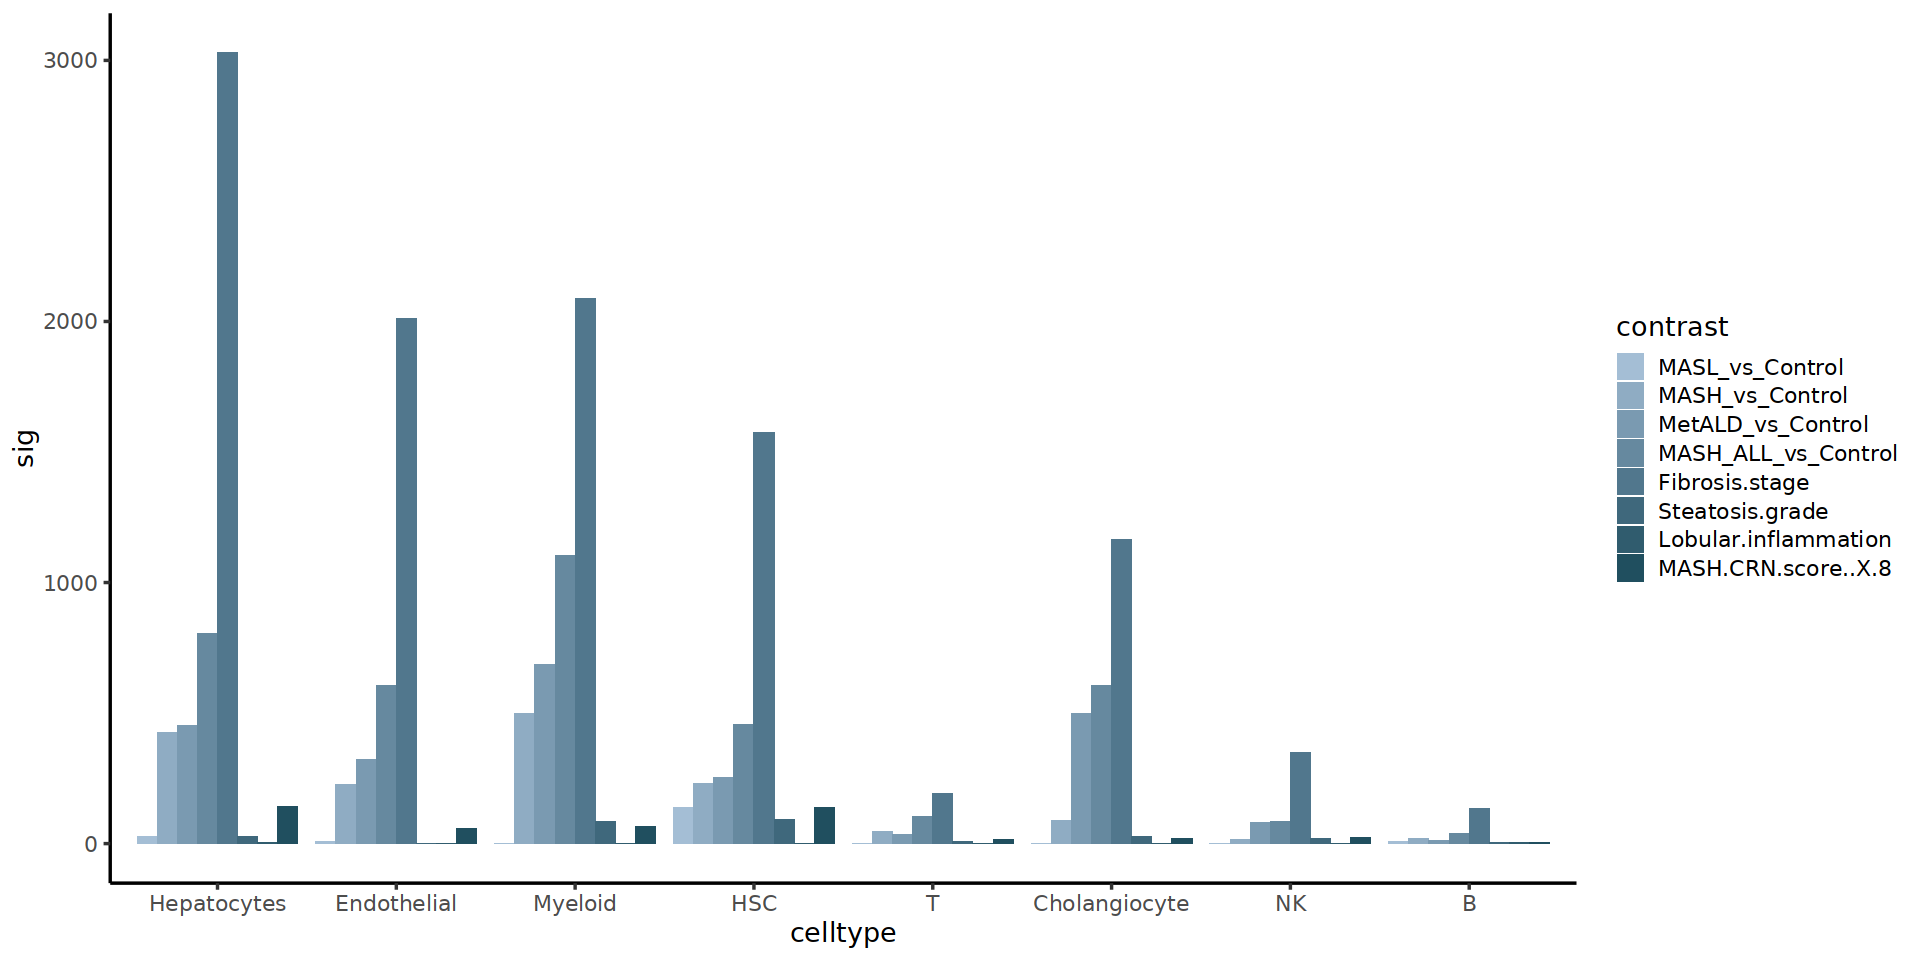

In [38]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [21]:
contrasts  <- c('Age','Age.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + BMI.scaled + batch + Gender'

In [22]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                        file = paste0(outdir, 'na.keep/', cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                #write.table(dds.results, 
                #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                #            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            #ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                            #       height = 10, width = 10,
                            #       plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: B"
[1] 36601    77


Donors detectected with celltype: 77

Subsetting metadata accordingly - Check that value is equal to above: 77

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Cholangiocyte"
[1] 36601    81


Donors detectected with celltype: 81

Subsetting metadata accordingly - Check that value is equal to above: 81

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Endothelial"
[1] 36601    86


...

Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Schwann"
[1] 36601     8


Donors detectected with celltype: 8

Subsetting metadata accordingly - Check that value is equal to above: 8

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

Skipping contrast Age: 

  The design matrix 

[1] "Analyzing: T"
[1] 36601    86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [41]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,302,235,9,2
B,MASH_vs_Control,272,226,19,10
B,MetALD_vs_Control,404,235,5,12
Cholangiocyte,MASL_vs_Control,391,443,1,0
Cholangiocyte,MASH_vs_Control,855,534,87,53
Cholangiocyte,MetALD_vs_Control,1109,934,498,353
Endothelial,MASL_vs_Control,954,1046,6,7
Endothelial,MASH_vs_Control,1223,660,228,52
Endothelial,MetALD_vs_Control,1203,661,323,101


In [42]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

Warning message:
“Values from `sig` are not uniquely identified; output will contain list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} %>%
  dplyr::group_by(celltype, contrast) %>%
  dplyr::summarise(n = dplyr::n(), .groups = "drop") %>%
  dplyr::filter(n > 1L)”


celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Age,Age.scaled
<chr>,<list>,<list>,<list>,<list>,<list>,<list>,<list>,<list>,<list>,<list>
B,11,29,17,"53, 53",258,5,4,5,1,4
Cholangiocyte,1,140,851,"1019, 1019",2137,48,0,37,0,2
Endothelial,13,280,424,"811, 811",3141,2,0,59,4,4
Hepatocytes,30,537,584,"1088, 1088",5338,44,8,147,169,178
HSC,146,433,456,"892, 892",3134,103,1,159,1,1
Myeloid,1,649,1001,"1597, 1597",3101,123,2,102,112,112
NK,1,21,87,"103, 103",378,19,0,26,0,0
T,1,81,55,182,335,10,0,23,2,2


In [43]:
deseq.stats2 <- deseq.stats

In [44]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

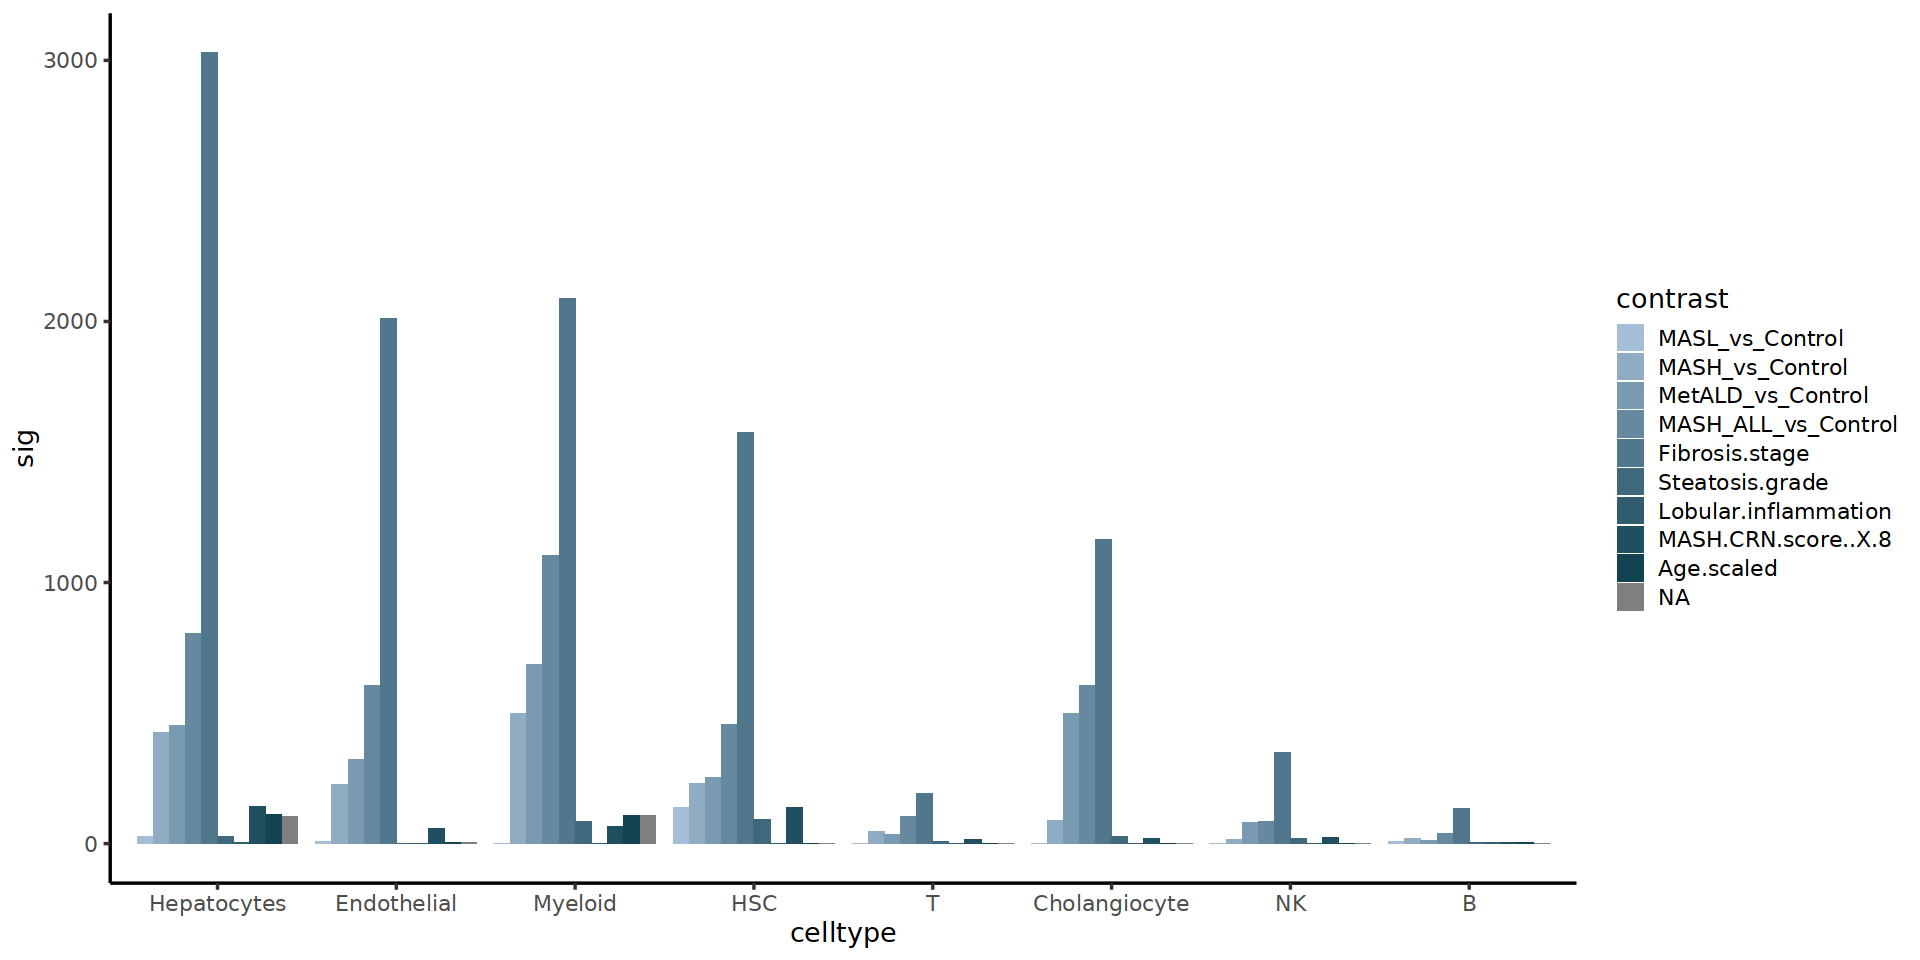

In [45]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [23]:
contrasts  <- c('BMI','BMI.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + batch + Gender'

In [24]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                        file = paste0(outdir, 'na.keep/', cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                #write.table(dds.results, 
                #            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                #            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                           #ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                           #       height = 10, width = 10,
                           #       plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: B"
[1] 36601    77


Donors detectected with celltype: 77

Subsetting metadata accordingly - Check that value is equal to above: 77

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Cholangiocyte"
[1] 36601    81


Donors detectected with celltype: 81

Subsetting metadata accordingly - Check that value is equal to above: 81

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Endothelial"
[1] 36601    86


...

Donors detectected with celltype: 85

Subsetting metadata accordingly - Check that value is equal to above: 85

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Schwann"
[1] 36601     8


Donors detectected with celltype: 8

Subsetting metadata accordingly - Check that value is equal to above: 8

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

Skipping contrast BMI: 

  The design matrix 

[1] "Analyzing: T"
[1] 36601    86


Donors detectected with celltype: 86

Subsetting metadata accordingly - Check that value is equal to above: 86

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [56]:
deseq.stats <- distinct(deseq.stats)

In [57]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
B,MASL_vs_Control,302,235,9,2
B,MASH_vs_Control,272,226,19,10
B,MetALD_vs_Control,404,235,5,12
Cholangiocyte,MASL_vs_Control,391,443,1,0
Cholangiocyte,MASH_vs_Control,855,534,87,53
Cholangiocyte,MetALD_vs_Control,1109,934,498,353
Endothelial,MASL_vs_Control,954,1046,6,7
Endothelial,MASH_vs_Control,1223,660,228,52
Endothelial,MetALD_vs_Control,1203,661,323,101


In [58]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
B,11,29,17,53,258,5,4,5,1,4,16,16
Cholangiocyte,1,140,851,1019,2137,48,0,37,0,2,0,0
Endothelial,13,280,424,811,3141,2,0,59,4,4,0,0
Hepatocytes,30,537,584,1088,5338,44,8,147,169,178,141,148
HSC,146,433,456,892,3134,103,1,159,1,1,0,0
Myeloid,1,649,1001,1597,3101,123,2,102,112,112,0,0
NK,1,21,87,103,378,19,0,26,0,0,0,0
T,1,81,55,182,335,10,0,23,2,2,0,0


In [59]:
deseq.stats2 <- deseq.stats

In [60]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

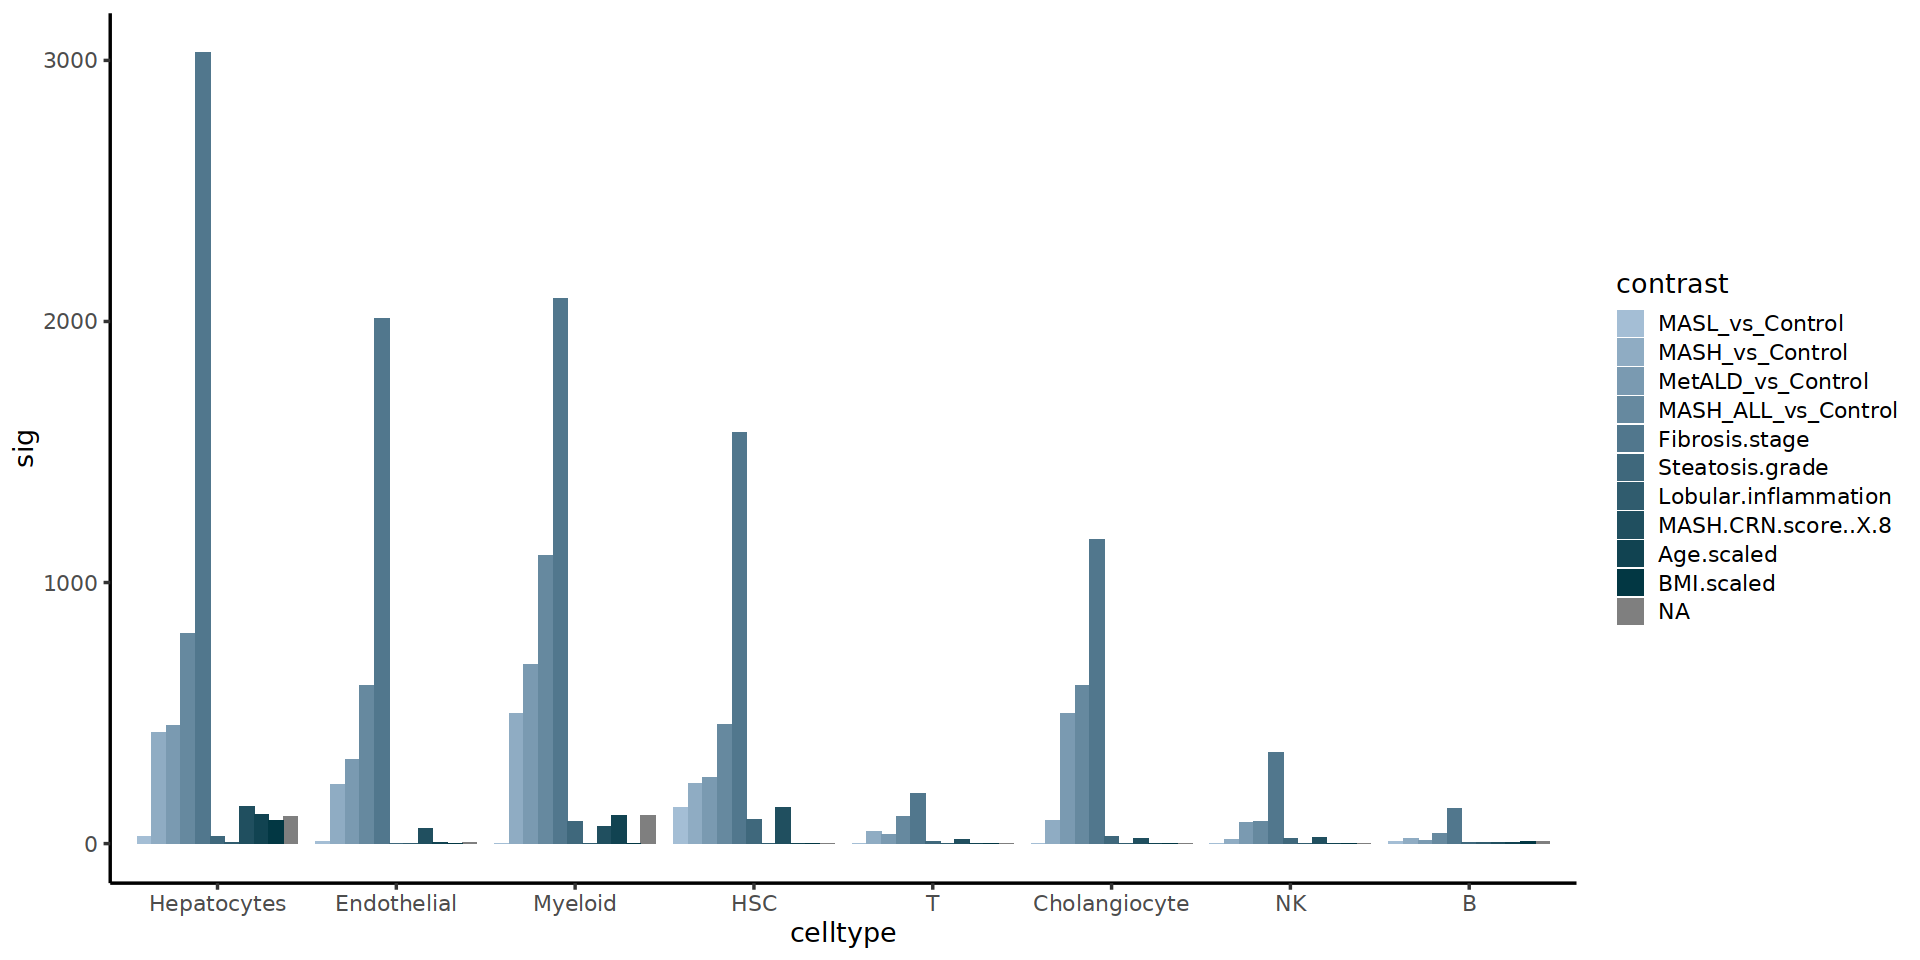

In [61]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

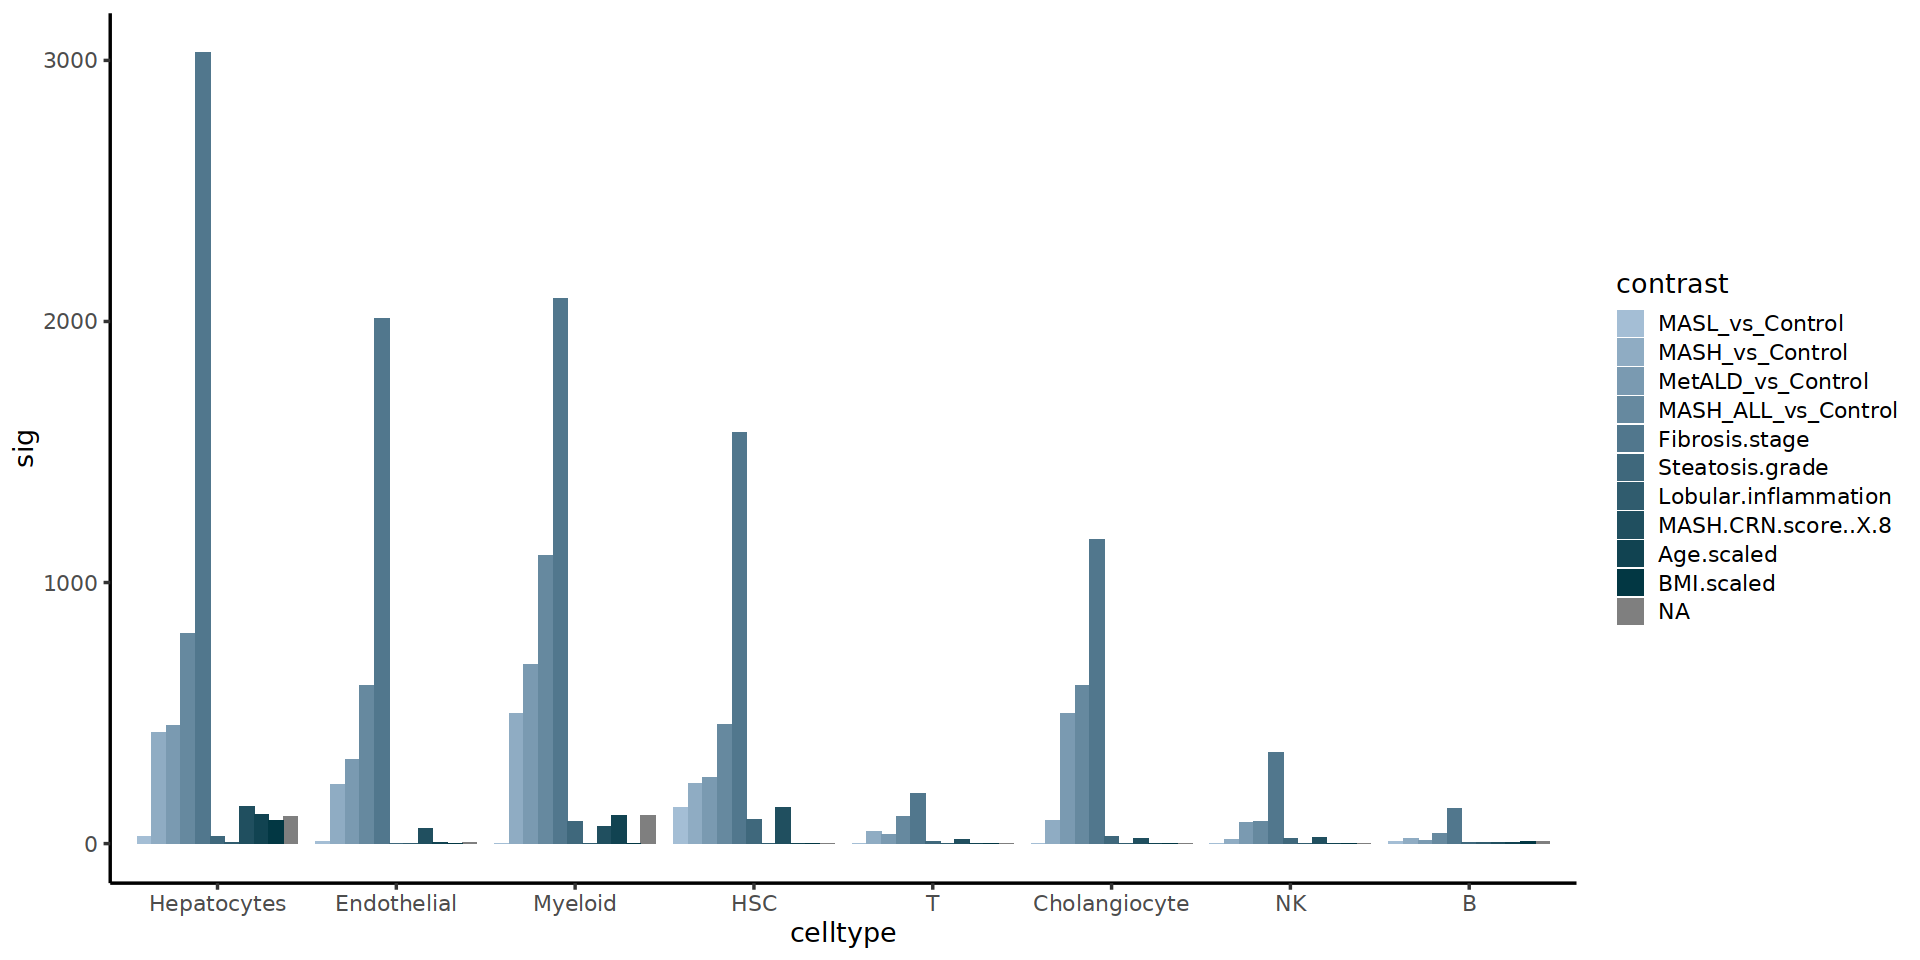

In [64]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [65]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary_add_contrasts.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

In [2]:
meta = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/RNA.meta.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,HL150001,85,47,746,8760,308,4,726,167,8,⋯,0,0,0,0,1,M,47,27.1,-0.6385847,-0.01553551
2,HL150009,19,34,459,2317,329,0,227,23,6,⋯,0,0,0,0,1,M,37,29.4,-0.3346869,-0.75778750


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "BMI.scaled"           "Age.scaled"

In [5]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/'
#Create outdir for results
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/'
# dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_perdonor.RNA.counts.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_perdonor.RNA.counts.tsv','', files) 

In [6]:
deseq.stats2 <- read.table(paste0(outdir, '240920_WE_deseq_summary_add_contrasts.tsv'),
           header=T, sep='\t')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = paste0(names(sort(colSums(meta[,2:11]), decreasing = T))))                           

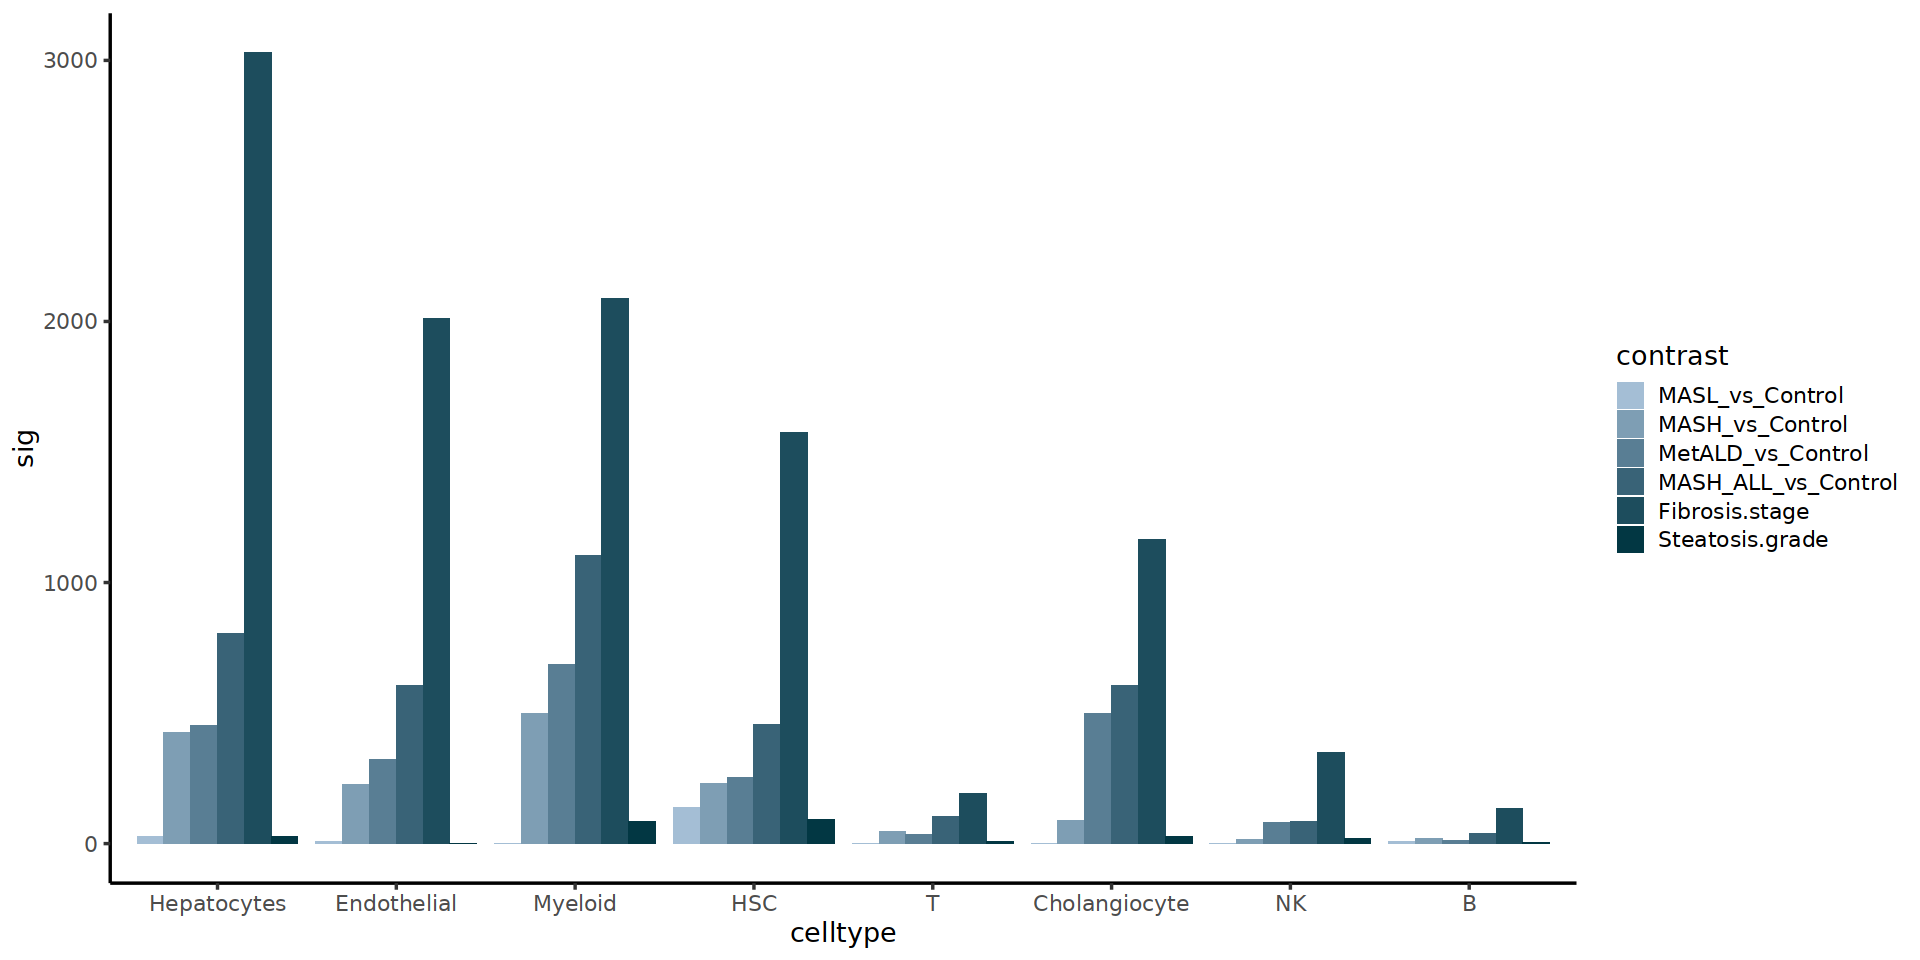

In [9]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
       filter(contrast %in% c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',
                             'Fibrosis.stage','Steatosis.grade','MASH_ALL_vs_Control')) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(6))

# FGSEA

In [2]:
#read in Ruth's preferred pathways
go <- gmtPathways('/nfs/lab/relgamal/MAGMA/c5.go.v2023.1.Hs.symbols.gmt')
kegg <- gmtPathways('/nfs/lab/relgamal/MAGMA/c2.cp.kegg.v2023.1.Hs.symbols.gmt')
reactome <- gmtPathways('/nfs/lab/relgamal/MAGMA/c2.cp.reactome.v2023.1.Hs.symbols.gmt')
pathways <- c(go, kegg, reactome)

go_mf <- gmtPathways('/nfs/lab/relgamal/MAGMA/c5.go.mf.v2023.1.Hs.symbols.gmt.txt')
go_bp <- gmtPathways('/nfs/lab/relgamal/MAGMA/c5.go.bp.v2023.1.Hs.symbols.gmt.txt')
pathways2 <- c(kegg,reactome,go_mf,go_bp)

#read in Hallmarks pathways (Jackie's preferred pathways)
hallmarks <- gmtPathways('/nfs/lab/relgamal/MAGMA/h.all.v2023.1.Hs.symbols.gmt.txt')

#make combined pathways list so can run all at once
all_pathways <- c(pathways2, hallmarks)

In [3]:
rps <- fread('/nfs/lab/tscc/ref/HGNC.ribosomal.genes.list.tsv', fill=TRUE, header=TRUE)

In [4]:
rps

HGNC ID (gene),Approved symbol,Approved name,Previous symbols,Aliases,Chromosome,Group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HGNC:14275,MRPL1,mitochondrial ribosomal protein L1,,"BM022,uL1m",4q21.1,Large subunit mitochondrial ribosomal proteins
HGNC:14056,MRPL2,mitochondrial ribosomal protein L2,,"MRP-L14,RPML14,CGI-22,uL2m",6p21.1,Large subunit mitochondrial ribosomal proteins
HGNC:10379,MRPL3,mitochondrial ribosomal protein L3,RPML3,"MRL3,uL3m",3q22.1,Large subunit mitochondrial ribosomal proteins
HGNC:14276,MRPL4,mitochondrial ribosomal protein L4,,"CGI-28,uL4m",19p13.2,Large subunit mitochondrial ribosomal proteins
HGNC:14055,MRPL10,mitochondrial ribosomal protein L10,,"RPML8,MRP-L8,L10MT,MRP-L10,MRPL8,MGC17973,uL10m",17q21.32,Large subunit mitochondrial ribosomal proteins
HGNC:14042,MRPL11,mitochondrial ribosomal protein L11,,uL11m,11q13.2,Large subunit mitochondrial ribosomal proteins
HGNC:10378,MRPL12,mitochondrial ribosomal protein L12,RPML12,"MRPL7/L12,MRPL7,bL12m",17q25.3,Large subunit mitochondrial ribosomal proteins
HGNC:14278,MRPL13,mitochondrial ribosomal protein L13,,"L13,RPL13,L13mt,RPML13,L13A,uL13m",8q24.12,Large subunit mitochondrial ribosomal proteins
HGNC:14279,MRPL14,mitochondrial ribosomal protein L14,,"RPML32,MRP-L32,uL14m",6p21.1,Large subunit mitochondrial ribosomal proteins


In [5]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/'
#Create outdir for results
outdir.fgsea <- paste0(dir, 'fGSEA/')
 dir.create(outdir.fgsea)
#Get list of pseudobulk files
files <- list.files(dir, pattern='.dds.res')
files

Warning message in dir.create(outdir.fgsea):
“'/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/fGSEA' already exists”


[1] "B_Age.dds.res"                                    
  [2] "B_Age.scaled.dds.res"                             
  [3] "B_BMI.dds.res"                                    
  [4] "B_BMI.scaled.dds.res"                             
  [5] "B_Fibrosis.stage.dds.res"                         
  [6] "B_Lobular.inflammation.dds.res"                   
  [7] "B_MASH_ALL_vs_Control.dds.res"                    
  [8] "B_MASH_vs_Control.dds.res"                        
  [9] "B_MASH.CRN.score..X.8.dds.res"                    
 [10] "B_MASL_vs_Control.dds.res"                        
 [11] "B_MetALD_vs_Control.dds.res"                      
 [12] "B_Steatosis.grade.dds.res"                        
 [13] "B_Steatosis.grade.no.fibrosis.dds.res"            
 [14] "Cholangiocyte_Age.dds.res"                        
 [15] "Cholangiocyte_Age.scaled.dds.res"                 
 [16] "Cholangiocyte_BMI.dds.res"                        
 [17] "Cholangiocyte_BMI.scaled.dds.res"                 
 [18] "Cholangiocyte_Fibrosis.stage.dds.res"             
 [19] "Cholangiocyte_Lobular.inflammation.dds.res"       
 [20] "Cholangiocyte_MASH_ALL_vs_Control.dds.res"        
 [21] "Cholangiocyte_MASH_vs_Control.dds.res"            
 [22] "Cholangiocyte_MASH.CRN.score..X.8.dds.res"        
 [23] "Cholangiocyte_MASL_vs_Control.dds.res"            
 [24] "Cholangiocyte_MetALD_vs_Control.dds.res"          
 [25] "Cholangiocyte_Steatosis.grade.dds.res"            
 [26] "Cholangiocyte_Steatosis.grade.no.fibrosis.dds.res"
 [27] "Endothelial_Age.dds.res"                          
 [28] "Endothelial_Age.scaled.dds.res"                   
 [29] "Endothelial_BMI.dds.res"                          
 [30] "Endothelial_BMI.scaled.dds.res"                   
 [31] "Endothelial_Fibrosis.stage.dds.res"               
 [32] "Endothelial_Lobular.inflammation.dds.res"         
 [33] "Endothelial_MASH_ALL_vs_Control.dds.res"          
 [34] "Endothelial_MASH_vs_Control.dds.res"              
 [35] "Endothelial_MASH.CRN.score..X.8.dds.res"          
 [36] "Endothelial_MASL_vs_Control.dds.res"              
 [37] "Endothelial_MetALD_vs_Control.dds.res"            
 [38] "Endothelial_Steatosis.grade.dds.res"              
 [39] "Endothelial_Steatosis.grade.no.fibrosis.dds.res"  
 [40] "Hepatocytes_Age.dds.res"                          
 [41] "Hepatocytes_Age.scaled.dds.res"                   
 [42] "Hepatocytes_BMI.dds.res"                          
 [43] "Hepatocytes_BMI.scaled.dds.res"                   
 [44] "Hepatocytes_Fibrosis.stage.dds.res"               
 [45] "Hepatocytes_Lobular.inflammation.dds.res"         
 [46] "Hepatocytes_MASH_ALL_vs_Control.dds.res"          
 [47] "Hepatocytes_MASH_vs_Control.dds.res"              
 [48] "Hepatocytes_MASH.CRN.score..X.8.dds.res"          
 [49] "Hepatocytes_MASL_vs_Control.dds.res"              
 [50] "Hepatocytes_MetALD_vs_Control.dds.res"            
 [51] "Hepatocytes_Steatosis.grade.dds.res"              
 [52] "Hepatocytes_Steatosis.grade.no.fibrosis.dds.res"  
 [53] "HSC_Age.dds.res"                                  
 [54] "HSC_Age.scaled.dds.res"                           
 [55] "HSC_BMI.dds.res"                                  
 [56] "HSC_BMI.scaled.dds.res"                           
 [57] "HSC_Fibrosis.stage.dds.res"                       
 [58] "HSC_Lobular.inflammation.dds.res"                 
 [59] "HSC_MASH_ALL_vs_Control.dds.res"                  
 [60] "HSC_MASH_vs_Control.dds.res"                      
 [61] "HSC_MASH.CRN.score..X.8.dds.res"                  
 [62] "HSC_MASL_vs_Control.dds.res"                      
 [63] "HSC_MetALD_vs_Control.dds.res"                    
 [64] "HSC_Steatosis.grade.dds.res"                      
 [65] "HSC_Steatosis.grade.no.fibrosis.dds.res"          
 [66] "Mast_Age.dds.res"                                 
 [67] "Mast_Age.scaled.dds.res"                          
 [68] "Mast_Ballooning.dds.res"                          
 [69] "Mast_BMI.dds.res"                                 


In [7]:
files
str_remove(files, "\\w*\\_")
str_remove(str_remove(files, "\\w*\\_"), '\\.dds\\.res')

[1] "B_Age.dds.res"                                    
  [2] "B_Age.scaled.dds.res"                             
  [3] "B_BMI.dds.res"                                    
  [4] "B_BMI.scaled.dds.res"                             
  [5] "B_Fibrosis.stage.dds.res"                         
  [6] "B_Lobular.inflammation.dds.res"                   
  [7] "B_MASH_ALL_vs_Control.dds.res"                    
  [8] "B_MASH_vs_Control.dds.res"                        
  [9] "B_MASH.CRN.score..X.8.dds.res"                    
 [10] "B_MASL_vs_Control.dds.res"                        
 [11] "B_MetALD_vs_Control.dds.res"                      
 [12] "B_Steatosis.grade.dds.res"                        
 [13] "B_Steatosis.grade.no.fibrosis.dds.res"            
 [14] "Cholangiocyte_Age.dds.res"                        
 [15] "Cholangiocyte_Age.scaled.dds.res"                 
 [16] "Cholangiocyte_BMI.dds.res"                        
 [17] "Cholangiocyte_BMI.scaled.dds.res"                 
 [18] "Cholangiocyte_Fibrosis.stage.dds.res"             
 [19] "Cholangiocyte_Lobular.inflammation.dds.res"       
 [20] "Cholangiocyte_MASH_ALL_vs_Control.dds.res"        
 [21] "Cholangiocyte_MASH_vs_Control.dds.res"            
 [22] "Cholangiocyte_MASH.CRN.score..X.8.dds.res"        
 [23] "Cholangiocyte_MASL_vs_Control.dds.res"            
 [24] "Cholangiocyte_MetALD_vs_Control.dds.res"          
 [25] "Cholangiocyte_Steatosis.grade.dds.res"            
 [26] "Cholangiocyte_Steatosis.grade.no.fibrosis.dds.res"
 [27] "Endothelial_Age.dds.res"                          
 [28] "Endothelial_Age.scaled.dds.res"                   
 [29] "Endothelial_BMI.dds.res"                          
 [30] "Endothelial_BMI.scaled.dds.res"                   
 [31] "Endothelial_Fibrosis.stage.dds.res"               
 [32] "Endothelial_Lobular.inflammation.dds.res"         
 [33] "Endothelial_MASH_ALL_vs_Control.dds.res"          
 [34] "Endothelial_MASH_vs_Control.dds.res"              
 [35] "Endothelial_MASH.CRN.score..X.8.dds.res"          
 [36] "Endothelial_MASL_vs_Control.dds.res"              
 [37] "Endothelial_MetALD_vs_Control.dds.res"            
 [38] "Endothelial_Steatosis.grade.dds.res"              
 [39] "Endothelial_Steatosis.grade.no.fibrosis.dds.res"  
 [40] "Hepatocytes_Age.dds.res"                          
 [41] "Hepatocytes_Age.scaled.dds.res"                   
 [42] "Hepatocytes_BMI.dds.res"                          
 [43] "Hepatocytes_BMI.scaled.dds.res"                   
 [44] "Hepatocytes_Fibrosis.stage.dds.res"               
 [45] "Hepatocytes_Lobular.inflammation.dds.res"         
 [46] "Hepatocytes_MASH_ALL_vs_Control.dds.res"          
 [47] "Hepatocytes_MASH_vs_Control.dds.res"              
 [48] "Hepatocytes_MASH.CRN.score..X.8.dds.res"          
 [49] "Hepatocytes_MASL_vs_Control.dds.res"              
 [50] "Hepatocytes_MetALD_vs_Control.dds.res"            
 [51] "Hepatocytes_Steatosis.grade.dds.res"              
 [52] "Hepatocytes_Steatosis.grade.no.fibrosis.dds.res"  
 [53] "HSC_Age.dds.res"                                  
 [54] "HSC_Age.scaled.dds.res"                           
 [55] "HSC_BMI.dds.res"                                  
 [56] "HSC_BMI.scaled.dds.res"                           
 [57] "HSC_Fibrosis.stage.dds.res"                       
 [58] "HSC_Lobular.inflammation.dds.res"                 
 [59] "HSC_MASH_ALL_vs_Control.dds.res"                  
 [60] "HSC_MASH_vs_Control.dds.res"                      
 [61] "HSC_MASH.CRN.score..X.8.dds.res"                  
 [62] "HSC_MASL_vs_Control.dds.res"                      
 [63] "HSC_MetALD_vs_Control.dds.res"                    
 [64] "HSC_Steatosis.grade.dds.res"                      
 [65] "HSC_Steatosis.grade.no.fibrosis.dds.res"          
 [66] "Mast_Age.dds.res"                                 
 [67] "Mast_Age.scaled.dds.res"                          
 [68] "Mast_Ballooning.dds.res"                          
 [69] "Mast_BMI.dds.res"                                 


[1] "Age.dds.res"                        
  [2] "Age.scaled.dds.res"                 
  [3] "BMI.dds.res"                        
  [4] "BMI.scaled.dds.res"                 
  [5] "Fibrosis.stage.dds.res"             
  [6] "Lobular.inflammation.dds.res"       
  [7] "Control.dds.res"                    
  [8] "Control.dds.res"                    
  [9] "MASH.CRN.score..X.8.dds.res"        
 [10] "Control.dds.res"                    
 [11] "Control.dds.res"                    
 [12] "Steatosis.grade.dds.res"            
 [13] "Steatosis.grade.no.fibrosis.dds.res"
 [14] "Age.dds.res"                        
 [15] "Age.scaled.dds.res"                 
 [16] "BMI.dds.res"                        
 [17] "BMI.scaled.dds.res"                 
 [18] "Fibrosis.stage.dds.res"             
 [19] "Lobular.inflammation.dds.res"       
 [20] "Control.dds.res"                    
 [21] "Control.dds.res"                    
 [22] "MASH.CRN.score..X.8.dds.res"        
 [23] "Control.dds.res"                    
 [24] "Control.dds.res"                    
 [25] "Steatosis.grade.dds.res"            
 [26] "Steatosis.grade.no.fibrosis.dds.res"
 [27] "Age.dds.res"                        
 [28] "Age.scaled.dds.res"                 
 [29] "BMI.dds.res"                        
 [30] "BMI.scaled.dds.res"                 
 [31] "Fibrosis.stage.dds.res"             
 [32] "Lobular.inflammation.dds.res"       
 [33] "Control.dds.res"                    
 [34] "Control.dds.res"                    
 [35] "MASH.CRN.score..X.8.dds.res"        
 [36] "Control.dds.res"                    
 [37] "Control.dds.res"                    
 [38] "Steatosis.grade.dds.res"            
 [39] "Steatosis.grade.no.fibrosis.dds.res"
 [40] "Age.dds.res"                        
 [41] "Age.scaled.dds.res"                 
 [42] "BMI.dds.res"                        
 [43] "BMI.scaled.dds.res"                 
 [44] "Fibrosis.stage.dds.res"             
 [45] "Lobular.inflammation.dds.res"       
 [46] "Control.dds.res"                    
 [47] "Control.dds.res"                    
 [48] "MASH.CRN.score..X.8.dds.res"        
 [49] "Control.dds.res"                    
 [50] "Control.dds.res"                    
 [51] "Steatosis.grade.dds.res"            
 [52] "Steatosis.grade.no.fibrosis.dds.res"
 [53] "Age.dds.res"                        
 [54] "Age.scaled.dds.res"                 
 [55] "BMI.dds.res"                        
 [56] "BMI.scaled.dds.res"                 
 [57] "Fibrosis.stage.dds.res"             
 [58] "Lobular.inflammation.dds.res"       
 [59] "Control.dds.res"                    
 [60] "Control.dds.res"                    
 [61] "MASH.CRN.score..X.8.dds.res"        
 [62] "Control.dds.res"                    
 [63] "Control.dds.res"                    
 [64] "Steatosis.grade.dds.res"            
 [65] "Steatosis.grade.no.fibrosis.dds.res"
 [66] "Age.dds.res"                        
 [67] "Age.scaled.dds.res"                 
 [68] "Ballooning.dds.res"                 
 [69] "BMI.dds.res"                        
 [70] "BMI.scaled.dds.res"                 
 [71] "Fibrosis.stage.dds.res"             
 [72] "Lobular.inflammation.dds.res"       
 [73] "Control.dds.res"                    
 [74] "MASH.CRN.score..X.8.dds.res"        
 [75] "Control.dds.res"                    
 [76] "Control.dds.res"                    
 [77] "Steatosis.grade.dds.res"            
 [78] "Age.dds.res"                        
 [79] "Age.scaled.dds.res"                 
 [80] "BMI.dds.res"                        
 [81] "BMI.scaled.dds.res"                 
 [82] "Fibrosis.stage.dds.res"             
 [83] "Lobular.inflammation.dds.res"       
 [84] "Control.dds.res"                    
 [85] "Control.dds.res"                    
 [86] "MASH.CRN.score..X.8.dds.res"        
 [87] "Control.dds.res"                    
 [88] "Control.dds.res"                    
 [89] "Steatosis.grade.dds.res"            
 [90] "Steatosis.grade.no.fibrosis.dds.res"
 [91] "Age.dds.res"                       

[1] "Age"                         "Age.scaled"                 
  [3] "BMI"                         "BMI.scaled"                 
  [5] "Fibrosis.stage"              "Lobular.inflammation"       
  [7] "Control"                     "Control"                    
  [9] "MASH.CRN.score..X.8"         "Control"                    
 [11] "Control"                     "Steatosis.grade"            
 [13] "Steatosis.grade.no.fibrosis" "Age"                        
 [15] "Age.scaled"                  "BMI"                        
 [17] "BMI.scaled"                  "Fibrosis.stage"             
 [19] "Lobular.inflammation"        "Control"                    
 [21] "Control"                     "MASH.CRN.score..X.8"        
 [23] "Control"                     "Control"                    
 [25] "Steatosis.grade"             "Steatosis.grade.no.fibrosis"
 [27] "Age"                         "Age.scaled"                 
 [29] "BMI"                         "BMI.scaled"                 
 [31] "Fibrosis.stage"              "Lobular.inflammation"       
 [33] "Control"                     "Control"                    
 [35] "MASH.CRN.score..X.8"         "Control"                    
 [37] "Control"                     "Steatosis.grade"            
 [39] "Steatosis.grade.no.fibrosis" "Age"                        
 [41] "Age.scaled"                  "BMI"                        
 [43] "BMI.scaled"                  "Fibrosis.stage"             
 [45] "Lobular.inflammation"        "Control"                    
 [47] "Control"                     "MASH.CRN.score..X.8"        
 [49] "Control"                     "Control"                    
 [51] "Steatosis.grade"             "Steatosis.grade.no.fibrosis"
 [53] "Age"                         "Age.scaled"                 
 [55] "BMI"                         "BMI.scaled"                 
 [57] "Fibrosis.stage"              "Lobular.inflammation"       
 [59] "Control"                     "Control"                    
 [61] "MASH.CRN.score..X.8"         "Control"                    
 [63] "Control"                     "Steatosis.grade"            
 [65] "Steatosis.grade.no.fibrosis" "Age"                        
 [67] "Age.scaled"                  "Ballooning"                 
 [69] "BMI"                         "BMI.scaled"                 
 [71] "Fibrosis.stage"              "Lobular.inflammation"       
 [73] "Control"                     "MASH.CRN.score..X.8"        
 [75] "Control"                     "Control"                    
 [77] "Steatosis.grade"             "Age"                        
 [79] "Age.scaled"                  "BMI"                        
 [81] "BMI.scaled"                  "Fibrosis.stage"             
 [83] "Lobular.inflammation"        "Control"                    
 [85] "Control"                     "MASH.CRN.score..X.8"        
 [87] "Control"                     "Control"                    
 [89] "Steatosis.grade"             "Steatosis.grade.no.fibrosis"
 [91] "Age"                         "Age.scaled"                 
 [93] "BMI"                         "BMI.scaled"                 
 [95] "Fibrosis.stage"              "Lobular.inflammation"       
 [97] "Control"                     "Control"                    
 [99] "MASH.CRN.score..X.8"         "Control"                    
[101] "Control"                     "Steatosis.grade"            
[103] "Steatosis.grade.no.fibrosis" "Age"                        
[105] "Age.scaled"                  "BMI"                        
[107] "BMI.scaled"                  "Fibrosis.stage"             
[109] "Lobular.inflammation"        "Control"                    
[111] "MASH.CRN.score..X.8"         "Control"                    
[113] "Control"                     "Steatosis.grade"            
[115] "Age"                         "Age.scaled"                 
[117] "BMI"                         "BMI.scaled"                 
[119] "Fibrosis.stage"              "Lobular.inflammation"       
[121] "Control"                     "Contr

In [23]:
set.seed(999)
contrast.use = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled')
# setup
tresh = 0.05

for (i in seq_along(files)){
    # load table
    file.use = files[i]
    contrast.use <- str_remove(str_remove(file.use, "\\w*\\_"), '\\.dds\\.res')
    cell.use = str_split_fixed(file.use, paste0("_", contrast.use), n = 2)[,1]
    De.analysis = paste0(cell.use, "_", contrast.use)
    print(paste0("Analyzing: ", De.analysis))
    res = read.table(paste0(dir,file.use), sep = '\t')
    res <- res[!rownames(res) %in% rps$`Approved symbol`,]
    res <- res[!str_detect(rownames(res), '^MT-'),]

    # Formatting for FGSEA
    res$rank = res$stat
    res = data.frame("SYMBOL" = rownames(res),
                     "stat" = res$rank)
    res = res[!grepl(pattern = "NA", x = res$SYMBOL),]
    ranks <- deframe(res)
    ranks = sort(ranks, decreasing=TRUE)
    
    tryCatch({
    message("Running FGSEA")
    fgseaRes <- fgseaMultilevel(pathways=all_pathways, 
                                stats=ranks,
                                minSize  = 10, 
                                maxSize  = 500)
    message("Number of total enriched terms: ", nrow(fgseaRes))
    #fgseaRes.tresh = fgseaRes[fgseaRes$padj < tresh,]
    fgseaRes.tresh = fgseaRes
    message("Number of significant terms: ", sum(fgseaRes$padj < tresh))
    # Add categories
    #fgseaRes.tresh = merge(fgseaRes.tresh, gene.set.db, by = "pathway", ) 
    #fgseaRes.tresh = left_join(fgseaRes.tresh, gene.set.db, by = "pathway", multiple = 'first') ## THIS NEEDS TO BE FIXED, there are miultiple matches in gene.set.db
    message("Double check that it's the same number of terms: ", nrow(fgseaRes.tresh))
    # Subset for GO families of interest
    fgseaRes.tresh.use = fgseaRes.tresh
    message("Number of significant terms: ", nrow(fgseaRes.tresh.use))
    # Collapse terms 
    collapsedPathways <- collapsePathways(fgseaRes.tresh.use[order(pval)][padj < tresh], 
                                          all_pathways, ranks)
    mainPathways <- fgseaRes.tresh.use[pathway %in% collapsedPathways$mainPathways][
                             order(-NES), pathway]
    fgseaResMain <- fgseaRes.tresh.use[match(mainPathways, pathway)]
    # Save them
    file = paste(outdir.fgsea, "GSEA.CP_", De.analysis, ".go.kegg.reactome.hallmark.nothresh.res", sep = "")
    fwrite(fgseaRes.tresh.use, file = file, sep = "\t")
    # print plot
    plot = ggplot(fgseaResMain, aes(x = reorder(pathway, NES), y = NES)) +
      geom_col(aes(fill= NES>0)) +
      theme_bw()+
      labs(x="", y="Normalized Enrichment Score",
           title= paste(De.analysis,
                        " \n Gene Ontologies")) + 
        theme(axis.text=element_text(size=10), axis.title=element_text(size=16, face="bold"),
        axis.text.x=element_text(), plot.title=element_text(size=16, face="bold", hjust=0.5)) +
      coord_flip()
    ggsave(filename = paste(outdir.fgsea, "GSEA.CP_", De.analysis, ".go.kegg.reactome.hallmark.pdf", sep = ""),
                            height = 16, width = 20,
                            plot = plot, device = "pdf")
        }, error = function(e) {
    message("Error or no results found for ", De.analysis, ": ", e$message)
})
}

[1] "Analyzing: B_Age"


Running FGSEA

Number of total enriched terms: 7084

Number of significant terms: 179

Double check that it's the same number of terms: 7084

Number of significant terms: 7084



[1] "Analyzing: B_Age.scaled"


Running FGSEA

Number of total enriched terms: 7084

Number of significant terms: 179

Double check that it's the same number of terms: 7084

Number of significant terms: 7084



[1] "Analyzing: B_BMI"


...

Running FGSEA

Number of total enriched terms: 5172

Number of significant terms: 145

Double check that it's the same number of terms: 5172

Number of significant terms: 5172



[1] "Analyzing: T_Steatosis.grade"


Running FGSEA

Number of total enriched terms: 3766

Number of significant terms: 110

Double check that it's the same number of terms: 3766

Number of significant terms: 3766



[1] "Analyzing: T_Steatosis.grade.no.fibrosis"


Running FGSEA

Number of total enriched terms: 6816

Number of significant terms: 414

Double check that it's the same number of terms: 6816

Number of significant terms: 6816



# Subset to GOBP

In [27]:
fGSEA.res.files <- list.files(outdir.fgsea, pattern='go.kegg.reactome.hallmark.nothresh.res')
head(fGSEA.res.files)

[1] "GSEA.CP_B_Age.go.kegg.reactome.hallmark.nothresh.res"                 
[2] "GSEA.CP_B_Age.scaled.go.kegg.reactome.hallmark.nothresh.res"          
[3] "GSEA.CP_B_BMI.go.kegg.reactome.hallmark.nothresh.res"                 
[4] "GSEA.CP_B_BMI.scaled.go.kegg.reactome.hallmark.nothresh.res"          
[5] "GSEA.CP_B_Fibrosis.stage.go.kegg.reactome.hallmark.nothresh.res"      
[6] "GSEA.CP_B_Lobular.inflammation.go.kegg.reactome.hallmark.nothresh.res"

In [64]:
outdir.fgsea

[1] "/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/fGSEA/"

In [70]:
paste0(outdir.fgsea, 'GOBP/')

[1] "/nfs/lab/projects/nash_nafld_liver/downstream_all/01_DESEQ_RNA/fGSEA/GOBP/"

In [72]:
file <- fGSEA.res.files[1]

for (file in fGSEA.res.files) {
    read.table(paste0(outdir.fgsea,file), header=T, sep='\t') %>%
        filter(str_detect(pathway, 'GOBP')) %>%
        write.table(paste0(outdir.fgsea, 'GOBP/', str_remove(str_replace(file, '.kegg.reactome.hallmark', 'bp'),'CP_')),
               sep='\t',col.names=T, row.names=F, quote=F)
}